# Spatial gradient genes across MSN types — BICAN (healthy) vs XDP

For each MSN subtype (Matrix, Patch, eMSN D1/D2), cells are ordered along a dorsal→ventral
spline axis (`r`, 0→1) fit per donor. This notebook finds genes whose expression tracks that
axis ("spatial gradient genes"), compares the gradient between healthy (BICAN) and diseased
(XDP) tissue, and prioritizes candidate risk / neuroprotective genes.

**Refactor note:** this is a reorganized version of `find_spatial_grad_gene_MSN_types.ipynb`.
No analysis was dropped. The gene-gradient "which compartment agrees/disagrees" classification
and plotting logic — previously copy-pasted three times (healthy compartments, health vs XDP,
XDP-only compartments) — is now one pair of functions (`classify_gradient_agreement` /
`plot_gradient_agreement`) called three times. A gene-expression-stats loop that was
accidentally duplicated verbatim was collapsed to one copy. Everything else (analyses,
thresholds, parameters, figures) is unchanged in substance, just given short markdown intros
and moved next to related code.

### Contents
1. Setup
2. Preprocess BICAN spatial data (per MSN subtype)
3. Load XDP spatial data, subset to diseased donors
4. Merge healthy donors into one combined object
5. Dorsal–ventral axis via splines (external R step)
6. Export merged AnnData for external sharing
7. Reusable analysis functions
8. Compute per-gene spatial-gradient correlations
9. Reload correlation tables (alternate entry point)
10. Healthy-tissue analysis: which genes gradient in which compartment
11. XDP vs healthy comparison
12. Single-gene spatial & gradient visualization
13. XDP-only compartment analysis
14. Prioritization scoring & pathway enrichment
15. Appendix: unrelated scratch query

## 1. Setup

In [10]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import rankdata, spearmanr, norm, t as t_dist
from statsmodels.stats.multitest import multipletests
from itertools import combinations

import grad_fun as gf

from utils import preprocessing

BICAN_DIR = "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated"
CORR_DIR  = f"{BICAN_DIR}/genes_correlation"

In [2]:
# ── Which compartment to focus on ─────────────────────────────────────
# Single-compartment analyses below (focus-selective risk scoring, gradient-shift sort
# order, DEG comparison, single-gene example, QC check, cAMP-pathway panel) report on
# this compartment. Matrix and Patch are both still computed everywhere upstream — this
# only picks which one gets the spotlight downstream.
FOCUS_CT = "Matrix"   # "Matrix" or "Patch" — was hardcoded to "Patch" throughout before this refactor
OTHER_CT = "Patch" if FOCUS_CT == "Matrix" else "Matrix"


## 2. Preprocess BICAN spatial data (per MSN subtype)

Convert each Zonal Object (`.qs`, exported from the Broad pipeline) into an `.h5ad`, standardize
`obs` columns (`donor_id`, `x`, `y`, `zone`), drop cells missing spatial/zone info, and save one
file per MSN subtype (Matrix D1/D2, Patch D1/D2, eMSN D1D2).

In [6]:
msn_type_path_dict = {
    "eMSN_D1D2": {"path": f"{BICAN_DIR}/STR_eMSN_D1D2_Matrix.qs", "zone_col": "Final_Zone_Assignments_No_Smooth", "donor_col": "donor", "x": "x_um2", "y": "y_um2"}, #gs://macosko_data/akraft/Zonal_Objects/
    "Patch_D1": {"path": f"{BICAN_DIR}/STR_D1_Patch_MSN.qs", "zone_col": "Final_Zone_Assignments_No_Smooth", "donor_col": "donor", "x": "x_um2", "y": "y_um2"}, # gs://macosko_data/akraft/Zonal_Objects/
    "Patch_D2": {"path": f"{BICAN_DIR}/STR_D2_Patch_MSN.qs", "zone_col": "Final_Zone_Assignments_No_Smooth", "donor_col": "donor", "x": "x_um2", "y": "y_um2"}, # gs://macosko_data/akraft/Zonal_Objects/
    "Matrix_D1": {"path": f"{BICAN_DIR}/STR_D1_Matrix_MSN.qs", "zone_col": "D1_Matrix_Zone", "donor_col": "donor", "x": "x_position", "y": "y_position"},# gs://macosko_data/akraft/Human_Striatum_Slide-tags/High_Quality_by_Celltype/
    "Matrix_D2": {"path": f"{BICAN_DIR}/STR_D2_Matrix_MSN.qs", "zone_col": "D2_Matrix_Zone", "donor_col": "donor", "x": "x_position", "y": "y_position"}, #gs://macosko_data/akraft/Human_Striatum_Slide-tags/High_Quality_by_Celltype/
}

In [ ]:
# NOTE: filtered to the FOCUS_CT subtype keys (Matrix_D1/Matrix_D2 or Patch_D1/Patch_D2)
# — kept as in the original notebook (used to selectively reprocess a subset of subtypes;
# drop the filter to redo all of them).
for cell_type, infos in [(k, v) for k, v in msn_type_path_dict.items() if k.startswith(FOCUS_CT)]:

    print(f"Processing {cell_type} ...")

    PATH_BASE   = "/home/gdallagl/myworkdir/XDP/data/_tmp"
    saving_path = f"{BICAN_DIR}/{cell_type}.h5ad"

    preprocessing.read_qs_save_files(infos["path"], PATH_BASE, assay="RNA")
    adata = preprocessing.build_h5ad_from_files(PATH_BASE, saving_path)

    # direct assignment avoids duplicate columns when "x"/"donor_id" already exist in metadata
    adata.obs["donor_id"] = adata.obs[infos["donor_col"]]
    adata.obs["x"]        = adata.obs[infos["x"]]
    adata.obs["y"]        = adata.obs[infos["y"]]
    adata.obs["zone"]     = adata.obs[infos["zone_col"]].astype("Int64").astype("category")

    adata = adata[
        adata.obs["x"].notna() &
        adata.obs["y"].notna() &
        adata.obs["zone"].notna() &
        adata.obs["donor_id"].notna()
        ].copy()

    adata.obsm["spatial"] = np.array([adata.obs["x"], adata.obs["y"]]).T
    adata.obs["ct_for_deg"] = cell_type

    print(adata)
    print(adata.obs["donor_id"].value_counts())

    adata.write_h5ad(saving_path)

## 3. Load XDP spatial data, subset to diseased donors

Keep only Matrix/Patch/eMSN cell types, 

only the 4 fully-mapped diseased donors, 

and only cells with valid spatial coordinates. 

D1/D2 are collapsed into the same 

cells on the "dead" (non-D1D2) region are dropped for Matrix/Patch NOT for D1D2

In [3]:
xdp_adata = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/_old/all_lib_adata_zoned_ct-cured_aligned_cloudcompare.h5ad", backed="r")

In [ ]:
# quick sanity check: donor <-> sample mapping
xdp_adata.obs[["donor_id", "sample"]].drop_duplicates()

,donor_id,sample
0,SCF-18-003,sample_01
95409,SCF-20-025,sample_02
137261,SCF-19-014,sample_03
176909,SCF-20-024,sample_04
212287,SCF-23-068,sample_05
246713,SCF-20-026,sample_06
283583,SCF-22-057,sample_07
310811,SCF-22-043,sample_08
405870,SCF-18-006,sample_09
422966,NaN,sample_09


In [4]:
xdp_adata_sub = xdp_adata[
    (xdp_adata.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2", "Patch_D1", "Patch_D2", "eMSN_D1D2"])) &
    #(xdp_adata.obs["sample"].isin(["sample_02"])) &
    #(xdp_adata.obs["puck"].isin(["puck1"])) & --> thes hsodul be alsinged
    (xdp_adata.obs["donor_id"].notna()) &
    (xdp_adata.obs["donor_id"].isin(["SCF-20-025", "SCF-19-014", "SCF-20-024", "SCF-20-026"])) & # only diseased
        # NOT COMLETE STR XDP SAMPLES: SCF-18-003, SCF-18-006
    (xdp_adata.obs["x"].notna() & xdp_adata.obs["y"].notna())
].to_memory().copy()

# collapse D1/D2 into the same 3 groups used for the healthy donors
xdp_adata_sub.obs["ct"] = xdp_adata_sub.obs["ct_for_deg"].map({
    "Matrix_D1": "Matrix", "Matrix_D2": "Matrix",
    "Patch_D1": "Patch",  "Patch_D2": "Patch",
    "eMSN_D1D2": "eMSN_D1D2",
})

# add zone
xdp_adata_sub.obs["zone"] = np.where(
    xdp_adata_sub.obs["ct"].isin(["Matrix"]), xdp_adata_sub.obs["zone"],  xdp_adata_sub.obs["zone_4"]
)

# change x,y to be rotated
xdp_adata_sub.obs[["x", "y"]] = xdp_adata_sub.obsm["spatial"].copy()

# drop cells without spatial coords
xdp_adata_sub = xdp_adata_sub[xdp_adata_sub.obs["x"].notna() & xdp_adata_sub.obs["y"].notna()].copy()

# use gene symbol as var_names
xdp_adata_sub.var_names = xdp_adata_sub.var["gene_symbol"].copy()
xdp_adata_sub.var_names = xdp_adata_sub.var_names.astype(str)
xdp_adata_sub.var_names_make_unique()

# remove cells on dead region (not D1D2) — transcriptome totally different there
xdp_adata_sub = xdp_adata_sub[
    (xdp_adata_sub.obs["ct"].isin(["Matrix", "Patch"]) & (xdp_adata_sub.obs["region"] == "healthy")) |
    (xdp_adata_sub.obs["ct"].isin(["eMSN_D1D2"]))
]

print(xdp_adata_sub)
print(xdp_adata_sub.obs["donor_id"].value_counts())
print(xdp_adata_sub.obs["puck"].value_counts())

View of AnnData object with n_obs × n_vars = 16672 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:865: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['DDX11L2', 'MIR1302-2HG', 'ENSG00000290826', 'OR4F5', 'ENSG00000238009']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


## 4. Merge healthy donors into one combined object

Build one AnnData spanning eMSN_D1D2 + Matrix + Patch, restricted to the donors that have
eMSN_D1D2 data (so every donor has all 3 compartments).

In [7]:
d1d2 = sc.read_h5ad(f'{BICAN_DIR}/eMSN_D1D2.h5ad')

d1d2_samples = d1d2.obs["donor_id"].unique().tolist()

processed = []
for cell_type, infos in list(msn_type_path_dict.items())[:]:

    print(cell_type)

    if cell_type == "eMSN_D1D2":
        processed.append(d1d2)
    else:
        adata = sc.read_h5ad(f'{BICAN_DIR}/{cell_type}.h5ad', backed='r')
        print(adata)
        #print(adata.obs["donor_id"].value_counts())
        adata = adata[adata.obs["donor_id"].isin(d1d2_samples), :].to_memory().copy()  # keep only donors that are in eMSN_D1D2
        processed.append(adata)

# concat
adata = sc.concat(processed)
adata.obs_names_make_unique()
adata.obs["ct"] = adata.obs["ct_for_deg"].map({
    "eMSN_D1D2": "eMSN_D1D2", "Matrix_D1": "Matrix", "Matrix_D2": "Matrix",
    "Patch_D1": "Patch", "Patch_D2": "Patch"
})

adata.layers["counts"] = adata.X.copy()  # store raw counts in a separate layer

eMSN_D1D2
Patch_D1
AnnData object with n_obs × n_vars = 9361 × 37905 backed at '/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/Patch_D1.h5ad'
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'donor_external_id', 'is_primary_data', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'donor_id', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'x', 'y', 'RNA_snn_res.0.8', 'seurat_clusters', 'library', 'donor',

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


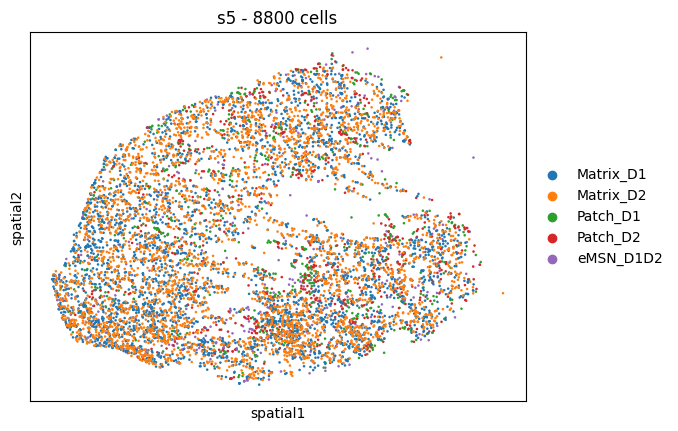

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


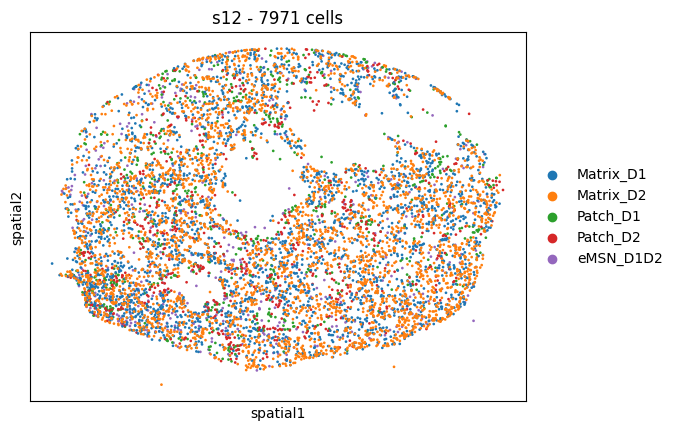

In [9]:
# QC: spatial embedding of cell types, first 2 healthy donors
for s in adata.obs["donor_id"].unique()[:2]:
    sc.pl.embedding(adata[adata.obs["donor_id"] == s], basis="spatial", color=["ct_for_deg"], title=f"{s} - {adata[adata.obs['donor_id'] == s].shape[0]} cells")

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


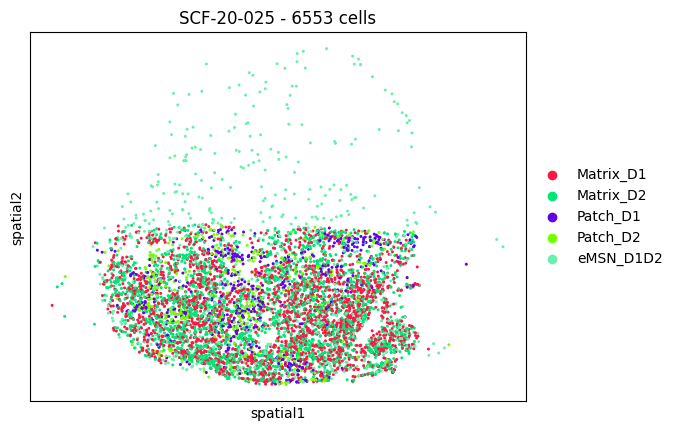

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


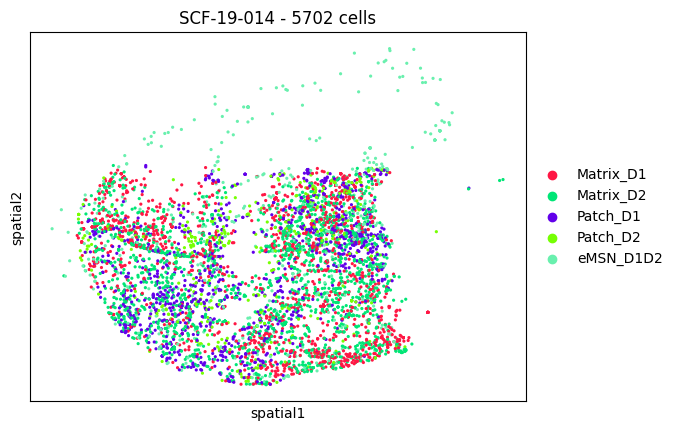

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


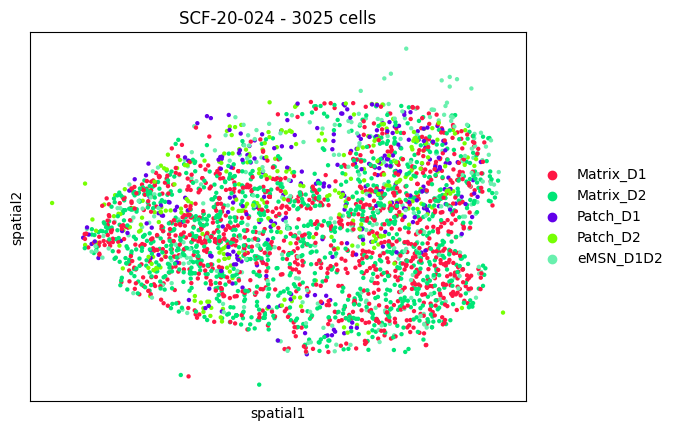

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


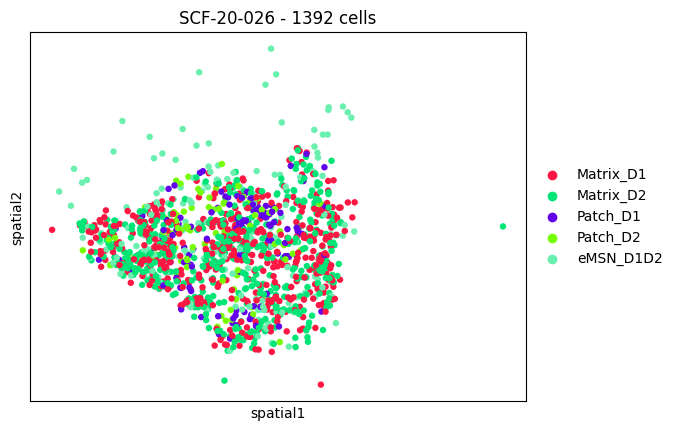

In [10]:
# QC: spatial embedding of cell types, all XDP donors
for s in xdp_adata_sub.obs["donor_id"].unique()[:]:
    sc.pl.embedding(xdp_adata_sub[xdp_adata_sub.obs["donor_id"] == s], basis="spatial", color=["ct_for_deg"], title=f"{s} - {xdp_adata_sub[xdp_adata_sub.obs['donor_id'] == s].shape[0]} cells")

## 5. Dorsal–ventral axis via splines (external R step)

1. Write one CSV per donor with cell barcodes as index and `x`, `y` columns.
2. In R, fit a spline through the tissue and project each cell onto it, giving:
   `r` (position along the spline, used as the dorsal→ventral axis) and `d` (perpendicular
   distance, used to split caudate vs. putamen). See the workflow doc:
   https://docs.google.com/document/d/181SnwQdWJkku2wrG-MGyENsZnDij3jbw9V1BOhs_IY4/edit?tab=t.0
3. Read the R output back in and attach `r`/`d`/`region` to each object.

In [ ]:
path = f'{BICAN_DIR}/for_splines'
os.makedirs(path, exist_ok=True)

for a in [adata, xdp_adata_sub]:
    print(a)
    for s in a.obs["donor_id"].unique():
        obs = a[a.obs["donor_id"] == s].obs[["x", "y"]].copy()
        obs.to_csv(os.path.join(path, f"{s}_x_y.csv"), index=True)

**Move to R, one sample at a time.** Matrix zones are reported below to sanity-check the spline
before running it.

```R
process_sample <- function(s) {
  base <- sprintf("~/Downloads/samples_xdp/s%s_x_y", s)
  df     <- read.csv(paste0(base, ".csv"), row.names = 1)  # must have x, y columns
  spl    <- anno_spline(df)
  result <- xy2dr(df, spl)
  write.csv(result, paste0(base, "_with_splines.csv"))
  invisible(result)
}
```

In [ ]:
# Plot zone matrix D1 to help frawing splines
for a in [xdp_adata_sub]:
    for s in a.obs["donor_id"].dropna().unique()[:]:
        print(s)
        axs = sc.pl.embedding(
            a[(a.obs["donor_id"] == s) & (a.obs["ct_for_deg"] == "Matrix_D1")],
            basis="spatial",
            color=["zone"],
            title=f"Donor {s}",
            show=False,
        )

        # color=[...] returns a list; a bare string returns a single Axes — handle both
        for ax in (axs if isinstance(axs, list) else [axs]):
            ax.set_aspect("equal")

    plt.show()

### Read splines back and attach `r` / `d` / `region`

In [8]:
# initialize once BEFORE the loop so the columns exist
path = f'{BICAN_DIR}/for_splines'

adata.obs["r"] = np.nan
adata.obs["d"] = np.nan
xdp_adata_sub.obs["r"] = np.nan
xdp_adata_sub.obs["d"] = np.nan

for a in [xdp_adata_sub, adata]:
    print(a)
    for s in a.obs["donor_id"].dropna().unique()[:]:
        csv_path = f"{path}/{s}_x_y_with_splines.csv"
        if not os.path.exists(csv_path):
            print(f"Donor {s} - spline file not found, skipping ...")
            continue

        df_spline = pd.read_csv(csv_path, index_col=0)
        df_spline.index = df_spline.index.astype(str)

        # Normalise
        df_spline["r_original"] = df_spline["r"].copy()  # keep original for reference
        df_spline["r"] = df_spline["r"] / df_spline["r"].max()

        display(df_spline.head())
        display(a.obs.head())

        # the spline CSV is produced by an external R step and can drift out of sync with
        # the current `adata` (e.g. upstream filtering changed since splines were computed) —
        # only assign cells still present, and report what got dropped
        common_idx = df_spline.index.intersection(a.obs_names)
        missing    = df_spline.index.difference(a.obs_names)
        if len(missing) > 0:
            print(f"Donor {s} - {len(missing)}/{len(df_spline)} spline barcodes not found in adata, skipping those")

        # assign by row (cell barcode), into named columns — pandas aligns on index
        a.obs.loc[common_idx, "r"] = df_spline.loc[common_idx, "r"]
        a.obs.loc[common_idx, "d"] = df_spline.loc[common_idx, "d"]
        a.obs.loc[common_idx, "r_original"] = df_spline.loc[common_idx, "r_original"]

adata.obs["region"] = np.where(adata.obs["d"] < 0, "caudate", "putamen")
xdp_adata_sub.obs["region"] = np.where(xdp_adata_sub.obs["d"] < 0, "caudate", "putamen")

/tmp/ipykernel_566576/1167038515.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  xdp_adata_sub.obs["r"] = np.nan


AnnData object with n_obs × n_vars = 16672 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_ce

,x,y,d,r,r_original
95421,10415.425106,2129.599270,2602.704530,0.088104,2596.637868
95437,8346.060562,5996.362047,4168.885232,0.206206,6077.423643
95455,9761.182678,7895.547945,2768.918616,0.261370,7703.246074
95506,18481.881807,6530.497358,-5976.523588,0.217281,6403.817376
95509,12935.036470,7752.475471,-408.176247,0.262004,7721.924875


,x,y,pct_intronic,dbscan_clusters,dbscan_score,has_spatial,sample,Neighborhood_name,Neighborhood_bootstrapping_probability,Neighborhood_aggregate_probability,...,puck,region,radial_high_mito_patch,radial_patch_in_death,radial_patch_in_healthy,mito_radial_neighborhood,image,ct,r,d
95421,10415.425106,2129.599270,0.618838,1.0,0.786908,True,sample_02,Subpallium GABA,1.0,1.0,...,puck1,healthy,NaN,NaN,radial_patch_in_healthy,radial_patch_in_healthy,sample_02_puck1,eMSN_D1D2,NaN,NaN
95437,6963.625381,6576.078966,0.569211,1.0,0.815845,True,sample_02,Subpallium GABA,1.0,1.0,...,puck2,healthy,NaN,NaN,radial_patch_in_healthy,radial_patch_in_healthy,sample_02_puck2,Patch,NaN,NaN
95455,8378.747497,8475.264864,0.626447,1.0,0.778672,True,sample_02,Subpallium GABA,1.0,1.0,...,puck2,healthy,NaN,NaN,radial_patch_in_healthy,radial_patch_in_healthy,sample_02_puck2,Matrix,NaN,NaN
95506,17099.446627,7110.214277,0.608801,1.0,0.773679,True,sample_02,Subpallium GABA,1.0,1.0,...,puck2,healthy,NaN,NaN,NaN,NaN,sample_02_puck2,Matrix,NaN,NaN
95509,11552.601290,8332.192390,0.607442,1.0,0.802518,True,sample_02,Subpallium GABA,1.0,1.0,...,puck2,healthy,NaN,NaN,radial_patch_in_healthy,radial_patch_in_healthy,sample_02_puck2,Patch,NaN,NaN


Donor SCF-20-025 - 38/6591 spline barcodes not found in adata, skipping those


...

,pct_coding,pct_utr,pct_intergenic,pct_genic,pct_intronic,pct_mt,pct_ribosomal,frac_contamination,experiment,Neighborhood_label,...,x,y,library,unique_cell_ID,zone,ct_for_deg,ct,r,d,r_original
s5_s5_CTATCAGAGCTTCGTT_1,0.1999,0.0710,0.0634,0.9342,0.6634,0.0023,0,0.011298,s5,CS20250428_NEIGH_0002,...,10374.583910,12016.090658,SI-TT-A11,s5_CTATCAGAGCTTCGTT_1,6,eMSN_D1D2,eMSN_D1D2,0.206828,-4096.517455,6175.330569
s5_s5_AGCTTCCGTCTGTGGA_1,0.1873,0.0764,0.0654,0.9308,0.6671,0.0038,0,0.001800,s5,CS20250428_NEIGH_0002,...,11183.131766,26674.195077,SI-TT-A11,s5_AGCTTCCGTCTGTGGA_1,1,eMSN_D1D2,eMSN_D1D2,0.729115,3498.427588,21769.457753
s5_s5_CCGATTAAGACAATTC_1,0.1654,0.0639,0.0677,0.9280,0.6986,0.0043,0,0.005945,s5,CS20250428_NEIGH_0002,...,10304.215893,6864.722650,SI-TT-A11,s5_CCGATTAAGACAATTC_1,5,eMSN_D1D2,eMSN_D1D2,0.076578,-5341.673244,2286.428126
s5_s5_CTTCGTTAGCGTTGTA_1,0.2120,0.0816,0.0633,0.9336,0.6400,0.0031,0,0.003180,s5,CS20250428_NEIGH_0002,...,1068.242984,11849.066571,SI-TT-A11,s5_CTTCGTTAGCGTTGTA_1,4,eMSN_D1D2,eMSN_D1D2,0.138426,4998.530615,4133.031660
s5_s5_CCTTGCCAGCGTGGTT_1,0.1394,0.0551,0.0771,0.9220,0.7274,0.0009,0,0.002287,s5,CS20250428_NEIGH_0002,...,6618.881840,8704.140173,SI-TT-A11,s5_CCTTGCCAGCGTGGTT_1,5,eMSN_D1D2,eMSN_D1D2,0.088778,-1244.782385,2650.678841


Donor s37 - 792/11942 spline barcodes not found in adata, skipping those


,x,y,d,r,r_original
s38_s38_2025-06-04_s38_GEX_CAP_rxn1_CAGCGCATCAGCATCA,-5173.863361,-7153.165242,3128.484525,0.179119,4932.976421
s38_s38_2025-06-04_s38_GEX_CAP_rxn1_ACAAGGAGTCACGTAG,-3221.908664,1433.783978,3665.630132,0.427870,11783.667535
s38_s38_2025-06-04_s38_GEX_CAP_rxn1_CGTATCGCAGCTAAAG,5636.115190,1730.704103,-3630.212181,0.630444,17362.599370
s38_s38_2025-06-04_s38_GEX_CAP_rxn1_ATGCGCAGTGTGGCGT,5233.595314,1566.931564,-3417.577852,0.609783,16793.603550
s38_s38_2025-06-04_s38_GEX_CAP_rxn1_GTTAGCCAGCCTTTAC,6956.433289,-2199.140678,-6911.370336,0.510940,14071.421827


,pct_coding,pct_utr,pct_intergenic,pct_genic,pct_intronic,pct_mt,pct_ribosomal,frac_contamination,experiment,Neighborhood_label,...,x,y,library,unique_cell_ID,zone,ct_for_deg,ct,r,d,r_original
s5_s5_CTATCAGAGCTTCGTT_1,0.1999,0.0710,0.0634,0.9342,0.6634,0.0023,0,0.011298,s5,CS20250428_NEIGH_0002,...,10374.583910,12016.090658,SI-TT-A11,s5_CTATCAGAGCTTCGTT_1,6,eMSN_D1D2,eMSN_D1D2,0.206828,-4096.517455,6175.330569
s5_s5_AGCTTCCGTCTGTGGA_1,0.1873,0.0764,0.0654,0.9308,0.6671,0.0038,0,0.001800,s5,CS20250428_NEIGH_0002,...,11183.131766,26674.195077,SI-TT-A11,s5_AGCTTCCGTCTGTGGA_1,1,eMSN_D1D2,eMSN_D1D2,0.729115,3498.427588,21769.457753
s5_s5_CCGATTAAGACAATTC_1,0.1654,0.0639,0.0677,0.9280,0.6986,0.0043,0,0.005945,s5,CS20250428_NEIGH_0002,...,10304.215893,6864.722650,SI-TT-A11,s5_CCGATTAAGACAATTC_1,5,eMSN_D1D2,eMSN_D1D2,0.076578,-5341.673244,2286.428126
s5_s5_CTTCGTTAGCGTTGTA_1,0.2120,0.0816,0.0633,0.9336,0.6400,0.0031,0,0.003180,s5,CS20250428_NEIGH_0002,...,1068.242984,11849.066571,SI-TT-A11,s5_CTTCGTTAGCGTTGTA_1,4,eMSN_D1D2,eMSN_D1D2,0.138426,4998.530615,4133.031660
s5_s5_CCTTGCCAGCGTGGTT_1,0.1394,0.0551,0.0771,0.9220,0.7274,0.0009,0,0.002287,s5,CS20250428_NEIGH_0002,...,6618.881840,8704.140173,SI-TT-A11,s5_CCTTGCCAGCGTGGTT_1,5,eMSN_D1D2,eMSN_D1D2,0.088778,-1244.782385,2650.678841


Donor s38 - 442/9009 spline barcodes not found in adata, skipping those


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of

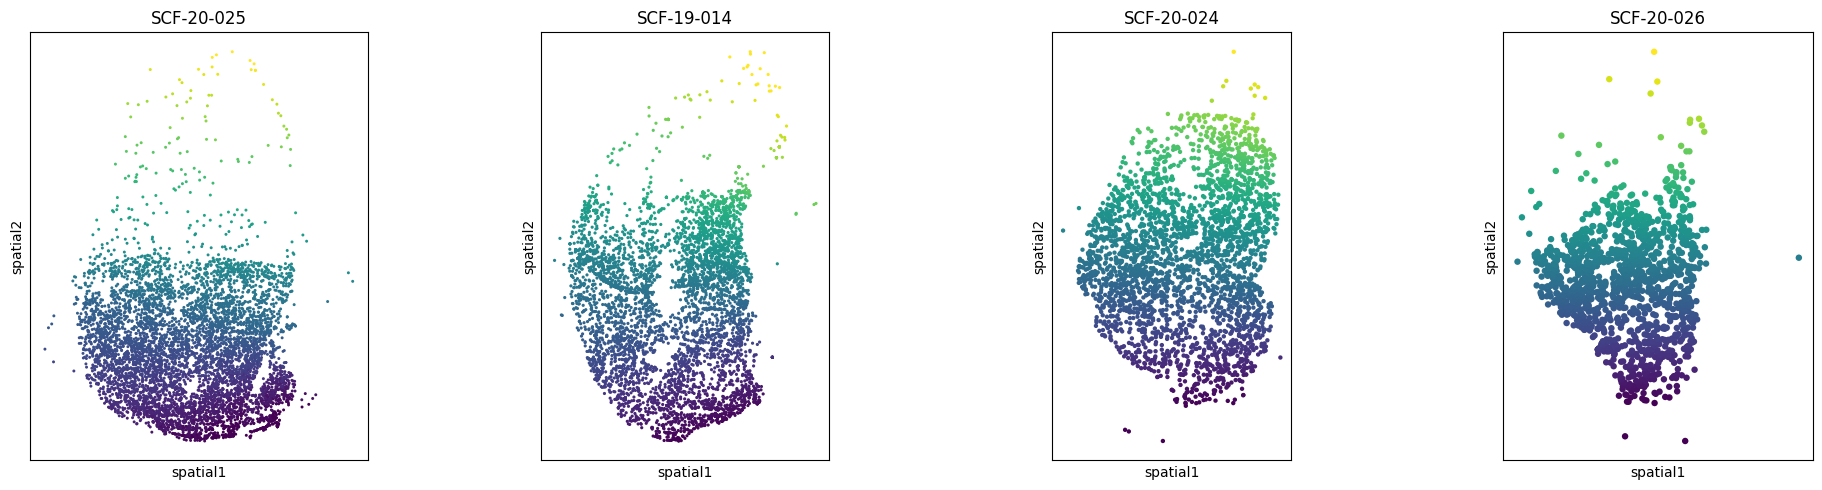

In [7]:
# QC: r (dorsal->ventral position) across XDP donors
for a in [xdp_adata_sub]:

    donors = a.obs["donor_id"].dropna().unique()
    ncols  = 4
    nrows  = int(np.ceil(len(donors) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = axes.flatten()

    for ax, s in zip(axes, donors):
        sc.pl.embedding(
            a[a.obs["donor_id"] == s],
            basis="spatial",
            color="r",
            title=f"{s}",
            ax=ax,
            show=False,
            colorbar_loc=None,
        )
        ax.set_aspect("equal")

    # hide unused axes
    for ax in axes[len(donors):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

## 6. Export merged AnnData for external sharing (Joshua Lab)

In [ ]:
ids_df = pd.read_csv(f"{BICAN_DIR}/spatial_bican_ids_conversion.csv")
ids_df.rename(columns={"donor_id": "donor_id_original", "donor": "donor_id"}, inplace=True)
ids_df

In [ ]:
adata_save = adata.copy()
adata_save.X = adata_save.layers["counts"].copy()  # restore raw counts before saving
del adata_save.layers["counts"]
adata_save.obs["original_cell_barcode"] = adata_save.obs_names.copy()
adata_save.obs = adata_save.obs[
    ["original_cell_barcode", "donor_id", "Group_name", "ct", "x", "y", "r_original", "r", "d"]].copy()
adata_save.obs = adata_save.obs.merge(ids_df, on="donor_id", how="left")
adata_save = adata_save[
    adata_save.obs.dropna(subset=["r", "d"]).index
]
adata_save.obs.index = adata_save.obs["original_cell_barcode"].copy()
print(sorted(adata_save.obs["donor_id"].unique()))
print(sorted(adata_save.obs["donor_id_original"].unique()))
display(adata_save.obs)

adata_save.write_h5ad('/home/gdallagl/myworkdir/XDP/data/_old/adata_m1_m2_d1d2_with_splines.h5ad')
adata_save.obs.to_csv('/home/gdallagl/myworkdir/XDP/data/_old/adata_m1_m2_d1d2_with_splines_obs.csv')

## 8. Compute per-gene spatial-gradient correlations

Normalize both datasets, compute donor-meta-analyzed rho (+ expression stats) per cell type for:
BICAN healthy, BICAN restricted to the XDP-covered `r`-range ("matched", to control for tissue
sampling differences), and XDP. Save everything to CSV.

In [11]:
adata = gf.process_adata(adata)
xdp_adata_sub = gf.process_adata(xdp_adata_sub)

/tmp/ipykernel_566576/2851225394.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return sub.obs.groupby("donor_id")["r"].quantile(PCTL_BOUNDARY).dropna()


Per-donor boundary r — Patch:
 donor_id
SCF-19-014    0.680800
SCF-20-024    0.797866
SCF-20-025    0.471064
SCF-20-026    0.612629
Name: r, dtype: float64 
-> mean cutoff: 0.640589718800121 

Per-donor boundary r — Matrix:
 donor_id
SCF-19-014    0.629123
SCF-20-024    0.769904
SCF-20-025    0.456576
SCF-20-026    0.611415
Name: r, dtype: float64 
-> mean cutoff: 0.616754442600607 

Per-donor boundary r — eMSN_D1D2:
 donor_id
SCF-19-014    1.000000
SCF-20-024    0.923063
SCF-20-025    0.911664
SCF-20-026    0.895972
Name: r, dtype: float64 
-> mean cutoff: 0.9326746547623586


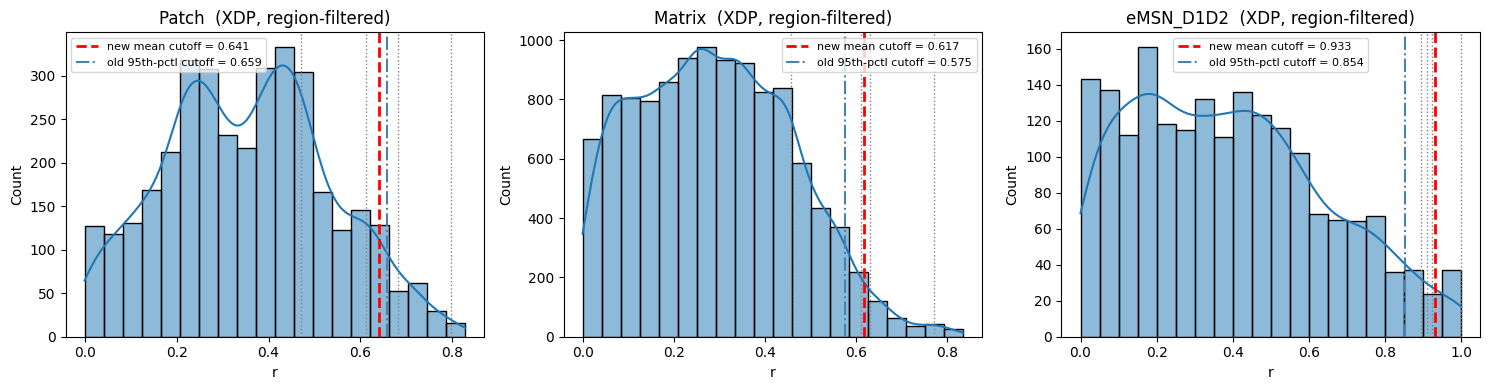

In [12]:
# ── Range-match healthy (BICAN) tissue to the diseased (XDP) tissue extent ──
# Cutoff is now the donor-averaged boundary of SURVIVING tissue, not an arbitrary
# 95th percentile of pooled cells:
#   for each XDP donor, take the PCTL_BOUNDARY-th percentile of `r` among that
#   donor's cells already restricted to region == "healthy" (the dead/degenerated
#   region was already dropped in §3) — this is the most dorsal point of surviving
#   tissue for that donor, i.e. the disease boundary itself. A percentile (not the
#   literal max) guards against one mis-segmented outlier cell setting the whole
#   cutoff. Averaging the per-donor boundary (donor-balanced) instead of pooling
#   all cells first avoids a donor with more cells dominating the estimate — same
#   donor-first-then-combine logic used everywhere else in this notebook.
#
# eMSN_D1D2 has no "dead region" concept (kept regardless of region in §3); if
# `region` isn't informative there, fall back to the same per-donor percentile
# computed over all of that donor's eMSN cells.
PCTL_BOUNDARY = 0.98

def donor_boundary_r(ct, require_healthy_region=True):
    sub = xdp_adata_sub[xdp_adata_sub.obs["ct"] == ct]
    if require_healthy_region and "region" in sub.obs and sub.obs["region"].eq("healthy").any():
        sub = sub[sub.obs["region"] == "healthy"]
    return sub.obs.groupby("donor_id")["r"].quantile(PCTL_BOUNDARY).dropna()

boundary_patch  = donor_boundary_r("Patch")
boundary_matrix = donor_boundary_r("Matrix")
boundary_d1d2   = donor_boundary_r("eMSN_D1D2")

r_cut_patch  = boundary_patch.mean()
r_cut_matrix = boundary_matrix.mean()
r_cut_d1d2   = boundary_d1d2.mean()

print("Per-donor boundary r — Patch:\n",     boundary_patch,  "\n-> mean cutoff:", r_cut_patch, "\n")
print("Per-donor boundary r — Matrix:\n",    boundary_matrix, "\n-> mean cutoff:", r_cut_matrix, "\n")
print("Per-donor boundary r — eMSN_D1D2:\n", boundary_d1d2,   "\n-> mean cutoff:", r_cut_d1d2)

adata_matched = adata[
    ((adata.obs["ct"] == "Patch")     & (adata.obs["r"] <= r_cut_patch))  |
    ((adata.obs["ct"] == "Matrix")    & (adata.obs["r"] <= r_cut_matrix)) |
    ((adata.obs["ct"] == "eMSN_D1D2"))# & (adata.obs["r"] <= r_cut_d1d2))
].copy()

# ── diagnostic: verify the new cutoff against each compartment's XDP r-distribution ──
# grey dotted   = each individual XDP donor's boundary (the spread averaged into r_cut)
# red dashed    = the mean cutoff actually used to build adata_matched
# blue dash-dot = the OLD pooled-95th-percentile cutoff, for comparison
old_cut = {
    "Patch":     xdp_adata_sub[xdp_adata_sub.obs["ct"] == "Patch"].obs["r"].quantile(0.95),
    "Matrix":    xdp_adata_sub[xdp_adata_sub.obs["ct"] == "Matrix"].obs["r"].quantile(0.95),
    "eMSN_D1D2": xdp_adata_sub[xdp_adata_sub.obs["ct"] == "eMSN_D1D2"].obs["r"].quantile(0.95),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ct, boundary, r_cut in zip(
    axes,
    ["Patch", "Matrix", "eMSN_D1D2"],
    [boundary_patch, boundary_matrix, boundary_d1d2],
    [r_cut_patch, r_cut_matrix, r_cut_d1d2],
):
    r_ct = xdp_adata_sub[xdp_adata_sub.obs["ct"] == ct].obs["r"]
    sns.histplot(r_ct, bins=20, kde=True, ax=ax)
    for b in boundary.values:
        ax.axvline(b, color="grey", linestyle=":", lw=1)
    ax.axvline(r_cut, color="red", linestyle="--", lw=2, label=f"new mean cutoff = {r_cut:.3f}")
    ax.axvline(old_cut[ct], color="steelblue", linestyle="-.", lw=1.5, label=f"old 95th-pctl cutoff = {old_cut[ct]:.3f}")
    ax.set_title(f"{ct}  (XDP, region-filtered)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


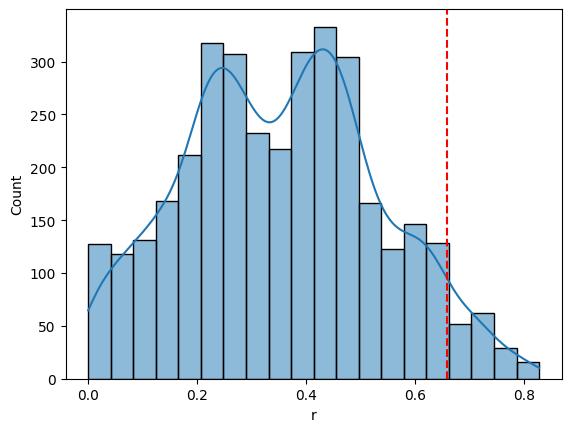

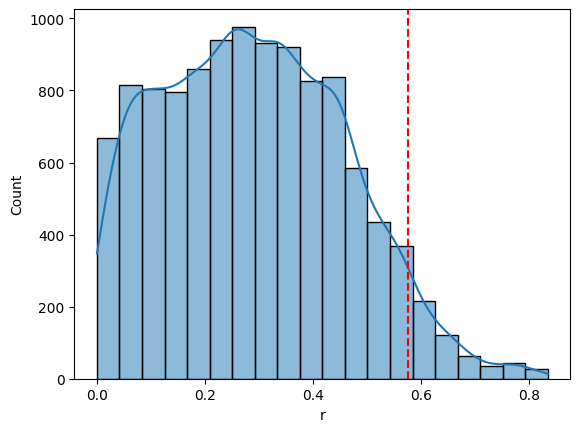

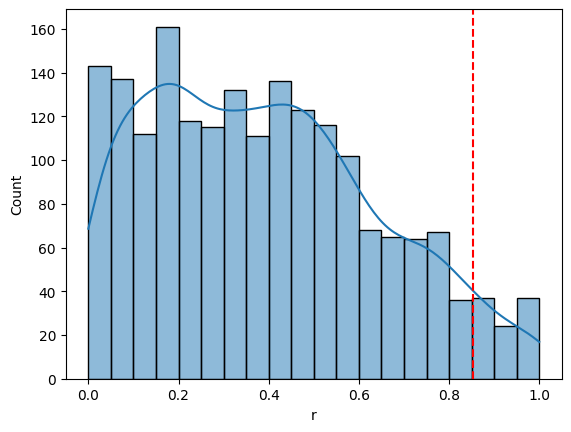

In [ ]:
# # health, restricted to the same r-range XDP cells cover (95th percentile per cell type) —
# # controls for "we just sampled a different chunk of tissue" before comparing health vs XDP
# r_xdp_patch = xdp_adata_sub[xdp_adata_sub.obs["ct"] == "Patch"].obs["r"]
# r_75_xdp_patch = r_xdp_patch.quantile(0.95)
# sns.histplot(r_xdp_patch, bins=20, kde=True); plt.axvline(r_75_xdp_patch, color='red', linestyle='--'); plt.show()

# r_xdp_matrix = xdp_adata_sub[xdp_adata_sub.obs["ct"] == "Matrix"].obs["r"]
# r_75_xdp_matrix = r_xdp_matrix.quantile(0.95)
# sns.histplot(r_xdp_matrix, bins=20, kde=True); plt.axvline(r_75_xdp_matrix, color='red', linestyle='--'); plt.show()

# r_xdp_d1d2 = xdp_adata_sub[xdp_adata_sub.obs["ct"] == "eMSN_D1D2"].obs["r"]
# r_75_xdp_d1d2 = r_xdp_d1d2.quantile(0.95)
# sns.histplot(r_xdp_d1d2, bins=20, kde=True); plt.axvline(r_75_xdp_d1d2, color='red', linestyle='--'); plt.show()

# adata_matched = adata[
#     ((adata.obs["ct"] == "Patch") & (adata.obs["r"] <= r_75_xdp_patch)) |
#     ((adata.obs["ct"] == "Matrix") & (adata.obs["r"] <= r_75_xdp_matrix)) |
#     ((adata.obs["ct"] == "eMSN_D1D2") & (adata.obs["r"] <= r_75_xdp_d1d2))
# ].copy()

In [ ]:
# healthy (BICAN)
df_corr_r_d1d2, df_raw_d1d2 = gf.calc_spatial_corr_multi_donor(adata[adata.obs["ct"] == "eMSN_D1D2"], metric_key="r")
df_corr_r_matrix, df_raw_matrix = gf.calc_spatial_corr_multi_donor(adata[adata.obs["ct"] == "Matrix"], metric_key="r")
df_corr_r_patch, df_raw_patch = gf.calc_spatial_corr_multi_donor(adata[adata.obs["ct"] == "Patch"], metric_key="r")

# xdp
df_corr_r_d1d2_xdp, df_raw_d1d2_xdp = gf.calc_spatial_corr_multi_donor(xdp_adata_sub[xdp_adata_sub.obs["ct"] == "eMSN_D1D2"], metric_key="r")
df_corr_r_matrix_xdp, df_raw_matrix_xdp = gf.calc_spatial_corr_multi_donor(xdp_adata_sub[xdp_adata_sub.obs["ct"] == "Matrix"], metric_key="r")
df_corr_r_patch_xdp, df_raw_patch_xdp = gf.calc_spatial_corr_multi_donor(xdp_adata_sub[xdp_adata_sub.obs["ct"] == "Patch"], metric_key="r")

  Skipping s34: only 0 valid cells
  Skipping s34: only 0 valid cells
  Skipping s34: only 0 valid cells


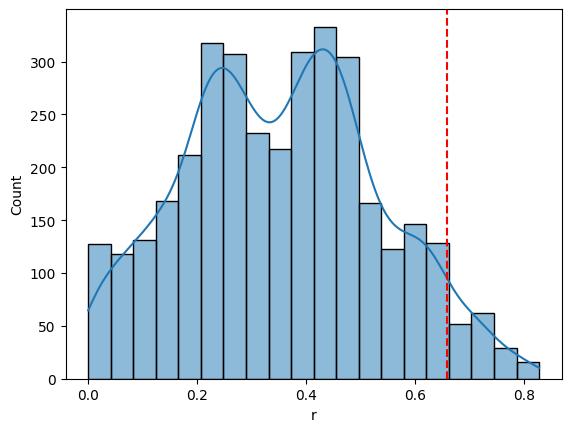

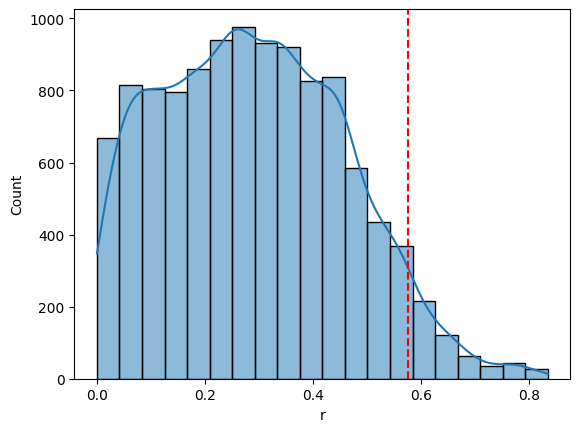

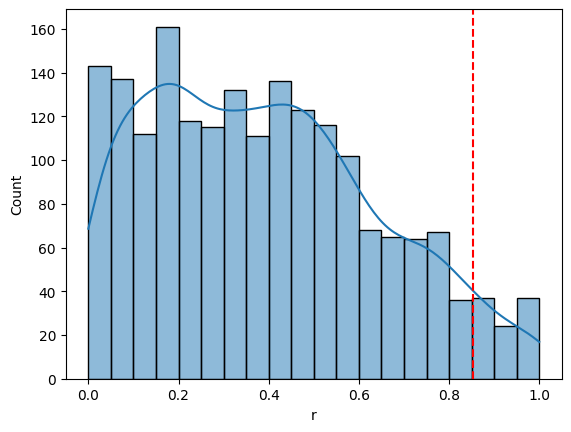

In [ ]:


df_corr_r_patch_matched, df_raw_patch_matched = gf.calc_spatial_corr_multi_donor(adata_matched[(adata_matched.obs["ct"] == "Patch")], metric_key="r")
df_corr_r_matrix_matched, df_raw_matrix_matched = gf.calc_spatial_corr_multi_donor(adata_matched[(adata_matched.obs["ct"] == "Matrix")], metric_key="r")
df_corr_r_d1d2_matched, df_raw_d1d2_matched = gf.calc_spatial_corr_multi_donor(adata_matched[(adata_matched.obs["ct"] == "eMSN_D1D2")], metric_key="r")

In [ ]:
# attach expression stats (pct_expr / mean_expr / log2fc) to each correlation table
for ct, df_ct in zip(["Matrix", "Patch", "eMSN_D1D2"],
                      [df_corr_r_matrix, df_corr_r_patch, df_corr_r_d1d2]):
    stats = gene_expr_stats(adata, ct)
    df_ct["pct_expr"]  = stats["pct_expr"]
    df_ct["mean_expr"] = stats["mean_expr"]
    df_ct["log2fc"]    = stats["log2fc"]

for ct, df_ct in zip(["Matrix", "Patch", "eMSN_D1D2"],
                      [df_corr_r_matrix_matched, df_corr_r_patch_matched, df_corr_r_d1d2_matched]):
    stats = gene_expr_stats(adata_matched, ct)
    df_ct["pct_expr"]  = stats["pct_expr"]
    df_ct["mean_expr"] = stats["mean_expr"]
    df_ct["log2fc"]    = stats["log2fc"]

for ct, df_ct in zip(["Matrix", "Patch", "eMSN_D1D2"],
                      [df_corr_r_matrix_xdp, df_corr_r_patch_xdp, df_corr_r_d1d2_xdp]):
    stats = gene_expr_stats(xdp_adata_sub, ct)
    df_ct["pct_expr"]  = stats["pct_expr"]
    df_ct["mean_expr"] = stats["mean_expr"]
    df_ct["log2fc"]    = stats["log2fc"]

In [ ]:
df_corr = pd.DataFrame({
    "rho_Matrix":  df_corr_r_matrix["rho"],
    "padj_Matrix": df_corr_r_matrix["padj"],
    "rho_Patch":   df_corr_r_patch["rho"],
    "padj_Patch":  df_corr_r_patch["padj"],
    "rho_eMSN":    df_corr_r_d1d2["rho"],
    "padj_eMSN":   df_corr_r_d1d2["padj"],
    "pct_expr_Matrix":  df_corr_r_matrix["pct_expr"],
    "pct_expr_Patch":   df_corr_r_patch["pct_expr"],
    "pct_expr_eMSN":    df_corr_r_d1d2["pct_expr"],
    "mean_expr_Matrix":  df_corr_r_matrix["mean_expr"],
    "mean_expr_Patch":   df_corr_r_patch["mean_expr"],
    "mean_expr_eMSN":    df_corr_r_d1d2["mean_expr"],
    "log2fc_Matrix":  df_corr_r_matrix["log2fc"],
    "log2fc_Patch":   df_corr_r_patch["log2fc"],
    "log2fc_eMSN":    df_corr_r_d1d2["log2fc"],
})

df_corr_matched = pd.DataFrame({
    "rho_Matrix":  df_corr_r_matrix_matched["rho"],
    "padj_Matrix": df_corr_r_matrix_matched["padj"],
    "rho_Patch":   df_corr_r_patch_matched["rho"],
    "padj_Patch":  df_corr_r_patch_matched["padj"],
    "rho_eMSN":    df_corr_r_d1d2_matched["rho"],
    "padj_eMSN":   df_corr_r_d1d2_matched["padj"],
    "pct_expr_Matrix":  df_corr_r_matrix_matched["pct_expr"],
    "pct_expr_Patch":   df_corr_r_patch_matched["pct_expr"],
    "pct_expr_eMSN":    df_corr_r_d1d2_matched["pct_expr"],
    "mean_expr_Matrix":  df_corr_r_matrix_matched["mean_expr"],
    "mean_expr_Patch":   df_corr_r_patch_matched["mean_expr"],
    "mean_expr_eMSN":    df_corr_r_d1d2_matched["mean_expr"],
    "log2fc_Matrix":  df_corr_r_matrix_matched["log2fc"],
    "log2fc_Patch":   df_corr_r_patch_matched["log2fc"],
    "log2fc_eMSN":    df_corr_r_d1d2_matched["log2fc"],
})

df_corr_xdp = pd.DataFrame({
    "rho_Matrix":  df_corr_r_matrix_xdp["rho"],
    "padj_Matrix": df_corr_r_matrix_xdp["padj"],
    "rho_Patch":   df_corr_r_patch_xdp["rho"],
    "padj_Patch":  df_corr_r_patch_xdp["padj"],
    "rho_eMSN":    df_corr_r_d1d2_xdp["rho"],
    "padj_eMSN":   df_corr_r_d1d2_xdp["padj"],
    "pct_expr_Matrix":  df_corr_r_matrix_xdp["pct_expr"],
    "pct_expr_Patch":   df_corr_r_patch_xdp["pct_expr"],
    "pct_expr_eMSN":    df_corr_r_d1d2_xdp["pct_expr"],
    "mean_expr_Matrix":  df_corr_r_matrix_xdp["mean_expr"],
    "mean_expr_Patch":   df_corr_r_patch_xdp["mean_expr"],
    "mean_expr_eMSN":    df_corr_r_d1d2_xdp["mean_expr"],
    "log2fc_Matrix":  df_corr_r_matrix_xdp["log2fc"],
    "log2fc_Patch":   df_corr_r_patch_xdp["log2fc"],
    "log2fc_eMSN":    df_corr_r_d1d2_xdp["log2fc"],
})

# save dfs
df_corr_r_d1d2.to_csv(f"{CORR_DIR}/df_corr_r_d1d2.csv")
df_raw_d1d2.to_csv(f"{CORR_DIR}/df_raw_d1d2.csv")
df_corr_r_matrix.to_csv(f"{CORR_DIR}/df_corr_r_matrix.csv")
df_raw_matrix.to_csv(f"{CORR_DIR}/df_raw_matrix.csv")
df_corr_r_patch.to_csv(f"{CORR_DIR}/df_corr_r_patch.csv")
df_raw_patch.to_csv(f"{CORR_DIR}/df_raw_patch.csv")

df_corr_r_d1d2_matched.to_csv(f"{CORR_DIR}/df_corr_r_d1d2_matched.csv")
df_raw_d1d2_matched.to_csv(f"{CORR_DIR}/df_raw_d1d2_matched.csv")
df_corr_r_matrix_matched.to_csv(f"{CORR_DIR}/df_corr_r_matrix_matched.csv")
df_raw_matrix_matched.to_csv(f"{CORR_DIR}/df_raw_matrix_matched.csv")
df_corr_r_patch_matched.to_csv(f"{CORR_DIR}/df_corr_r_patch_matched.csv")
df_raw_patch_matched.to_csv(f"{CORR_DIR}/df_raw_patch_matched.csv")

df_corr_r_d1d2_xdp.to_csv(f"{CORR_DIR}/df_corr_r_d1d2_xdp.csv")
df_raw_d1d2_xdp.to_csv(f"{CORR_DIR}/df_raw_d1d2_xdp.csv")
df_corr_r_matrix_xdp.to_csv(f"{CORR_DIR}/df_corr_r_matrix_xdp.csv")
df_raw_matrix_xdp.to_csv(f"{CORR_DIR}/df_raw_matrix_xdp.csv")
df_corr_r_patch_xdp.to_csv(f"{CORR_DIR}/df_corr_r_patch_xdp.csv")
df_raw_patch_xdp.to_csv(f"{CORR_DIR}/df_raw_patch_xdp.csv")

df_corr.to_csv(f"{CORR_DIR}/df_corr.csv")
df_corr_matched.to_csv(f"{CORR_DIR}/df_corr_matched.csv")
df_corr_xdp.to_csv(f"{CORR_DIR}/df_corr_xdp.csv")

display(df_corr)
display(df_corr_matched)
display(df_corr_xdp)

,rho_Matrix,padj_Matrix,rho_Patch,padj_Patch,rho_eMSN,padj_eMSN,pct_expr_Matrix,pct_expr_Patch,pct_expr_eMSN,mean_expr_Matrix,mean_expr_Patch,mean_expr_eMSN,log2fc_Matrix,log2fc_Patch,log2fc_eMSN
A1BG,-0.048231,2.534720e-23,-0.012159,2.179943e-01,0.013109,0.637292,0.196946,0.183558,0.158377,0.242469,0.221026,0.193437,-0.010553,-0.003151,-0.001726
A1BG-AS1,-0.009289,2.270067e-01,-0.005805,6.351553e-01,0.015365,0.538175,0.459240,0.491040,0.327288,0.727594,0.800442,0.465112,-0.006735,-0.002785,0.005334
A1CF,-0.014554,2.869130e-05,-0.023386,1.217217e-02,0.006636,0.892682,0.016567,0.018501,0.007081,0.018562,0.019490,0.007254,-0.001010,-0.001499,0.000092
A2M,-0.032550,6.186915e-02,-0.031258,5.782571e-02,-0.009668,0.781835,0.065067,0.049162,0.026425,0.071220,0.054224,0.030397,-0.003175,-0.002705,-0.001257
A2M-AS1,-0.015756,1.241760e-01,0.015935,2.754820e-01,-0.016973,0.469941,0.112428,0.110775,0.088256,0.129769,0.127996,0.099136,-0.003200,0.002605,-0.004317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYX,-0.056288,2.086303e-04,-0.056927,1.071388e-04,0.005886,0.919741,0.447572,0.382476,0.398618,0.697269,0.561671,0.594473,-0.018566,-0.014540,0.002761
ZZEF1,-0.020588,2.819683e-01,-0.023727,1.321861e-01,-0.037641,0.026111,0.931945,0.936467,0.898618,4.881795,5.127124,4.209326,-0.014244,-0.019341,-0.030360
ZZZ3,-0.111431,1.860811e-07,-0.095340,2.552897e-11,-0.069443,0.000069,0.961831,0.957587,0.921934,8.671416,8.693216,6.282383,-0.087191,-0.078487,-0.038700
hsa-mir-1253,0.000709,8.862429e-01,0.000000,1.000000e+00,0.000000,1.000000,0.000031,0.000000,0.000000,0.000031,0.000000,0.000000,0.000003,0.000000,0.000000


,rho_Matrix,padj_Matrix,rho_Patch,padj_Patch,rho_eMSN,padj_eMSN,pct_expr_Matrix,pct_expr_Patch,pct_expr_eMSN,mean_expr_Matrix,mean_expr_Patch,mean_expr_eMSN,log2fc_Matrix,log2fc_Patch,log2fc_eMSN
A1BG,-0.033851,4.754091e-08,-0.001203,9.754181e-01,0.029785,0.130163,0.209578,0.189179,0.163798,0.260164,0.228919,0.200000,-0.008065,-0.002166,0.002451
A1BG-AS1,-0.001274,9.167874e-01,0.001997,9.546053e-01,0.021059,0.364069,0.462841,0.494691,0.329970,0.741795,0.811368,0.470821,-0.004992,-0.000003,0.006510
A1CF,-0.008394,9.224620e-02,-0.015424,1.857281e-01,0.016279,0.548805,0.018407,0.020222,0.007715,0.020901,0.021471,0.007913,-0.000579,-0.001002,0.000274
A2M,-0.016278,2.472592e-01,-0.014622,3.472071e-01,-0.008122,0.867629,0.070584,0.051921,0.026706,0.077775,0.057776,0.031058,-0.002041,-0.001044,-0.000501
A2M-AS1,-0.007441,3.334416e-01,0.016607,1.634141e-01,-0.002884,1.000000,0.116900,0.108292,0.090999,0.135215,0.124141,0.102671,-0.002447,0.000662,-0.002463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYX,-0.073889,1.426562e-13,-0.064296,1.003548e-07,-0.003052,1.000000,0.448764,0.387024,0.394857,0.701262,0.571830,0.585163,-0.023315,-0.018167,-0.001061
ZZEF1,-0.023314,8.110796e-02,-0.032628,3.179885e-03,-0.036701,0.044377,0.930288,0.938398,0.900495,4.969933,5.202764,4.257171,-0.015175,-0.017956,-0.026278
ZZZ3,-0.062945,4.158835e-04,-0.073409,7.050706e-09,-0.066863,0.000104,0.963109,0.962211,0.923046,9.047494,8.924813,6.340059,-0.051203,-0.045387,-0.038178
hsa-mir-1253,-0.000661,9.175365e-01,0.000000,1.000000e+00,0.000000,1.000000,0.000015,0.000000,0.000000,0.000015,0.000000,0.000000,0.000000,0.000000,0.000000


,rho_Matrix,padj_Matrix,rho_Patch,padj_Patch,rho_eMSN,padj_eMSN,pct_expr_Matrix,pct_expr_Patch,pct_expr_eMSN,mean_expr_Matrix,mean_expr_Patch,mean_expr_eMSN,log2fc_Matrix,log2fc_Patch,log2fc_eMSN
gene_symbol,,,,,,,,,,,,,,,
A1BG,-0.035387,0.415850,-0.070565,0.167678,-0.078767,0.002613,0.216060,0.192967,0.146008,0.264064,0.234134,0.167017,-0.019019,-0.022182,-0.028848
A1BG-AS1,0.026000,0.506741,0.013888,0.844142,0.023570,0.702391,0.337711,0.371641,0.231618,0.467791,0.529445,0.298319,-0.002862,0.002845,0.004215
A1CF,-0.013794,0.543864,0.010324,0.802509,0.004207,1.000000,0.008696,0.006861,0.001050,0.009494,0.007147,0.001050,-0.000742,-0.001304,-0.000491
A2M,0.022090,0.062559,0.023016,0.419833,-0.004132,1.000000,0.025821,0.024585,0.003676,0.027507,0.027444,0.004202,-0.001123,0.003235,-0.001091
A2M-AS1,0.021055,0.078886,-0.026096,0.334351,-0.006234,0.992430,0.077995,0.071755,0.055672,0.085271,0.078045,0.061450,0.000147,-0.006590,-0.002787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11B,-0.065958,0.030807,-0.037139,0.117279,-0.098217,0.000109,0.767702,0.765866,0.792542,1.980568,1.973699,2.204307,-0.047072,-0.044455,-0.082450
ZYX,-0.044102,0.000031,0.033371,0.223431,0.032173,0.509529,0.306389,0.269297,0.271534,0.416149,0.358776,0.355567,-0.026611,0.006238,0.007486
ZZEF1,0.036131,0.327503,0.041185,0.549060,0.013678,0.919068,0.835138,0.845340,0.784664,2.655546,2.973128,2.381828,0.030095,0.033475,-0.002129


## 9. Reload correlation tables

Alternate entry point — start here to skip re-running Part 8 once the CSVs exist on disk.

In [13]:
df_corr = pd.read_csv(f"{CORR_DIR}/df_corr.csv", index_col=0)
df_corr_matched = pd.read_csv(f"{CORR_DIR}/df_corr_matched.csv", index_col=0)
df_corr_xdp = pd.read_csv(f"{CORR_DIR}/df_corr_xdp.csv", index_col=0)

## 10. Healthy-tissue analysis: which genes gradient in which compartment

### 10.1 Compartment agreement (Matrix vs Patch vs eMSN)

For every pair of cell types, classify each gene as agreeing, disagreeing, or specific to one
compartment (using `classify_gradient_agreement` / `plot_gradient_agreement` from §7.4).

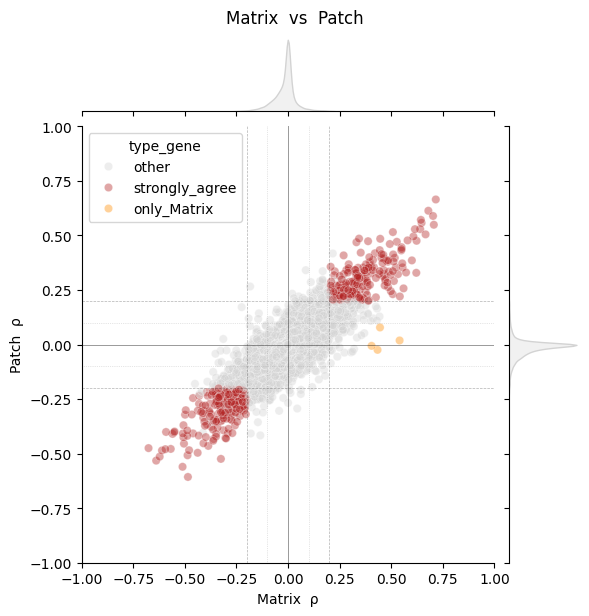

type_gene
other             24084
strongly_agree      423
only_Matrix           4
Name: Matrix  vs  Patch, dtype: int64

strongly_disagree


,rho_Matrix,rho_Patch,padj_Matrix,padj_Patch,pct_expr_Matrix,pct_expr_Patch,mean_expr_Matrix,mean_expr_Patch,type_gene


only_Matrix


,rho_Matrix,rho_Patch,padj_Matrix,padj_Patch,pct_expr_Matrix,pct_expr_Patch,mean_expr_Matrix,mean_expr_Patch,type_gene
GLI3,0.540486,0.018892,1.246207e-215,0.125734,0.448053,0.073074,2.582689,0.094543,only_Matrix
THSD4,0.445462,0.078393,4.656115e-67,0.000047,0.530721,0.276472,5.600750,0.978997,only_Matrix
CPNE8,0.433598,-0.024171,1.132210e-35,0.189137,0.406520,0.118222,2.401809,0.464161,only_Matrix
LINC02822,0.404716,-0.005880,1.821935e-34,0.705274,0.541971,0.129625,18.933094,0.316791,only_Matrix


only_Patch


,rho_Matrix,rho_Patch,padj_Matrix,padj_Patch,pct_expr_Matrix,pct_expr_Patch,mean_expr_Matrix,mean_expr_Patch,type_gene


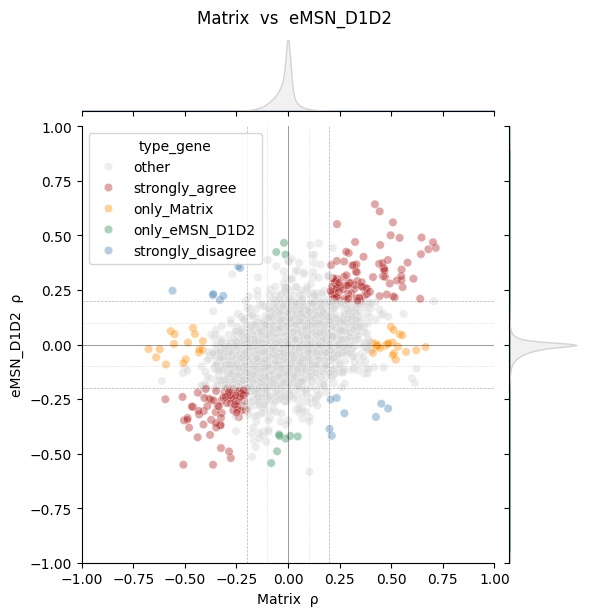

type_gene
other                24274
strongly_agree         173
only_Matrix             39
strongly_disagree       15
only_eMSN_D1D2          10
Name: Matrix  vs  eMSN_D1D2, dtype: int64

strongly_disagree


,rho_Matrix,rho_eMSN,padj_Matrix,padj_eMSN,pct_expr_Matrix,pct_expr_eMSN,mean_expr_Matrix,mean_expr_eMSN,type_gene
CDH12,-0.559620,0.247003,4.335066e-122,1.218190e-21,0.997587,0.972884,96.802323,44.110190,strongly_disagree
DPP10,0.484797,-0.293071,1.243405e-53,1.317840e-19,0.833608,0.940415,17.647798,43.974784,strongly_disagree
GRM3,0.451929,-0.271076,3.395381e-66,1.639711e-16,0.991560,0.404318,61.861394,2.791537,strongly_disagree
CHRM3,0.425570,-0.331614,3.216820e-66,9.323205e-27,0.704561,0.543351,32.216323,10.452677,strongly_disagree
SLC8A1,-0.364297,0.226389,1.288468e-43,1.477508e-11,0.999509,0.981520,115.458123,39.438860,strongly_disagree
UTRN,-0.362509,0.231441,2.296004e-55,5.642220e-10,0.985156,0.352332,31.496605,0.913644,strongly_disagree
MTUS1,-0.330538,0.204173,2.884975e-89,2.427949e-14,0.808288,0.982556,3.384856,15.403972,strongly_disagree
SEMA3E,-0.313844,0.223156,5.498518e-20,1.573788e-14,0.207047,0.405699,1.339677,3.276339,strongly_disagree
DMD,0.272986,-0.315074,2.707525e-23,6.793913e-22,0.973583,0.766149,21.701761,5.090674,strongly_disagree
SGCZ,-0.240748,0.358735,4.754444e-14,2.610713e-15,0.998005,0.753541,114.891175,32.035060,strongly_disagree


only_Matrix


,rho_Matrix,rho_eMSN,padj_Matrix,padj_eMSN,pct_expr_Matrix,pct_expr_eMSN,mean_expr_Matrix,mean_expr_eMSN,type_gene
PRKG1,-0.676010,-0.020873,4.173427e-183,0.437440,0.884124,0.292746,37.336763,1.049741,only_Matrix
TESPA1,0.666248,-0.011161,2.642479e-195,0.918206,0.572306,0.255613,6.724930,0.859067,only_Matrix
ARHGAP6,-0.638952,-0.058419,4.105302e-133,0.037537,0.515345,0.105181,3.957715,0.209499,only_Matrix
GDA,-0.621995,-0.021770,1.330288e-142,0.372864,0.651924,0.081002,3.903167,0.113472,only_Matrix
SLC24A2,0.621282,-0.025991,5.765366e-47,0.586385,0.994119,0.598964,90.518124,3.183592,only_Matrix
HCN1,-0.591152,-0.091272,5.886225e-65,0.000008,0.632735,0.984111,8.003134,20.656649,only_Matrix
SPOCK1,0.571685,-0.033614,2.934313e-101,0.245819,0.961277,0.393610,32.018646,1.136960,only_Matrix
ABLIM1,-0.568271,0.061717,8.048259e-121,0.094211,0.991737,0.960967,16.957527,7.994473,only_Matrix
SAMD5,0.553243,0.042432,3.185591e-151,0.090326,0.895061,0.157686,24.817522,0.813817,only_Matrix
ERC2,-0.552653,0.002641,6.093234e-145,0.999874,0.987361,0.909154,31.214620,9.002418,only_Matrix


only_eMSN_D1D2


,rho_Matrix,rho_eMSN,padj_Matrix,padj_eMSN,pct_expr_Matrix,pct_expr_eMSN,mean_expr_Matrix,mean_expr_eMSN,type_gene
TENM3,-0.081627,-0.543231,6.205852e-06,1.308136e-90,0.993033,0.778066,34.755317,13.407081,only_eMSN_D1D2
SPATS2L,-0.053367,-0.489342,1.090580e-02,2.592997e-134,0.422649,0.639378,1.525174,4.617444,only_eMSN_D1D2
GRIK1,-0.019553,0.466437,1.651488e-01,5.788048e-48,0.032727,0.801209,0.036383,105.874784,only_eMSN_D1D2
DIRC3-AS1,-0.011650,-0.430772,6.473084e-01,1.873595e-64,0.998841,0.831088,108.498120,22.865803,only_eMSN_D1D2
CABP1,-0.057118,0.424500,8.287834e-07,6.872696e-82,0.829232,0.918826,3.010561,5.259585,only_eMSN_D1D2
SOX2-OT,0.046894,-0.421133,1.323038e-02,5.340996e-66,0.979965,0.997582,24.074416,84.345596,only_eMSN_D1D2
NDST4,-0.041042,-0.419624,1.212593e-02,2.576267e-84,0.067167,0.223834,0.219759,1.894646,only_eMSN_D1D2
CADPS,0.011185,-0.418536,8.346853e-01,4.643815e-45,0.997451,0.997582,31.908871,34.741623,only_eMSN_D1D2
PDE3A,-0.043513,-0.412491,1.377608e-01,9.220993e-51,0.944439,0.916235,8.404556,11.563212,only_eMSN_D1D2
CALCRL,-0.012395,0.412308,5.814804e-01,1.993239e-22,0.128776,0.625216,0.790279,8.564076,only_eMSN_D1D2


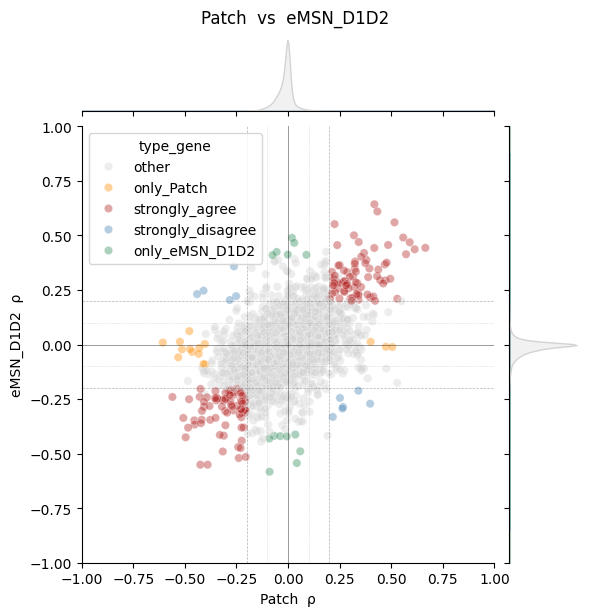

type_gene
other                24319
strongly_agree         152
only_Patch              15
only_eMSN_D1D2          14
strongly_disagree       11
Name: Patch  vs  eMSN_D1D2, dtype: int64

strongly_disagree


,rho_Patch,rho_eMSN,padj_Patch,padj_eMSN,pct_expr_Patch,pct_expr_eMSN,mean_expr_Patch,mean_expr_eMSN,type_gene
UTRN,-0.440857,0.231441,2.717201e-38,5.642220e-10,0.913428,0.352332,18.378636,0.913644,strongly_disagree
CDH12,-0.409449,0.247003,4.896275e-110,1.218190e-21,0.994647,0.972884,67.774843,44.110190,strongly_disagree
GRM3,0.397544,-0.271076,7.852892e-56,1.639711e-16,0.996684,0.404318,86.083372,2.791537,strongly_disagree
RGS12,0.341011,-0.211566,3.806950e-21,8.895204e-23,0.989237,0.824698,22.241564,3.127634,strongly_disagree
MTUS1,-0.282286,0.204173,2.153772e-59,2.427949e-14,0.842797,0.982556,3.792297,15.403972,strongly_disagree
BACH2,0.266358,-0.286096,1.217726e-12,1.023518e-38,0.880323,0.990328,21.062020,38.008463,strongly_disagree
DPP10,0.263482,-0.293071,3.168378e-16,1.317840e-19,0.717303,0.940415,10.123633,43.974784,strongly_disagree
SGCZ,-0.262074,0.358735,2.224213e-17,2.610713e-15,0.989586,0.753541,83.708052,32.035060,strongly_disagree
MAGI2,-0.251821,0.221835,6.709138e-24,4.387725e-36,0.998953,0.999309,87.988771,150.854231,strongly_disagree
DCBLD2,0.251477,-0.244663,9.752482e-48,4.162489e-30,0.829474,0.931088,3.718175,6.860622,strongly_disagree


only_Patch


,rho_Patch,rho_eMSN,padj_Patch,padj_eMSN,pct_expr_Patch,pct_expr_eMSN,mean_expr_Patch,mean_expr_eMSN,type_gene
RGS6,-0.606829,0.009166,4.698678e-87,8.007019e-01,0.815685,0.105009,18.458692,0.181174,only_Patch
ARHGAP6,-0.532040,-0.058419,9.913555e-186,3.753745e-02,0.390912,0.105181,2.252560,0.209499,only_Patch
SEMA3A,-0.523999,0.013114,2.925200e-56,8.832860e-01,0.859553,0.929706,11.149988,12.701382,only_Patch
GDA,-0.513747,-0.021770,1.703234e-103,3.728642e-01,0.409879,0.081002,1.401501,0.113472,only_Patch
TESPA1,0.505129,-0.011161,2.398092e-67,9.182062e-01,0.462183,0.255613,4.446183,0.859067,only_Patch
ABLIM1,-0.478316,0.061717,3.803013e-91,9.421104e-02,0.992378,0.960967,16.324645,7.994473,only_Patch
PRKG1,-0.474623,-0.020873,1.065938e-75,4.374399e-01,0.807075,0.292746,22.695543,1.049741,only_Patch
DPP6,0.473785,-0.009857,4.503459e-125,9.551843e-01,0.999942,0.999655,175.737957,88.386874,only_Patch
MYRIP,-0.464510,-0.034191,5.468678e-84,3.665482e-01,0.792879,0.559585,6.303060,2.197409,only_Patch
PCDH11X,-0.433070,-0.042415,8.590837e-78,1.201517e-01,0.718175,0.235924,23.708925,0.466494,only_Patch


only_eMSN_D1D2


,rho_Patch,rho_eMSN,padj_Patch,padj_eMSN,pct_expr_Patch,pct_expr_eMSN,mean_expr_Patch,mean_expr_eMSN,type_gene
NDST3,-0.089483,-0.582899,1.712970e-04,2.669428e-95,0.995986,0.538515,44.630265,6.049050,only_eMSN_D1D2
TENM3,0.042537,-0.543231,3.299850e-02,1.308136e-90,0.995462,0.778066,44.402141,13.407081,only_eMSN_D1D2
SPATS2L,0.058985,-0.489342,4.231069e-02,2.592997e-134,0.695078,0.639378,3.795439,4.617444,only_eMSN_D1D2
GLI3,0.018892,0.489252,1.257336e-01,1.439224e-43,0.073074,0.357858,0.094543,2.750432,only_eMSN_D1D2
GRIK1,0.030036,0.466437,5.343754e-02,5.788048e-48,0.065802,0.801209,0.081859,105.874784,only_eMSN_D1D2
DIRC3-AS1,-0.090630,-0.430772,1.263543e-09,1.873595e-64,0.999709,0.831088,113.219863,22.865803,only_eMSN_D1D2
CABP1,-0.055289,0.424500,8.134647e-06,6.872696e-82,0.770421,0.918826,2.516349,5.259585,only_eMSN_D1D2
SOX2-OT,-0.005868,-0.421133,7.976256e-01,5.340996e-66,0.982837,0.997582,25.698976,84.345596,only_eMSN_D1D2
NDST4,-0.038030,-0.419624,9.227879e-03,2.576267e-84,0.040435,0.223834,0.059751,1.894646,only_eMSN_D1D2
CADPS,-0.067769,-0.418536,3.309520e-02,4.643815e-45,0.997440,0.997582,34.342855,34.741623,only_eMSN_D1D2


In [14]:
THRESHOLD          = 0.2    # minimum |rho| to count as "has gradient"
THRESHOLD_SPECIFIC = 0.4    # minimum |rho| to count as "cell-type specific"
THRESHOLD_ONLY     = 0.1    # maximum |rho| to count as "truly absent"
PADJ_THR           = 0.05
MIN_PCT_EXPR       = 0.20   # require detection in >=20% of cells to trust a gene's correlation
MIN_MEAN_EXPR      = 0.10   # require mean expression above this to trust a gene's correlation

# df_corr columns use "eMSN", not "eMSN_D1D2" — map so we can still iterate over the ct names
# used everywhere else (adata.obs["ct"], plot titles, "only_<ct>" labels).
col_label = {"Matrix": "Matrix", "Patch": "Patch", "eMSN_D1D2": "eMSN"}

for ct_x, ct_y in combinations(["Matrix", "Patch", "eMSN_D1D2"], 2):
    lx, ly = col_label[ct_x], col_label[ct_y]
    df_pair = gf.classify_gradient_agreement(
        df_corr,
        rho_x=f"rho_{lx}", rho_y=f"rho_{ly}",
        padj_x=f"padj_{lx}", padj_y=f"padj_{ly}",
        pexpr_x=f"pct_expr_{lx}", pexpr_y=f"pct_expr_{ly}",
        mexpr_x=f"mean_expr_{lx}", mexpr_y=f"mean_expr_{ly}",
        threshold=THRESHOLD, threshold_specific=THRESHOLD_SPECIFIC, threshold_only=THRESHOLD_ONLY,
        padj_thr=PADJ_THR, min_pct_expr=MIN_PCT_EXPR, min_mean_expr=MIN_MEAN_EXPR,
        label_x=ct_x, label_y=ct_y,
    )
    gf.plot_gradient_agreement(
        df_pair, rho_x=f"rho_{lx}", rho_y=f"rho_{ly}",
        threshold=THRESHOLD, threshold_only=THRESHOLD_ONLY,
        label_x=ct_x, label_y=ct_y,
        xlabel=f"{ct_x}  ρ", ylabel=f"{ct_y}  ρ",
        title=f"{ct_x}  vs  {ct_y}",
    )

### 10.2 Distribution of significant/reliable genes

In [16]:
def reliable_and_sig(ct):
    return (
        (df_corr[f"padj_{ct}"]      < PADJ_THR) &
        (df_corr[f"pct_expr_{ct}"]  >= MIN_PCT_EXPR) &
        (df_corr[f"mean_expr_{ct}"] >= 0.1)
    )

interesting = reliable_and_sig("Matrix") | reliable_and_sig("Patch") | reliable_and_sig("eMSN")
df_corr_sig = df_corr[interesting].copy()
print(f"{len(df_corr_sig)} / {len(df_corr)} genes pass")

10745 / 24511 genes pass


In [38]:
# for ct, col in zip(["Matrix", "Patch", "eMSN"], ["darkorange", "seagreen", "steelblue"]):
#     plt.figure(figsize=(5, 4))
#     sig = df_corr[f"padj_{ct}"] < PADJ_THR
#     plt.scatter(df_corr[f"rho_{ct}"][~sig], -np.log10(df_corr[f"padj_{ct}"][~sig]), s=5, c="lightgrey")
#     plt.scatter(df_corr[f"rho_{ct}"][sig],  -np.log10(df_corr[f"padj_{ct}"][sig]),  s=5, c=col)
#     plt.axhline(-np.log10(PADJ_THR), ls="--", c="grey", lw=0.8)
#     plt.xlabel(f"rho_{ct}"); plt.ylabel("-log10(padj)"); plt.title(ct)
#     plt.show()

# for ct in ["Matrix", "Patch", "eMSN"]:
#     plt.figure(figsize=(5, 4))
#     sc_plot = plt.scatter(df_corr_sig[f"rho_{ct}"], df_corr_sig[f"log2fc_{ct}"],
#                            c=df_corr_sig[f"pct_expr_{ct}"], cmap="viridis", s=10)
#     plt.colorbar(sc_plot, label="pct_expr")
#     plt.xlabel(f"rho_{ct}"); plt.ylabel(f"log2fc_{ct}"); plt.title(ct)
#     plt.show()

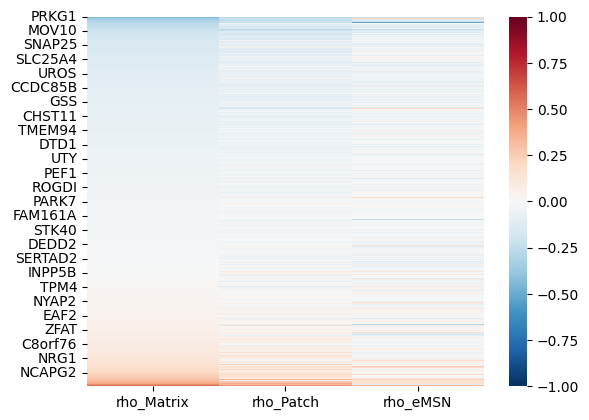

In [17]:
sns.heatmap(df_corr_sig[["rho_Matrix", "rho_Patch", "rho_eMSN"]].sort_values("rho_Matrix"),
            cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.show()

### 10.3 Candidate risk factors
**HIGH in DORSAL Matrix+Patch (rho>0), flat in eMSN.**
Gene highest where degeneration starts; eMSN spared without it.

,rho_Matrix,log2fc_Matrix,pct_expr_Matrix,mean_expr_Matrix,rho_Patch,log2fc_Patch,pct_expr_Patch,mean_expr_Patch,rho_eMSN,log2fc_eMSN,pct_expr_eMSN,mean_expr_eMSN
PLCB1,0.706276,0.967527,0.998391,223.491173,0.549205,0.581647,0.999709,296.380731,0.198680,0.157689,1.000000,374.561313
VLDLR-AS1,0.614627,0.773940,0.963043,18.286341,0.528868,0.620013,0.982255,21.158541,-0.175917,-0.195922,0.921071,8.348359
TESPA1,0.666248,0.836282,0.572306,6.724930,0.505129,0.534233,0.462183,4.446183,-0.011161,-0.018998,0.255613,0.859067
SEMA6D,0.343893,0.638009,0.914950,40.128557,0.485655,0.876482,0.984175,99.648708,0.148769,0.219652,0.999136,223.498273
GRIN2A,0.395816,0.663505,0.786748,14.959836,0.366266,0.512373,0.945485,23.112520,0.127035,0.112407,0.997237,63.039724
IQCA1,0.405729,0.543187,0.928530,11.200549,0.355505,0.521456,0.929428,12.833721,-0.022950,-0.024815,0.758549,3.005181
COL25A1,0.522336,0.936643,0.879204,23.394696,0.353959,0.558622,0.973528,43.180882,-0.069465,-0.047396,0.477547,2.127116
TRPC6,0.507861,0.746020,0.653909,9.547424,0.336826,0.522612,0.737666,12.808820,-0.048867,-0.033045,0.183765,0.702936
PTPRM,0.278017,0.714471,0.919954,46.646941,0.253508,0.564115,0.963172,50.909763,-0.074004,-0.073970,0.981520,27.585492


,rho_Matrix,log2fc_Matrix,pct_expr_Matrix,mean_expr_Matrix,rho_Patch,log2fc_Patch,pct_expr_Patch,mean_expr_Patch,rho_eMSN,log2fc_eMSN,pct_expr_eMSN,mean_expr_eMSN
VLDLR-AS1,0.614627,0.773940,0.963043,18.286341,0.528868,0.620013,0.982255,21.158541,-0.175917,-0.195922,0.921071,8.348359
TESPA1,0.666248,0.836282,0.572306,6.724930,0.505129,0.534233,0.462183,4.446183,-0.011161,-0.018998,0.255613,0.859067
IQCA1,0.405729,0.543187,0.928530,11.200549,0.355505,0.521456,0.929428,12.833721,-0.022950,-0.024815,0.758549,3.005181
COL25A1,0.522336,0.936643,0.879204,23.394696,0.353959,0.558622,0.973528,43.180882,-0.069465,-0.047396,0.477547,2.127116
TRPC6,0.507861,0.746020,0.653909,9.547424,0.336826,0.522612,0.737666,12.808820,-0.048867,-0.033045,0.183765,0.702936
PTPRM,0.278017,0.714471,0.919954,46.646941,0.253508,0.564115,0.963172,50.909763,-0.074004,-0.073970,0.981520,27.585492


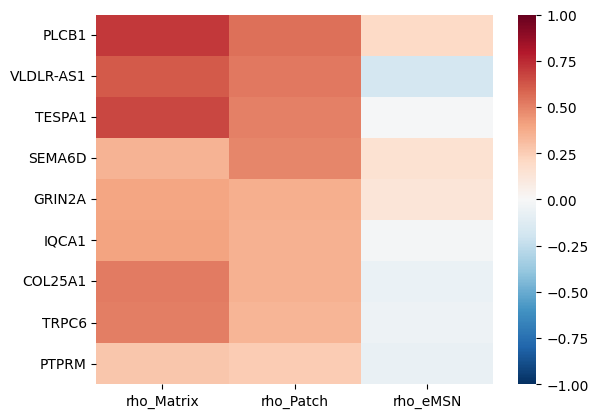

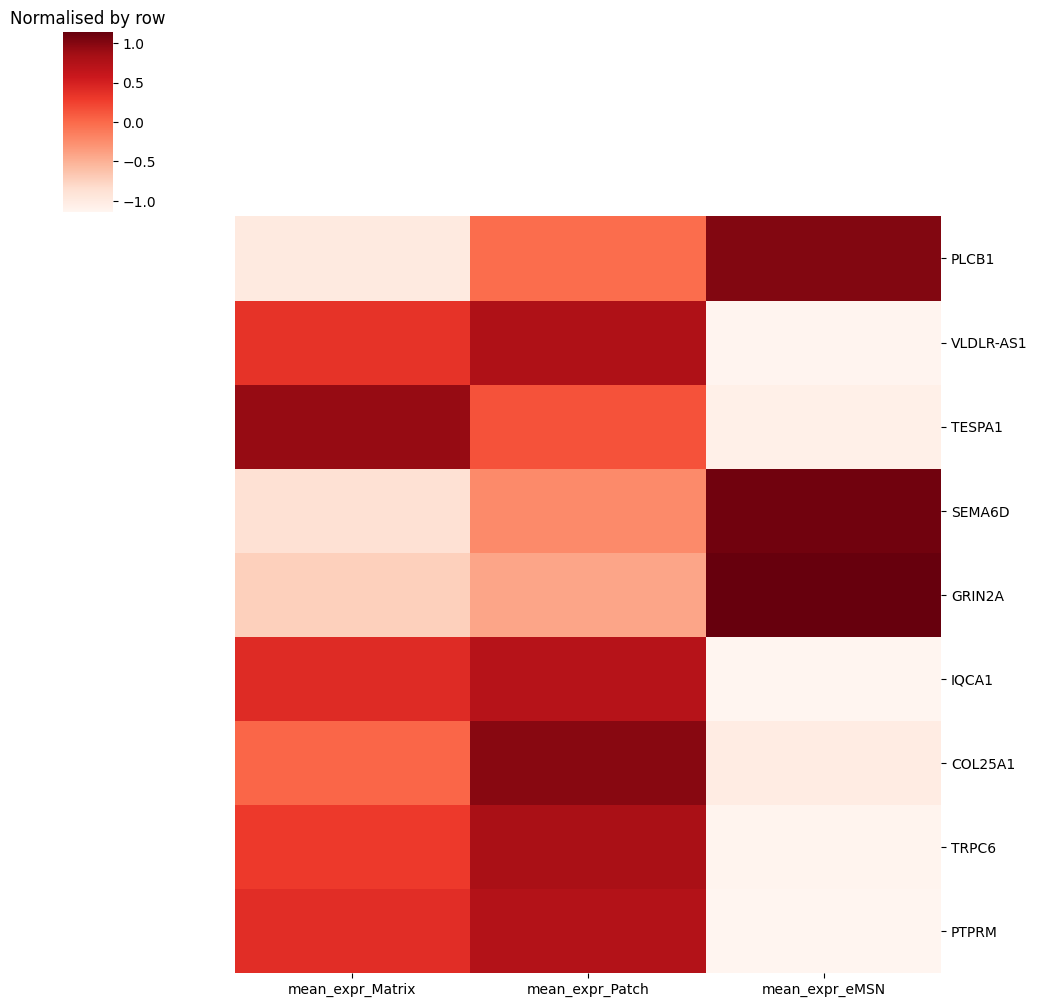

In [70]:
MIN_CORR = 0.2
MIN_LOGFC = 0.5
MIN_PCT_EXPR = 0.2
MIN_MEAN_EXPR = 0.1

df_risk_factors = df_corr[
    (df_corr["rho_Matrix"] >= MIN_CORR) & (df_corr["rho_Patch"] >= MIN_CORR) & # corr big enough in matrix and patch
    (df_corr["rho_eMSN"].abs() <= MIN_CORR) & # no correlation in d1d2
    (df_corr["log2fc_Matrix"].abs() >= MIN_LOGFC) & (df_corr["log2fc_Patch"].abs() >= MIN_LOGFC) & # logfc big enough
    ((df_corr["padj_Matrix"] < 0.05) & (df_corr["padj_Patch"] < 0.05)) & # significant in at least one cell type
    (df_corr["pct_expr_Matrix"] >= MIN_PCT_EXPR) & (df_corr["pct_expr_Patch"] >= MIN_PCT_EXPR) &# sufficient expression in both cell types
    (df_corr["mean_expr_Matrix"] >= MIN_MEAN_EXPR) & (df_corr["mean_expr_Patch"] >= MIN_MEAN_EXPR) # sufficient mean expression in both cell types
].copy()

df_risk_factors = df_risk_factors[["rho_Matrix", "log2fc_Matrix", "pct_expr_Matrix", "mean_expr_Matrix",
                 "rho_Patch", "log2fc_Patch", "pct_expr_Patch", "mean_expr_Patch",
                 "rho_eMSN", "log2fc_eMSN", "pct_expr_eMSN", "mean_expr_eMSN"]].sort_values("rho_Patch", key=np.abs, ascending=False)
display(df_risk_factors)

df_risk_factors_less_d1d2 = df_risk_factors[df_risk_factors["mean_expr_eMSN"] < df_risk_factors["mean_expr_Matrix"] ].copy()
display(df_risk_factors_less_d1d2)

sns.heatmap(df_risk_factors[["rho_Matrix", "rho_Patch", "rho_eMSN"]], cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.show()

sns.clustermap(df_risk_factors[["mean_expr_Matrix", "mean_expr_Patch", "mean_expr_eMSN"]], 
               cmap="Reds", 
               z_score=0,          # 0 scales by row, 1 scales by column
               row_cluster=False,  # Disables row shuffling
               col_cluster=False)  # Disables column shuffling
plt.title("Normalised by row")
plt.show()

### 10.4 Candidate neuroprotective genes
**HIGH in VENTRAL Matrix+Patch (rho<0), flat in eMSN.**
Gene protects surviving ventral cells; its ABSENCE in dorsal explains why dorsal dies first.

,rho_Matrix,log2fc_Matrix,pct_expr_Matrix,mean_expr_Matrix,rho_Patch,log2fc_Patch,pct_expr_Patch,mean_expr_Patch,rho_eMSN,log2fc_eMSN,pct_expr_eMSN,mean_expr_eMSN
RGS6,-0.485113,-0.727751,0.935006,26.549806,-0.606829,-1.021910,0.815685,18.458692,0.009166,0.000754,0.105009,0.181174
GRIA4,-0.610808,-0.739797,0.523096,5.182405,-0.485470,-0.504132,0.403712,2.788166,-0.166973,-0.244597,0.570294,6.229879
PRKG1,-0.676010,-1.443493,0.884124,37.336763,-0.474623,-0.965892,0.807075,22.695543,-0.020873,-0.048440,0.292746,1.049741
PCDH11X,-0.361397,-0.593957,0.980842,73.632129,-0.433070,-0.988705,0.718175,23.708925,-0.042415,-0.023759,0.235924,0.466494
HCN1,-0.591152,-0.881618,0.632735,8.003134,-0.400616,-0.516136,0.717477,6.881022,-0.091272,-0.103405,0.984111,20.656649
GALNTL6,-0.550037,-1.043120,0.949097,50.577581,-0.398703,-0.645883,0.993717,82.581627,0.048259,0.061845,0.999827,388.358377
AGBL1,-0.273641,-0.678406,0.799074,25.278517,-0.278412,-0.546481,0.627414,9.455201,0.014639,0.013551,0.328670,1.102245


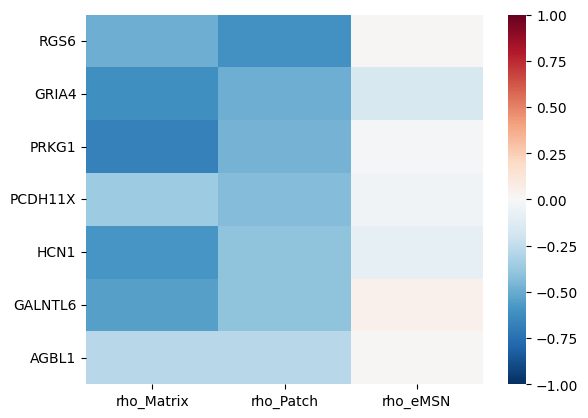

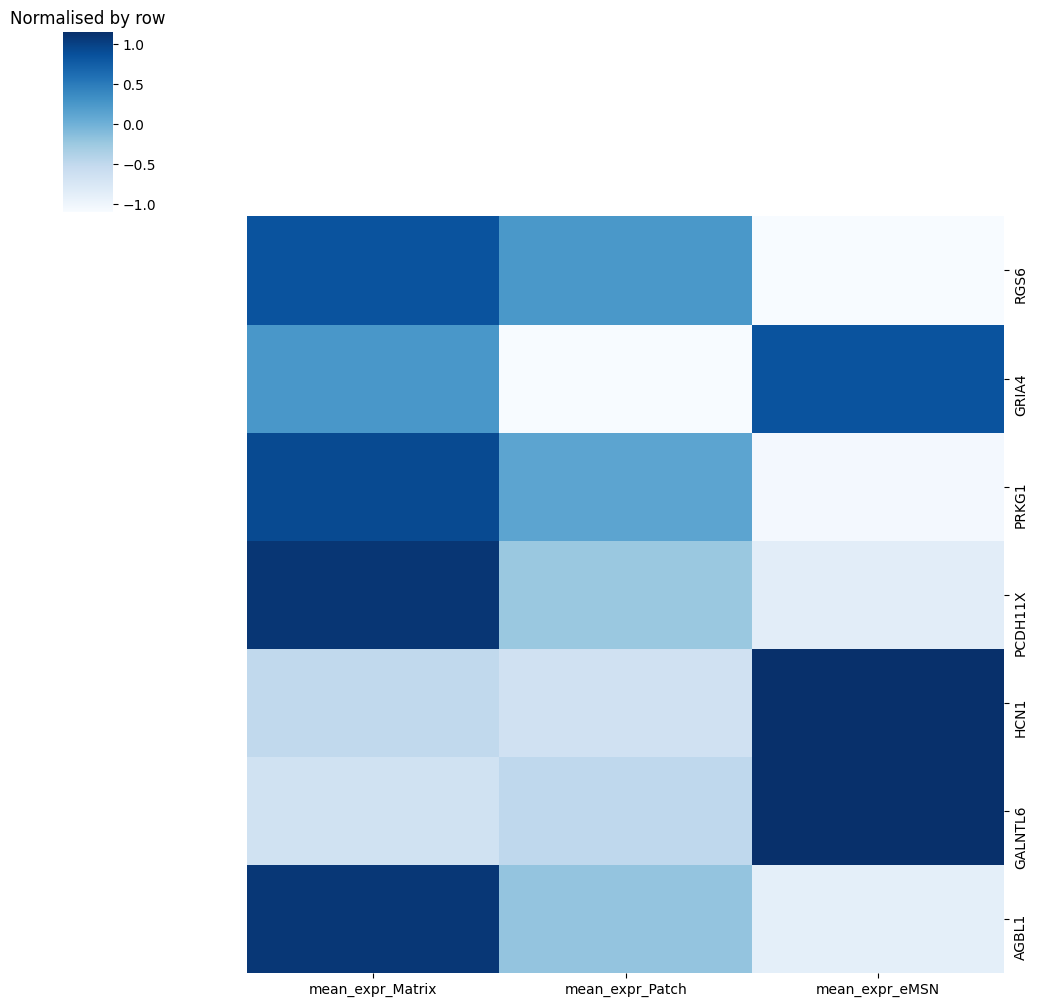

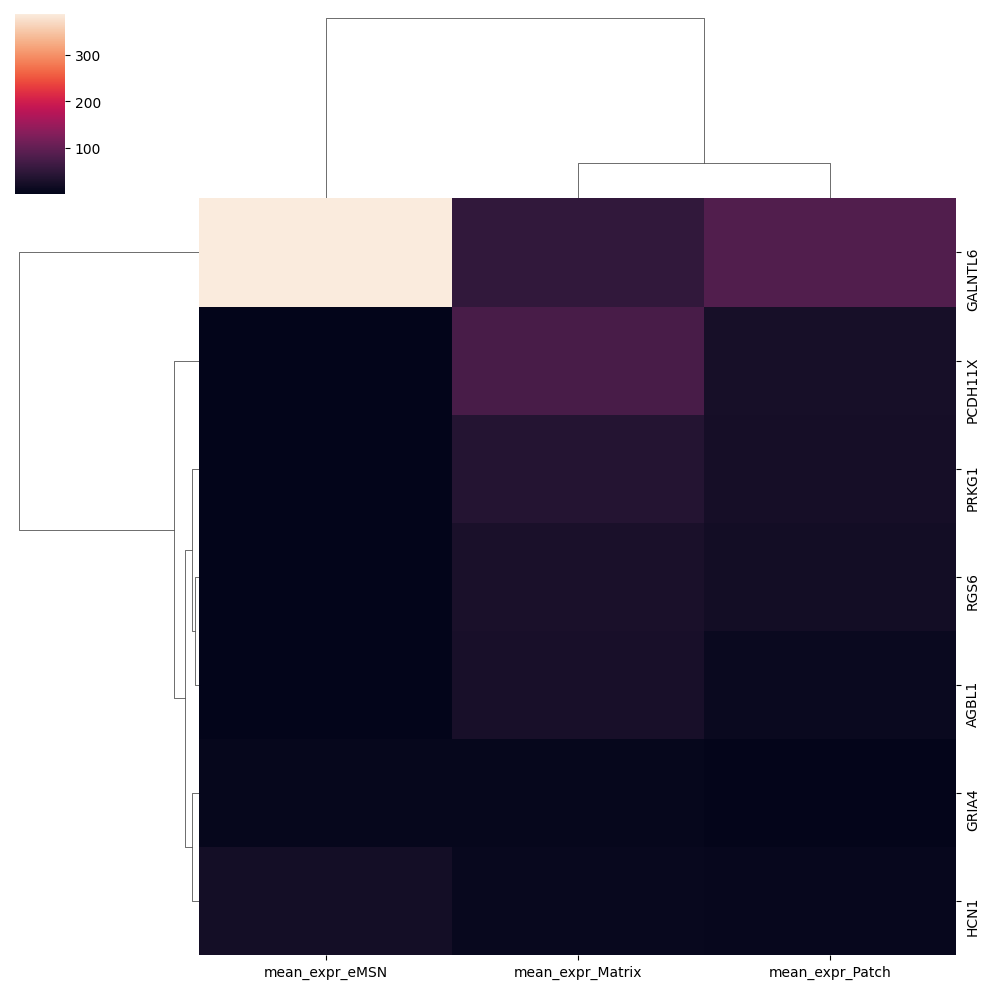

In [72]:
df_protection = df_corr[
    (df_corr["rho_Matrix"] <= -MIN_CORR) & (df_corr["rho_Patch"] <= - MIN_CORR) & # corr big enough in matrix and patch
    (df_corr["rho_eMSN"].abs() <= MIN_CORR) & # no correlation in d1d2
    (df_corr["log2fc_Matrix"].abs() >= MIN_LOGFC) & (df_corr["log2fc_Patch"].abs() >= MIN_LOGFC) & # logfc big enough
    ((df_corr["padj_Matrix"] < 0.05) & (df_corr["padj_Patch"] < 0.05)) & # significant in at least one cell type
    (df_corr["pct_expr_Matrix"] >= MIN_PCT_EXPR) & (df_corr["pct_expr_Patch"] >= MIN_PCT_EXPR) &# sufficient expression in both cell types
    (df_corr["mean_expr_Matrix"] >= MIN_MEAN_EXPR) & (df_corr["mean_expr_Patch"] >= MIN_MEAN_EXPR) # sufficient mean expression in both cell types
].copy()

df_protection = df_protection[["rho_Matrix", "log2fc_Matrix", "pct_expr_Matrix", "mean_expr_Matrix",
                 "rho_Patch", "log2fc_Patch", "pct_expr_Patch", "mean_expr_Patch",
                 "rho_eMSN", "log2fc_eMSN", "pct_expr_eMSN", "mean_expr_eMSN"]].sort_values("rho_Patch", key=np.abs, ascending=False)
display(df_protection)

sns.heatmap(df_protection[["rho_Matrix", "rho_Patch", "rho_eMSN"]], cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.show()
sns.clustermap(df_protection[["mean_expr_Matrix", "mean_expr_Patch", "mean_expr_eMSN"]], 
               cmap="Blues", 
               z_score=0,          # 0 scales by row, 1 scales by column
               row_cluster=False,  # Disables row shuffling
               col_cluster=False)  # Disables column shuffling
plt.title("Normalised by row")
plt.show()
sns.clustermap(df_protection[["mean_expr_Matrix", "mean_expr_Patch", "mean_expr_eMSN"]])
plt.show()

### 10.5 Risk factors more specific to the focus compartment

Instead of requiring Matrix and Patch equally (which biases toward pan-MSN genes), surfaces
genes selectively patterned in whichever compartment `FOCUS_CT` (set in §1) points to — the
one currently assumed to give way first.

,rho_Matrix,padj_Matrix,rho_Patch,padj_Patch,rho_eMSN,padj_eMSN,pct_expr_Matrix,pct_expr_Patch,pct_expr_eMSN,mean_expr_Matrix,mean_expr_Patch,mean_expr_eMSN,log2fc_Matrix,log2fc_Patch,log2fc_eMSN,focus_dominance
LINC02822,0.404716,1.821935e-34,-0.005880,7.052739e-01,0.006900,9.072834e-01,0.541971,0.129625,0.046459,18.933094,0.316791,0.056131,0.874263,-0.003688,-0.000226,0.398836
KCND2,0.541550,9.186643e-102,0.220579,9.958513e-18,0.047318,3.243353e-01,0.998276,0.998953,0.996718,176.574416,154.041075,71.135751,0.638974,0.222034,0.047750,0.320970
STXBP6,0.559519,2.149171e-66,0.257532,2.067650e-21,0.140967,8.812424e-04,0.655121,0.323598,0.627461,8.092487,2.237782,4.777375,0.668741,0.197110,0.107643,0.301986
SLC24A2,0.621282,5.765366e-47,0.328885,1.139070e-06,-0.025991,5.863845e-01,0.994119,0.998487,0.598964,90.518124,86.800791,3.183592,0.927215,0.376654,-0.030497,0.292397
STXBP5L,0.400622,9.228719e-42,0.108817,6.846543e-05,0.190028,2.293366e-05,0.997650,0.999185,0.998791,139.743722,140.975623,141.349568,0.517881,0.113702,0.202174,0.291805
CDH6,0.507168,1.601756e-81,0.230984,1.001950e-27,0.008944,8.783037e-01,0.914282,0.928904,0.043178,14.547215,10.815627,0.049050,0.639028,0.250599,-0.000653,0.276185
LINC01378,0.305053,3.911299e-57,-0.035810,1.161396e-01,-0.003356,9.852482e-01,0.646889,0.554980,0.033333,15.392941,7.074878,0.035060,0.582066,-0.038614,0.002095,0.269243
ADAM12,0.431486,1.463635e-55,0.164885,5.022810e-22,0.001395,1.000000e+00,0.933972,0.694147,0.726079,17.164741,3.936816,3.568566,0.563214,0.151073,-0.013303,0.266602
DLC1,0.498202,1.273124e-56,0.244369,5.725692e-47,0.081185,2.278318e-03,0.989826,0.995636,0.945423,40.753781,45.404410,12.194128,0.605964,0.232870,0.096418,0.253833
ERBB4,0.425557,8.818890e-60,0.174759,1.328925e-23,0.113193,3.202767e-05,0.986264,0.989469,0.999655,84.922419,103.129742,268.410881,0.734740,0.243598,0.106000,0.250797


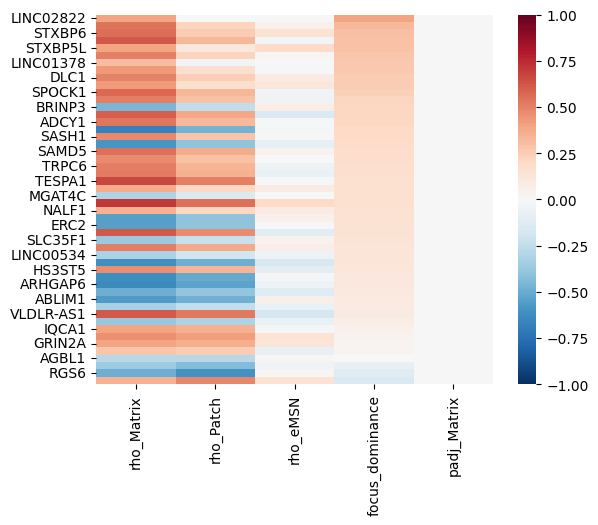

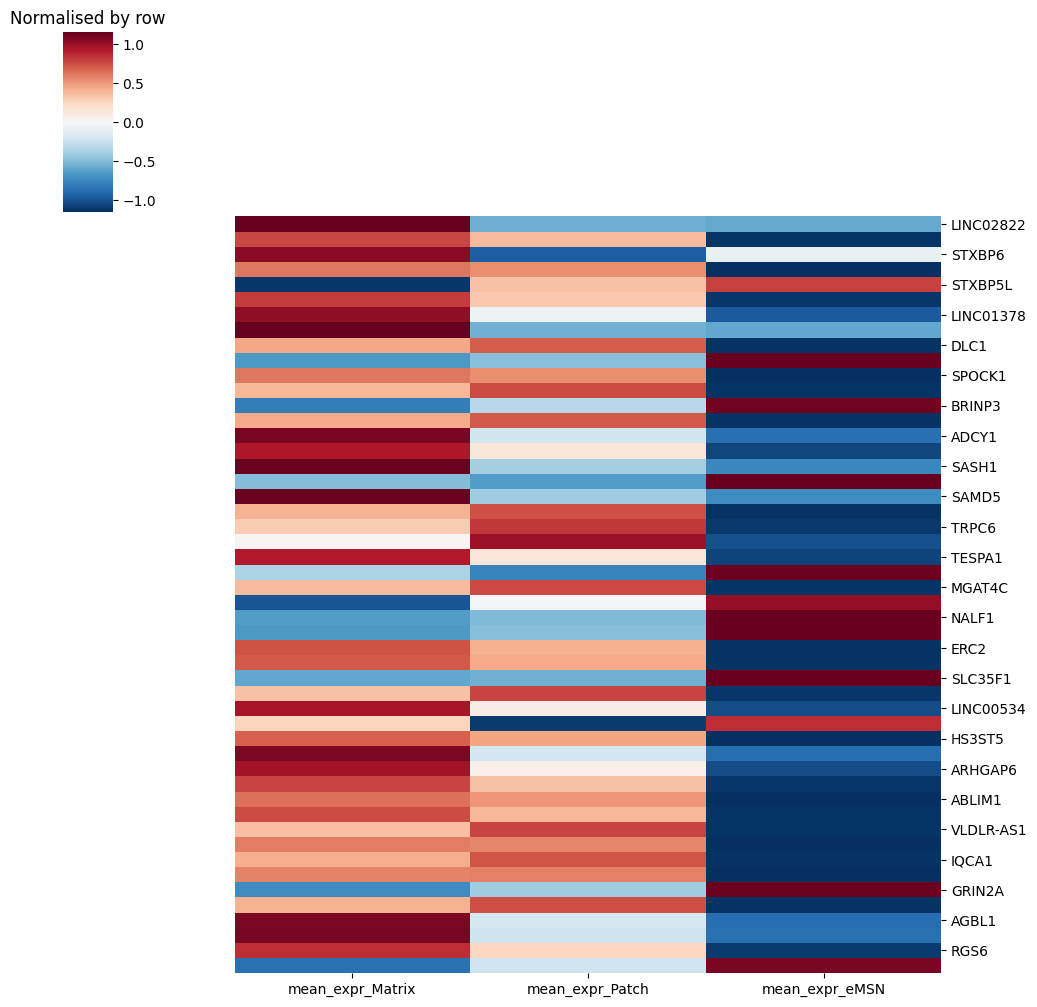

In [40]:
MIN_CORR, MIN_LOGFC, MIN_PCT, MIN_MEAN = 0.2, 0.5, 0.2, 0.1

df_focus_selective_risk = df_corr[
    (df_corr[f"rho_{FOCUS_CT}"].abs()      >= MIN_CORR) &   # spatial patterning in the focus compartment (first hit)
    (df_corr[f"log2fc_{FOCUS_CT}"].abs()   >= MIN_LOGFC) &
    (df_corr["rho_eMSN"].abs()             <= MIN_CORR) &   # eMSN flat = assumed less-affected control
    (df_corr[f"pct_expr_{FOCUS_CT}"]       >= MIN_PCT) &
    (df_corr[f"mean_expr_{FOCUS_CT}"]      >= MIN_MEAN)
].copy()

# focus-dominant genes: patterned in the compartment that degenerates early, less so in the other one.
# "strongly graded in FOCUS_CT, weakly graded in OTHER_CT" — a FOCUS_CT-preferential gene.
df_focus_selective_risk["focus_dominance"] = df_focus_selective_risk[f"rho_{FOCUS_CT}"].abs() - df_focus_selective_risk[f"rho_{OTHER_CT}"].abs()
df_focus_selective_risk = df_focus_selective_risk.sort_values("focus_dominance", ascending=False)
display(df_focus_selective_risk)

sns.heatmap(df_focus_selective_risk[["rho_Matrix", "rho_Patch", "rho_eMSN", "focus_dominance", f"padj_{FOCUS_CT}"]], cmap="RdBu_r", center=0, vmin=-1, vmax=1); plt.show()
df_focus_selective_risk.sort_values("focus_dominance", ascending=False)

sns.clustermap(df_focus_selective_risk[["mean_expr_Matrix", "mean_expr_Patch", "mean_expr_eMSN"]], 
               cmap="RdBu_r", 
               z_score=0,          # 0 scales by row, 1 scales by column
               row_cluster=False,  # Disables row shuffling
               col_cluster=False)  # Disables column shuffling
plt.title("Normalised by row")
plt.show()

### 10.6 Interactive 3D explorer + gene spot-check

In [ ]:
%matplotlib widget

genes = df_corr_sig.index.tolist()
df_plot = df_corr.loc[genes].reset_index().rename(columns={"index": "gene"})

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
sc_pts = ax.scatter(df_plot[f"rho_{FOCUS_CT}"], df_plot[f"rho_{OTHER_CT}"], df_plot["rho_eMSN"],
                 c=df_plot[f"log2fc_{FOCUS_CT}"], cmap="bwr", s=10, picker=True, pickradius=5)
ax.set_xlabel(f"rho_{FOCUS_CT}"); ax.set_ylabel(f"rho_{OTHER_CT}"); ax.set_zlabel("rho_eMSN_D1D2")
fig.colorbar(sc_pts, shrink=0.6, label=f"log2fc_{FOCUS_CT}")

label = ax.text2D(0.02, 0.98, "", transform=ax.transAxes, va="top")

def on_pick(event):
    label.set_text(df_plot["gene"].iloc[event.ind[0]])
    fig.canvas.draw_idle()

fig.canvas.mpl_connect("pick_event", on_pick)
plt.show()

## 11. XDP vs healthy (MATCHED) comparison

In [27]:
# merge range-matched healthy and XDP correlation tables
df_corr_merged = df_corr_matched.merge(df_corr_xdp, left_index=True, right_index=True, suffixes=("", "_xdp"))
df_corr_merged
df_corr_merged[df_corr_merged.index.isin(["ZNF385B", "MSH3", "ZNF91", "PMS2", "OGT", "TAF1", "ZNF98", "PPP1R1B"])][["rho_Matrix", "rho_Patch", "rho_eMSN", "rho_Matrix_xdp", "rho_Patch_xdp", "rho_eMSN_xdp"]]

,rho_Matrix,rho_Patch,rho_eMSN,rho_Matrix_xdp,rho_Patch_xdp,rho_eMSN_xdp
MSH3,0.094942,0.037454,-0.071705,0.100363,0.053396,-0.048229
OGT,0.161372,0.079934,-0.071795,0.234919,-0.014359,-0.207005
PMS2,-0.058679,-0.034476,-0.030350,-0.020945,-0.007893,-0.082856
PPP1R1B,0.001385,0.096154,0.134589,-0.009925,-0.033864,-0.251262
TAF1,0.043392,0.017293,-0.023187,0.059100,0.099357,0.113832
ZNF385B,0.614994,0.508304,0.471419,0.528753,0.262442,0.533053
ZNF91,0.102254,0.002997,-0.101489,0.146763,0.074217,0.141890
ZNF98,-0.027917,-0.041628,-0.024994,0.007658,0.004841,-0.009833


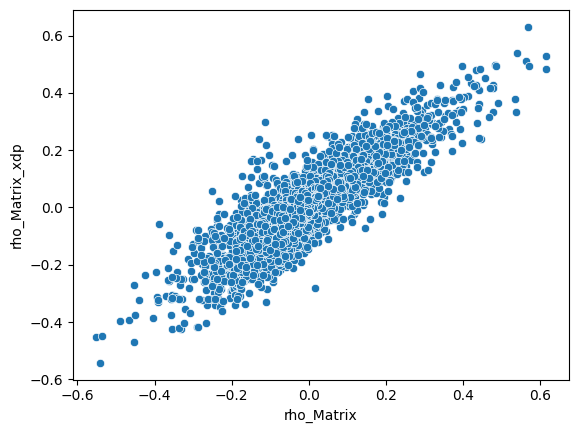

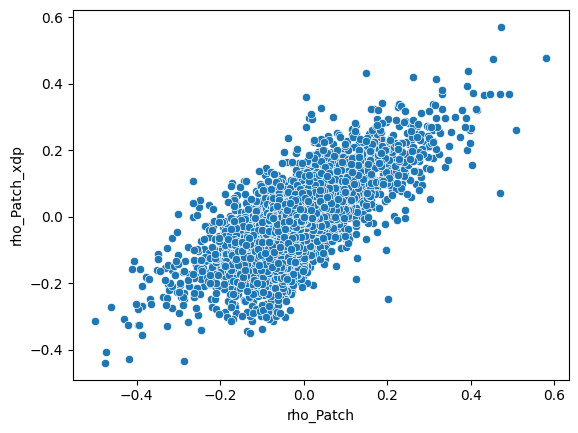

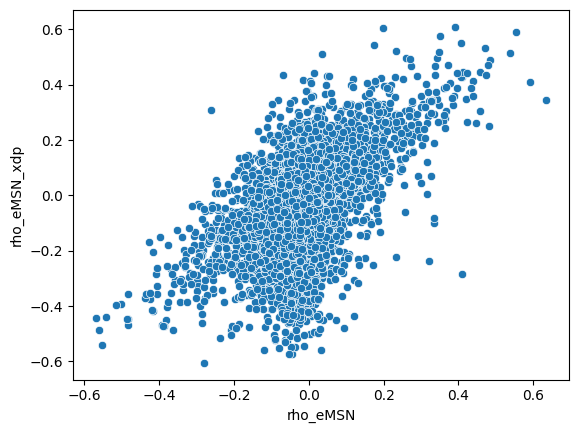

In [54]:
%matplotlib inline
plt.close("all")
sns.scatterplot(data=df_corr_merged, x="rho_Matrix", y="rho_Matrix_xdp",);plt.show()
sns.scatterplot(data=df_corr_merged, x="rho_Patch", y="rho_Patch_xdp",);plt.show()
sns.scatterplot(data=df_corr_merged, x="rho_eMSN", y="rho_eMSN_xdp", );plt.show()

### 11.1 Compartment-by-compartment: health vs XDP agreement

Same classification machinery as §10.1, now comparing health vs XDP for a fixed cell type instead
of two cell types within one condition. Genes that disagree or appear in only one condition are
collected into `INTERESTING_GENES` for the rest of this section.

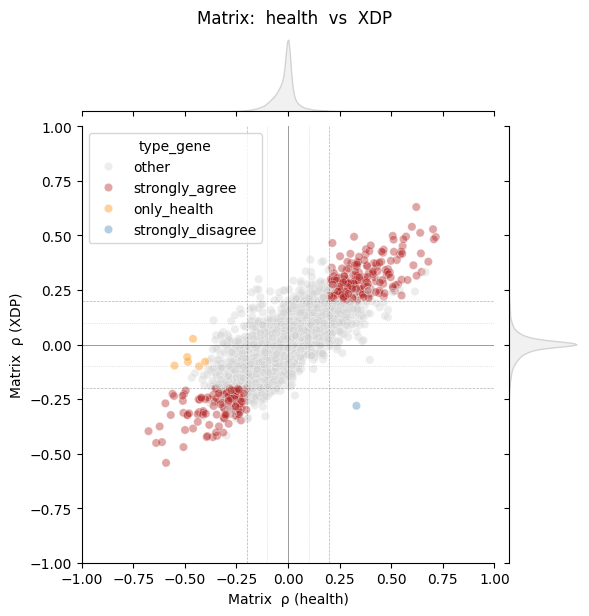

type_gene
other                23285
strongly_agree         339
only_health              6
strongly_disagree        1
Name: Matrix:  health  vs  XDP, dtype: int64

strongly_disagree


,rho_health,rho_XDP,padj_health,padj_XDP,pct_expr_health,pct_expr_XDP,mean_expr_health,mean_expr_XDP,type_gene
PDE8B,0.331277,-0.28057,3.973275e-16,0.000085,0.952942,0.882786,13.855012,6.554658,strongly_disagree


only_health


,rho_health,rho_XDP,padj_health,padj_XDP,pct_expr_health,pct_expr_XDP,mean_expr_health,mean_expr_XDP,type_gene
GALNTL6,-0.550037,-0.096591,2.189940e-116,0.066066,0.949097,0.990417,50.577581,41.100089,only_health
ZNF83,-0.488515,-0.057127,1.160328e-113,0.642863,0.960901,0.916327,12.719864,6.925466,only_health
RGS6,-0.485113,-0.079266,8.144879e-44,0.375846,0.935006,0.966637,26.549806,18.526619,only_health
BRINP3,-0.460466,0.026483,5.124288e-45,0.706550,0.586209,0.736025,7.271915,4.543478,only_health
KIAA2012,-0.430850,-0.099854,4.452469e-107,0.000409,0.490129,0.557143,1.488990,1.230701,only_health
TMEFF2,-0.402428,-0.078873,4.214648e-83,0.012590,0.910417,0.924401,9.361687,7.863798,only_health


only_XDP


,rho_health,rho_XDP,padj_health,padj_XDP,pct_expr_health,pct_expr_XDP,mean_expr_health,mean_expr_XDP,type_gene


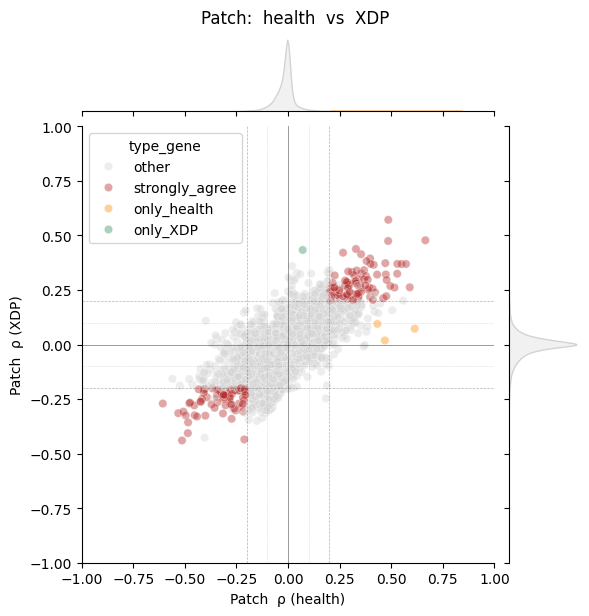

type_gene
other             23464
strongly_agree      163
only_health           3
only_XDP              1
Name: Patch:  health  vs  XDP, dtype: int64

strongly_disagree


,rho_health,rho_XDP,padj_health,padj_XDP,pct_expr_health,pct_expr_XDP,mean_expr_health,mean_expr_XDP,type_gene


only_health


,rho_health,rho_XDP,padj_health,padj_XDP,pct_expr_health,pct_expr_XDP,mean_expr_health,mean_expr_XDP,type_gene
OPCML,0.613389,0.072686,1.091189e-109,0.705938,0.976495,0.948256,92.277985,36.484848,only_health
PDE8B,0.468978,0.018991,2.192798e-39,0.861026,0.900628,0.789880,9.551315,4.120640,only_health
ELL2,0.432810,0.094728,5.036278e-44,0.693949,0.694671,0.583762,4.250931,2.821898,only_health


only_XDP


,rho_health,rho_XDP,padj_health,padj_XDP,pct_expr_health,pct_expr_XDP,mean_expr_health,mean_expr_XDP,type_gene
LSAMP,0.070997,0.433568,0.00098,2.772388e-11,0.999942,0.997999,290.528625,134.369926,only_XDP


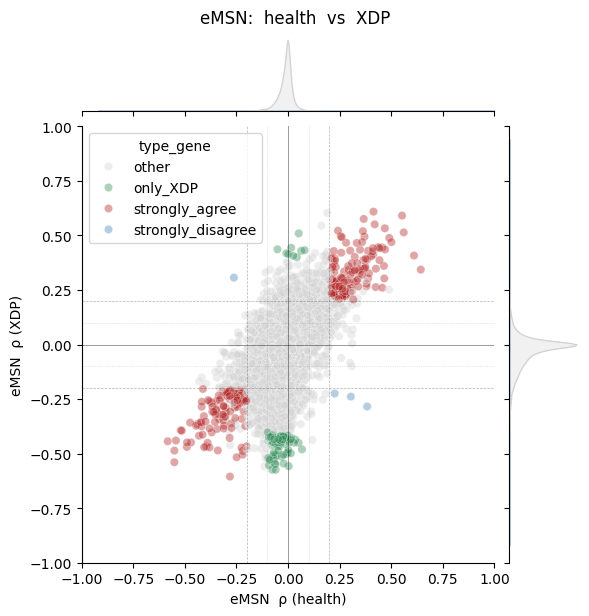

type_gene
other                23319
strongly_agree         231
only_XDP                77
strongly_disagree        4
Name: eMSN:  health  vs  XDP, dtype: int64

strongly_disagree


,rho_health,rho_XDP,padj_health,padj_XDP,pct_expr_health,pct_expr_XDP,mean_expr_health,mean_expr_XDP,type_gene
MALAT1,0.383274,-0.283954,5.062829e-19,5.742769e-22,1.000000,1.000000,2919.851986,1505.945903,strongly_disagree
CAMK2N1,0.304044,-0.238490,2.975692e-18,2.517183e-06,0.942142,0.885504,10.052504,4.553046,strongly_disagree
RBFOX1,-0.262305,0.306860,3.463875e-11,2.113247e-08,1.000000,0.998950,657.303972,331.587185,strongly_disagree
MIR124-1HG,0.225627,-0.224500,1.004190e-10,1.457513e-21,0.989292,0.965861,16.748359,10.833508,strongly_disagree


only_health


,rho_health,rho_XDP,padj_health,padj_XDP,pct_expr_health,pct_expr_XDP,mean_expr_health,mean_expr_XDP,type_gene


only_XDP


,rho_health,rho_XDP,padj_health,padj_XDP,pct_expr_health,pct_expr_XDP,mean_expr_health,mean_expr_XDP,type_gene
VAMP2,-0.060099,-0.574136,0.236580,9.714866e-26,0.881520,0.815126,5.551468,4.207458,only_XDP
HSP90AB1,-0.076470,-0.573995,0.148060,8.198831e-20,0.910017,0.837710,6.934024,5.766282,only_XDP
CALM1,0.003078,-0.557141,1.000000,1.392426e-20,0.988946,0.964811,27.095682,17.075105,only_XDP
RPL10,-0.092375,-0.552886,0.023662,6.728868e-78,0.722971,0.688550,2.264076,2.270483,only_XDP
NORAD,-0.061250,-0.548926,0.239104,3.611383e-28,0.866149,0.790441,5.781693,4.217437,only_XDP
...,...,...,...,...,...,...,...,...,...
PJA2,-0.022710,-0.407499,0.724846,1.680385e-19,0.984629,0.936450,13.981174,7.870273,only_XDP
SNHG14,0.025216,0.406990,0.512075,4.852344e-05,1.000000,1.000000,313.141278,167.660189,only_XDP
RSRP1,-0.097966,-0.402528,0.000211,1.516041e-32,0.967185,0.922794,8.329361,5.731618,only_XDP
ARF5,-0.036029,-0.400915,0.398617,1.661063e-35,0.578584,0.525210,1.226943,0.990546,only_XDP


,rho_Matrix,padj_Matrix,rho_Patch,padj_Patch,rho_eMSN,padj_eMSN,pct_expr_Matrix,pct_expr_Patch,pct_expr_eMSN,mean_expr_Matrix,...,padj_eMSN_xdp,pct_expr_Matrix_xdp,pct_expr_Patch_xdp,pct_expr_eMSN_xdp,mean_expr_Matrix_xdp,mean_expr_Patch_xdp,mean_expr_eMSN_xdp,log2fc_Matrix_xdp,log2fc_Patch_xdp,log2fc_eMSN_xdp
PDE8B,0.016944,7.558273e-01,0.242125,3.031630e-12,0.341310,7.086127e-46,0.936700,0.877030,0.996439,11.153317,...,7.814185e-11,0.882786,0.789880,0.982143,6.554658,4.120640,22.359244,-0.396997,-0.007234,0.418290
TMEFF2,-0.288102,1.034393e-39,-0.301986,1.951728e-58,-0.191472,4.966241e-25,0.936577,0.940584,0.986548,11.170316,...,8.980973e-01,0.924401,0.926244,0.971113,7.863798,9.072327,13.735819,-0.096286,-0.000472,0.036407
GALNTL6,-0.362522,2.103526e-32,-0.265767,1.644124e-20,0.043046,5.873352e-01,0.979252,0.997189,0.999802,62.591707,...,3.554923e-11,0.990417,0.993997,0.997374,41.100089,57.627501,165.922269,-0.125427,0.134014,0.370164
ZNF91,0.102254,2.154869e-10,0.002997,9.750145e-01,-0.101489,1.592276e-06,0.996527,0.997502,0.983778,20.284033,...,1.003232e-02,0.985537,0.987993,0.962710,11.077995,12.441681,6.846113,0.135759,0.056607,0.145804
OGT,0.161372,6.968703e-06,0.079934,3.986198e-03,-0.071795,1.214357e-04,0.985495,0.985400,0.957864,14.361533,...,5.241435e-14,0.979237,0.984848,0.913866,10.668146,11.980846,5.257353,0.233968,-0.014485,-0.243200
KIAA2012,-0.269802,1.464566e-31,-0.166788,8.143660e-11,-0.304427,5.059865e-44,0.617703,0.784275,0.667062,1.972428,...,1.326980e-01,0.557143,0.691538,0.626050,1.230701,2.031447,1.437500,-0.067489,0.045248,-0.071576
RGS6,-0.293595,4.581234e-24,-0.460324,6.247458e-43,0.015192,6.383925e-01,0.970683,0.903966,0.106429,31.488211,...,1.027350e-01,0.966637,0.890509,0.017332,18.526619,13.018868,0.033088,-0.108736,-0.456030,0.017723
LSAMP,0.043516,2.528095e-01,0.148730,8.884319e-06,-0.352434,3.989096e-82,0.999495,1.000000,0.999802,169.573024,...,1.396304e-03,0.998137,0.997999,0.996849,80.645963,134.369926,126.675945,0.288106,0.443221,-0.140766
OPCML,0.532773,2.387201e-52,0.469778,9.703895e-56,0.412055,6.118165e-31,0.922623,0.969394,0.999604,73.367485,...,2.208023e-06,0.901863,0.948256,0.996849,30.425022,36.484848,96.664391,0.859506,0.169742,0.537268
GRIN2A,0.145573,1.353224e-04,0.223815,2.070411e-14,0.132639,5.541268e-08,0.709372,0.930668,0.997428,11.442047,...,4.583557e-34,0.748536,0.886221,0.982668,6.727152,11.571184,28.762080,-0.112566,-0.015745,0.315051


In [28]:
THRESHOLD          = 0.2    # minimum |rho| to count as "has gradient"
THRESHOLD_SPECIFIC = 0.4    # minimum |rho| to count as "condition-specific"
THRESHOLD_ONLY     = 0.1    # maximum |rho| to count as "truly absent"
PADJ_THR           = 0.05
MIN_PCT_EXPR       = 0.20
MIN_MEAN_EXPR      = 0.10   # require mean expression above this to trust a gene's correlation

INTERESTING_GENES = set(["PDE8B", "OGT", "ZNF91", "ZNF83", "RGS6", "BRINP3", "GALNTL6", "ELL2", "OPCML", "LSAMP", "GRIN2A", "UNC80", "TRPC6", "HCN1"])

common_genes = df_corr.index.intersection(df_corr_xdp.index)

for ct in ["Matrix", "Patch", "eMSN"]:

    df_ct = pd.DataFrame({
        "rho_health":   df_corr.loc[common_genes,     f"rho_{ct}"],
        "rho_XDP":      df_corr_xdp.loc[common_genes, f"rho_{ct}"],
        "padj_health":  df_corr.loc[common_genes,     f"padj_{ct}"],
        "padj_XDP":     df_corr_xdp.loc[common_genes, f"padj_{ct}"],
        "pct_expr_health": df_corr.loc[common_genes,     f"pct_expr_{ct}"],
        "pct_expr_XDP":    df_corr_xdp.loc[common_genes, f"pct_expr_{ct}"],
        "mean_expr_health": df_corr.loc[common_genes,     f"mean_expr_{ct}"],
        "mean_expr_XDP":    df_corr_xdp.loc[common_genes, f"mean_expr_{ct}"],
    })

    df_ct = classify_gradient_agreement(
        df_ct,
        rho_x="rho_health", rho_y="rho_XDP",
        padj_x="padj_health", padj_y="padj_XDP",
        pexpr_x="pct_expr_health", pexpr_y="pct_expr_XDP",
        mexpr_x="mean_expr_health", mexpr_y="mean_expr_XDP",
        threshold=THRESHOLD, threshold_specific=THRESHOLD_SPECIFIC, threshold_only=THRESHOLD_ONLY,
        padj_thr=PADJ_THR, min_pct_expr=MIN_PCT_EXPR, min_mean_expr=MIN_MEAN_EXPR,
        label_x="health", label_y="XDP",
    )

    # add to interesting genes
    if ct != "eMSN":
        INTERESTING_GENES.update(df_ct.loc[df_ct["type_gene"] == "strongly_disagree"].index.tolist())
        INTERESTING_GENES.update(df_ct.loc[df_ct["type_gene"] == "only_health"].index.tolist())
        INTERESTING_GENES.update(df_ct.loc[df_ct["type_gene"] == "only_XDP"].index.tolist())

    plot_gradient_agreement(
        df_ct, rho_x="rho_health", rho_y="rho_XDP",
        threshold=THRESHOLD, threshold_only=THRESHOLD_ONLY,
        label_x="health", label_y="XDP",
        xlabel=f"{ct}  ρ (health)", ylabel=f"{ct}  ρ (XDP)",
        title=f"{ct}:  health  vs  XDP",
    )

df_corr_merged.loc[list(INTERESTING_GENES)]

### 11.2 Gradient-shift dot plot for genes of interest (observed rho)

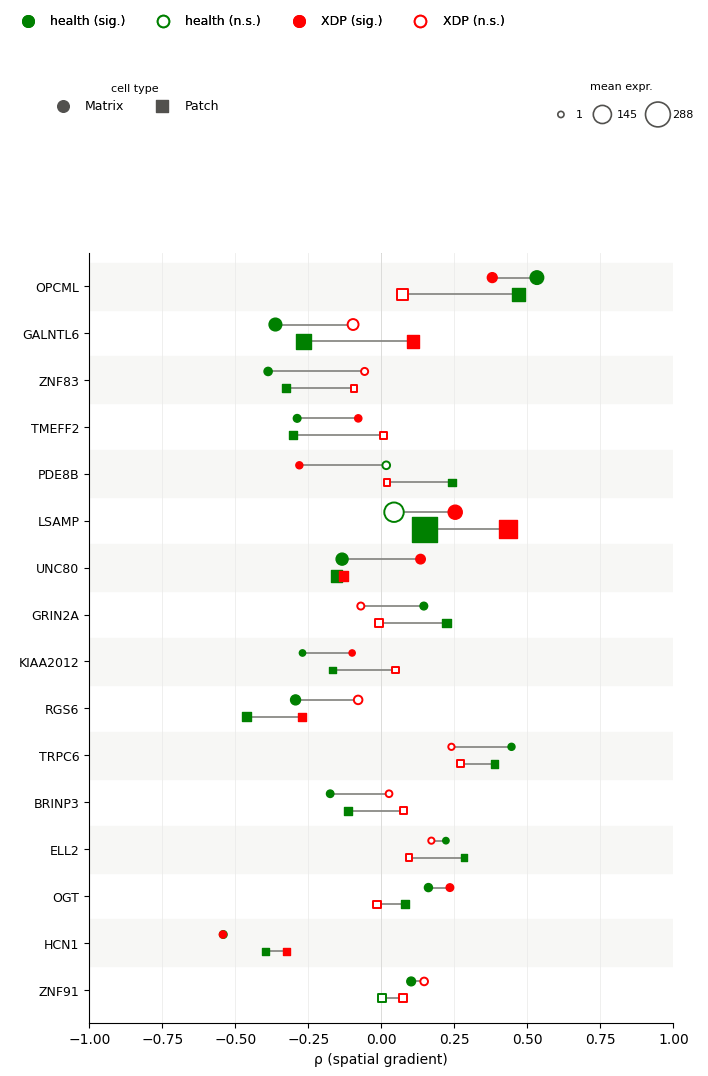

In [29]:
plot_gene_gradient_shift_combined(df_corr_merged, list(INTERESTING_GENES), padj_thr=PADJ_THR)

### 11.3 Empirical null via donor-level permutation

Observed rho for `INTERESTING_GENES` can be noisy with few donors — build an empirical null by
permuting `r` within each donor.

In [85]:
N_PERM = 4000
df_list = []
for ct in ["Matrix", "Patch"]:
    df_perm_xdp = permutation_test_donor_level(xdp_adata_sub, list(INTERESTING_GENES), ct=ct, n_perm=N_PERM)
    df_perm_xdp.columns = [f"{col}_xdp" for col in df_perm_xdp.columns] # attach "xdp" at the end of each column name
    df_list.append(df_perm_xdp)
    df_perm_matched = permutation_test_donor_level(adata_matched, list(INTERESTING_GENES), ct=ct, n_perm=N_PERM)
    df_perm_matched.columns = [f"{col}_matched" for col in df_perm_matched.columns] # attach "matched" at the end of each column name
    df_list.append(df_perm_matched)
df_perm_combined = pd.concat(df_list, axis=1)
df_perm_combined



Min p-value testable: 0.00025
Min p-value testable: 0.00025
Min p-value testable: 0.00025
Min p-value testable: 0.00025


,z_obs_Matrix_xdp,rho_Matrix_xdp,ci_lo_Matrix_xdp,ci_hi_Matrix_xdp,pval_Matrix_xdp,padj_Matrix_xdp,z_obs_Matrix_matched,rho_Matrix_matched,ci_lo_Matrix_matched,ci_hi_Matrix_matched,...,ci_lo_Patch_xdp,ci_hi_Patch_xdp,pval_Patch_xdp,padj_Patch_xdp,z_obs_Patch_matched,rho_Patch_matched,ci_lo_Patch_matched,ci_hi_Patch_matched,pval_Patch_matched,padj_Patch_matched
PDE8B,-0.288301,-0.280570,-0.393022,-0.159850,0.00025,0.004,0.062476,0.062395,-0.010166,0.134302,...,-0.059442,0.097192,0.28250,1.000,0.234201,0.230011,0.167147,0.291011,0.00025,0.004
TMEFF2,-0.079037,-0.078873,-0.129919,-0.027409,0.00025,0.004,-0.323178,-0.312378,-0.352599,-0.271005,...,-0.079708,0.093809,0.67450,1.000,-0.300755,-0.292004,-0.323994,-0.259347,0.00025,0.004
GALNTL6,-0.096893,-0.096591,-0.176928,-0.014976,0.00025,0.004,-0.425357,-0.401434,-0.447437,-0.353312,...,0.031322,0.185089,0.00025,0.004,-0.260077,-0.254368,-0.306712,-0.200490,0.00025,0.004
ZNF91,0.147831,0.146763,0.022553,0.266511,0.00025,0.004,0.107204,0.106795,0.073424,0.139928,...,-0.046894,0.193179,0.00025,0.004,0.005185,0.005185,-0.037163,0.047514,0.55275,1.000
OGT,0.239389,0.234919,0.160877,0.306330,0.00025,0.004,0.149422,0.148320,0.083374,0.212011,...,-0.092329,0.063786,0.41100,1.000,0.083337,0.083145,0.035236,0.130672,0.00025,0.004
KIAA2012,-0.100188,-0.099854,-0.147603,-0.051641,0.00025,0.004,-0.306917,-0.297630,-0.338308,-0.255843,...,-0.021107,0.118948,0.00400,0.064,-0.166475,-0.164954,-0.210177,-0.119027,0.00025,0.004
RGS6,-0.079432,-0.079266,-0.198280,0.042052,0.00025,0.004,-0.342622,-0.329816,-0.380461,-0.277199,...,-0.380201,-0.153021,0.00025,0.004,-0.483278,-0.448865,-0.500768,-0.393746,0.00025,0.004
LSAMP,0.258636,0.253019,0.175230,0.327669,0.00025,0.004,0.015655,0.015654,-0.045026,0.076218,...,0.327009,0.529240,0.00025,0.004,0.151301,0.150157,0.090249,0.208983,0.00025,0.004
OPCML,0.399964,0.379919,0.149828,0.570972,0.00025,0.004,0.633556,0.560496,0.509073,0.607932,...,-0.106180,0.246996,0.00025,0.004,0.495931,0.458911,0.408393,0.506627,0.00025,0.004
GRIN2A,-0.070265,-0.070149,-0.272685,0.138340,0.00025,0.004,0.192207,0.189874,0.125765,0.252404,...,-0.224653,0.207485,0.59950,1.000,0.219814,0.216341,0.163105,0.268320,0.00025,0.004


In [ ]:
plot_gene_gradient_shift_permutation(df_perm_combined, list(INTERESTING_GENES),
                                      expr_df=df_corr_merged, sort_col=f"rho_{FOCUS_CT}_matched")

df_perm_combined.loc[df_list[0].index.intersection(INTERESTING_GENES)]

### 11.4 Are these genes also DEG in NucSeq?

In [ ]:
# INTERESTING_GENES = [
#     "ADCY5",                                                                    # adenylate cyclase
#     "PRKACA", "PRKACB",                                                         # PKA catalytic subunits
#     "PRKAR1B", "PRKAR2B",                                                       # PKA regulatory subunits
#     "GNAL",                                                                     # Golf (D1/A2A -> adenylate cyclase)
#     "PDE1B", "PDE2A", "PDE4B", "PDE4D", "PDE7B", "PDE8B", "PDE9A", "PDE10A",     # phosphodiesterases
#     "PPP1R1B",                                                                  # DARPP-32
#     "PPP3CA",                                                                   # calcineurin catalytic subunit
#     "ARPP21",
#     "RGS9",
#     "GUCY1A2", "GUCY1B1",                                                       # soluble guanylate cyclase (NO/cGMP arm)
#     "PRKG1",                                                                    # PKG
# ]

In [31]:
deg_baseline = pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/baseline_nebula/{FOCUS_CT}/deg_results.csv")
deg_baseline = deg_baseline[["gene", "logFC_conditionXDP", "p_conditionXDP"]]
deg_baseline["padj_conditionXDP"] = multipletests(deg_baseline["p_conditionXDP"], method="fdr_bh")[1]
deg_baseline["is_significant"] = deg_baseline["padj_conditionXDP"] < 0.05
print("Significant by baseline DEG:", deg_baseline["is_significant"].sum())
display(deg_baseline[(deg_baseline["gene"].isin(INTERESTING_GENES)) & (deg_baseline["is_significant"])].sort_values("logFC_conditionXDP", key=np.abs, ascending=False))

deg_grad= pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/gradient_score_nebula/{FOCUS_CT}/deg_results.csv")
deg_grad = deg_grad[["gene", "logFC_conditionXDP", "p_conditionXDP"]]
deg_grad["padj_conditionXDP"] = multipletests(deg_grad["p_conditionXDP"], method="fdr_bh")[1]
deg_grad["is_significant"] = deg_grad["padj_conditionXDP"] < 0.05
print("Significant by gradient DEG:", deg_grad["is_significant"].sum())
display(deg_grad[(deg_grad["gene"].isin(INTERESTING_GENES)) & (deg_grad["is_significant"])].sort_values("logFC_conditionXDP", key=np.abs, ascending=False))

deg_PCA= pd.read_csv(f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/{FOCUS_CT}/deg_results.csv")
deg_PCA = deg_PCA[["gene", "logFC_conditionXDP", "p_conditionXDP"]]
deg_PCA["padj_conditionXDP"] = multipletests(deg_PCA["p_conditionXDP"], method="fdr_bh")[1]
deg_PCA["is_significant"] = deg_PCA["padj_conditionXDP"] < 0.05
print("Significant by PCA DEG:", deg_PCA["is_significant"].sum())
display(deg_PCA[(deg_PCA["gene"].isin(INTERESTING_GENES)) & (deg_PCA["is_significant"])].sort_values("logFC_conditionXDP", key=np.abs, ascending=False))

Significant by baseline DEG: 3771


,gene,logFC_conditionXDP,p_conditionXDP,padj_conditionXDP,is_significant
11904,TRPC6,-0.943218,5.748707e-08,4.440785e-06,True
5692,HCN1,0.823881,2.050694e-08,1.947433e-06,True
3183,KIAA2012,0.803847,1.924255e-12,1.123168e-09,True
5419,GALNTL6,0.521609,3.901215e-09,5.070117e-07,True
5941,ELL2,-0.517770,1.474986e-06,5.943964e-05,True
12154,OPCML,-0.487265,1.643835e-07,1.032686e-05,True
18638,ZNF83,0.450138,1.062304e-04,1.846952e-03,True
1587,BRINP3,0.387901,2.055853e-03,1.710197e-02,True
3130,TMEFF2,0.332999,2.601971e-04,3.731155e-03,True


Significant by gradient DEG: 113


,gene,logFC_conditionXDP,p_conditionXDP,padj_conditionXDP,is_significant


Significant by PCA DEG: 1039


,gene,logFC_conditionXDP,p_conditionXDP,padj_conditionXDP,is_significant


### 11.5 Does the health→XDP shift survive donor-level and range-matched testing?

Two independent checks that the apparent change is real and not an artifact of pooling cells or
of comparing mismatched tissue ranges.

In [32]:
# donor-level DerSimonian-Laird comparison (adata_matched vs xdp_adata_sub)
for g in list(INTERESTING_GENES)[:]:
    print(f"gene: {g}")
    for ct in ["Matrix", "Patch"]:
        res = compare_health_vs_xdp_donor_level(adata_matched, xdp_adata_sub, ct, g, metric_key="r")
        print(f"  {ct}: rho_health_restricted={res['health_restricted']['z']:.3f} (n={len(res['health_donors_used'])}), "
              f"rho_xdp={res['xdp']['z']:.3f} (n={len(res['xdp_donors_used'])}), p_diff={res['p_diff']:.3e}")
#p_diff -> even after removing the range confound, health and XDP genuinely disagree. That's real evidence of a biological change, not just missing dorsal cells.

gene: PDE8B


NameError: name 'adata_matched' is not defined

In [ ]:
# cell-pooled comparison, health explicitly restricted to the r-range XDP covers
compare_health_vs_xdp(adata, xdp_adata_sub, FOCUS_CT, "PDE8B")

### 11.5b Empirical null for the shift itself (not just for one condition's rho)

The tests above establish that health and XDP rho differ via a **parametric** Fisher-z
difference test, which assumes asymptotic normality and can be unstable with only 4 XDP donors.
Here we build an **empirical** null for the difference directly: permute `r` within donor
independently in both the range-matched health data and XDP, recombine donors into a
DerSimonian-Laird z per condition under each permutation (same machinery as
`permutation_test_donor_level`), and ask how extreme the observed `z_health - z_xdp` is against
that null — rather than trusting the normal approximation.

In [84]:
def empirical_null_health_vs_xdp_diff(adata_health, adata_xdp, genes, ct,
                                       donor_col="donor_id", metric_key="r",
                                       min_cells=20, n_perm=2000, seed=0, layer="log1p_norm"):
    """Empirical null for the health-vs-XDP SHIFT itself (not for one condition's rho alone).
    Permutes r within donor independently in both conditions, recombines donors into a
    DerSimonian-Laird z per condition under each permutation, and computes an empirical
    p-value for the observed (z_health - z_xdp) against that null distribution."""
    rng = np.random.default_rng(seed)

    def _prep(adata):
        adata_ct = adata[adata.obs["ct"] == ct]
        X_full = adata_ct[:, genes].layers[layer]
        X_full = X_full.toarray() if sparse.issparse(X_full) else np.asarray(X_full, dtype=float)
        r_full = adata_ct.obs[metric_key].values.astype(float)
        donors_full = adata_ct.obs[donor_col].values

        donor_data = {}
        for donor in pd.unique(donors_full):
            mask = (donors_full == donor) & ~np.isnan(r_full)
            n = mask.sum()
            if n < min_cells:
                continue
            Xr = rankdata(X_full[mask], axis=0).astype(float)
            Xr -= Xr.mean(axis=0)
            yr0 = rankdata(r_full[mask]).astype(float)          # ranked ONCE - permutations just shuffle this
            yr0 -= yr0.mean()
            donor_data[donor] = dict(Xr=Xr, Xr_ss=(Xr**2).sum(axis=0), yr0=yr0, yr0_ss=(yr0**2).sum(), n=n)
        return donor_data

    def _obs_and_null_z(donor_data, n_genes):
        n_cells  = np.array([d["n"] for d in donor_data.values()], dtype=float)
        n_donors = len(donor_data)

        rho_obs_list = []
        for d in donor_data.values():
            denom = np.sqrt(d["Xr_ss"] * d["yr0_ss"])
            with np.errstate(divide="ignore", invalid="ignore"):
                rho_obs_list.append(np.where(denom == 0, 0.0, (d["Xr"].T @ d["yr0"]) / denom))
        rho_obs_matrix = np.array(rho_obs_list)                  # (n_donors, n_genes)

        # ALL permutations per donor at once - one batched matmul instead of a python loop over n_perm
        rho_null = np.empty((n_donors, n_genes, n_perm))
        for di, d in enumerate(donor_data.values()):
            Y = np.broadcast_to(d["yr0"], (n_perm, d["n"])).copy()
            Y = rng.permuted(Y, axis=1)                          # each of the n_perm rows shuffled independently
            denom = np.sqrt(d["Xr_ss"][:, None] * d["yr0_ss"])
            with np.errstate(divide="ignore", invalid="ignore"):
                rho_null[di] = np.where(denom == 0, 0.0, (d["Xr"].T @ Y.T) / denom)

        def combined_z(rho_matrix, has_perm_axis):
            z = np.arctanh(np.clip(rho_matrix, -0.9999, 0.9999))
            w_fixed = np.clip(n_cells - 3, 1e-6, None)
            w_b = w_fixed.reshape(-1, 1, 1) if has_perm_axis else w_fixed.reshape(-1, 1)
            z_fixed = (w_b * z).sum(axis=0) / w_fixed.sum()
            Q = (w_b * (z - z_fixed) ** 2).sum(axis=0)
            c = w_fixed.sum() - (w_fixed**2).sum() / w_fixed.sum()
            tau2 = np.clip((Q - (n_donors - 1)) / c, 0, None) if n_donors > 1 else np.zeros_like(Q)
            w_re = 1.0 / (1.0 / w_b + tau2[None, ...])
            return (w_re * z).sum(axis=0) / w_re.sum(axis=0)

        z_obs  = combined_z(rho_obs_matrix, has_perm_axis=False)   # (n_genes,)
        z_null = combined_z(rho_null, has_perm_axis=True)          # (n_genes, n_perm)
        return z_obs, z_null

    genes = list(genes)
    n_genes = len(genes)

    z_obs_health, z_null_health = _obs_and_null_z(_prep(adata_health), n_genes)
    z_obs_xdp,    z_null_xdp    = _obs_and_null_z(_prep(adata_xdp), n_genes)

    diff_obs  = z_obs_health - z_obs_xdp                  # (n_genes,)
    diff_null = z_null_health - z_null_xdp                # (n_genes, n_perm) - independent permutations per condition

    pval_emp  = np.maximum((np.abs(diff_null) >= np.abs(diff_obs)[:, None]).mean(axis=1), 1.0 / n_perm)
    pval_bonf = np.minimum(pval_emp * n_genes, 1.0)

    return pd.DataFrame({
        f"rho_health_{ct}": np.tanh(z_obs_health),
        f"rho_xdp_{ct}":    np.tanh(z_obs_xdp),
        f"diff_z_{ct}":     diff_obs,
        f"pval_emp_{ct}":   pval_emp,
        f"padj_emp_{ct}":   pval_bonf,
    }, index=genes)


N_PERM_DIFF = 4000
df_diff_list = []
for ct in ["Matrix", "Patch"]:
    df_diff_list.append(
        empirical_null_health_vs_xdp_diff(adata_matched, xdp_adata_sub, list(INTERESTING_GENES), ct=ct, n_perm=N_PERM_DIFF)
    )
df_diff_combined = pd.concat(df_diff_list, axis=1)

print("Empirical (permutation-based) null for the health-vs-XDP SHIFT itself - "
      "compare padj_emp here to the parametric p_diff printed above.")
padj_cols = [c for c in df_diff_combined.columns if c.startswith("padj_emp")]
display(df_diff_combined.sort_values(padj_cols[0]))

Empirical (permutation-based) null for the health-vs-XDP SHIFT itself - compare padj_emp here to the parametric p_diff printed above.


,rho_health_Matrix,rho_xdp_Matrix,diff_z_Matrix,pval_emp_Matrix,padj_emp_Matrix,rho_health_Patch,rho_xdp_Patch,diff_z_Patch,pval_emp_Patch,padj_emp_Patch
PDE8B,0.062395,-0.280570,0.350777,0.00025,0.004,0.230011,0.018991,0.215207,0.00025,0.004
TMEFF2,-0.312378,-0.078873,-0.244141,0.00025,0.004,-0.292004,0.007104,-0.307859,0.00025,0.004
GALNTL6,-0.401434,-0.096591,-0.328464,0.00025,0.004,-0.254368,0.108857,-0.369367,0.00025,0.004
ZNF91,0.106795,0.146763,-0.040626,0.00025,0.004,0.005185,0.074217,-0.069169,0.00100,0.016
OGT,0.148320,0.234919,-0.089967,0.00025,0.004,0.083145,-0.014359,0.097697,0.00025,0.004
KIAA2012,-0.297630,-0.099854,-0.206729,0.00025,0.004,-0.164954,0.049162,-0.215677,0.00025,0.004
RGS6,-0.329816,-0.079266,-0.263190,0.00025,0.004,-0.448865,-0.270370,-0.206015,0.00025,0.004
LSAMP,0.015654,0.253019,-0.242981,0.00025,0.004,0.150157,0.433568,-0.312981,0.00025,0.004
OPCML,0.560496,0.379919,0.233592,0.00025,0.004,0.458911,0.072686,0.423117,0.00025,0.004
GRIN2A,0.189874,-0.070149,0.262471,0.00025,0.004,0.216341,-0.009004,0.228818,0.00025,0.004


### 11.6 Does a QC metric itself gradient along `r`?

If depth/mito% has its own gradient, every gene inherits a bit of that correlation after
normalization — check whether XDP donors stand out vs. the healthy donors.

In [63]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
xdp_adata_sub

AnnData object with n_obs × n_vars = 16672 × 23897
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_ce

In [ ]:
print(f"Healthy {FOCUS_CT} donors:")
display(qc_vs_r_corr(adata, FOCUS_CT))

print(f"XDP {FOCUS_CT} donor(s):")
display(qc_vs_r_corr(xdp_adata_sub, FOCUS_CT, qc_cols=("total_counts", "n_genes_by_counts", "pct_counts_mt")))

## 12. Single-gene spatial & gradient visualization

Two complementary views of one gene at a time: its spatial expression map per donor/condition,
and its mean-expression curve along `r`.

In [32]:
xdp_adata_sub

AnnData object with n_obs × n_vars = 16672 × 23897
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_ce

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of

KeyError: "Could not find 'X_umap' or 'X_X_umap' in .obsm"

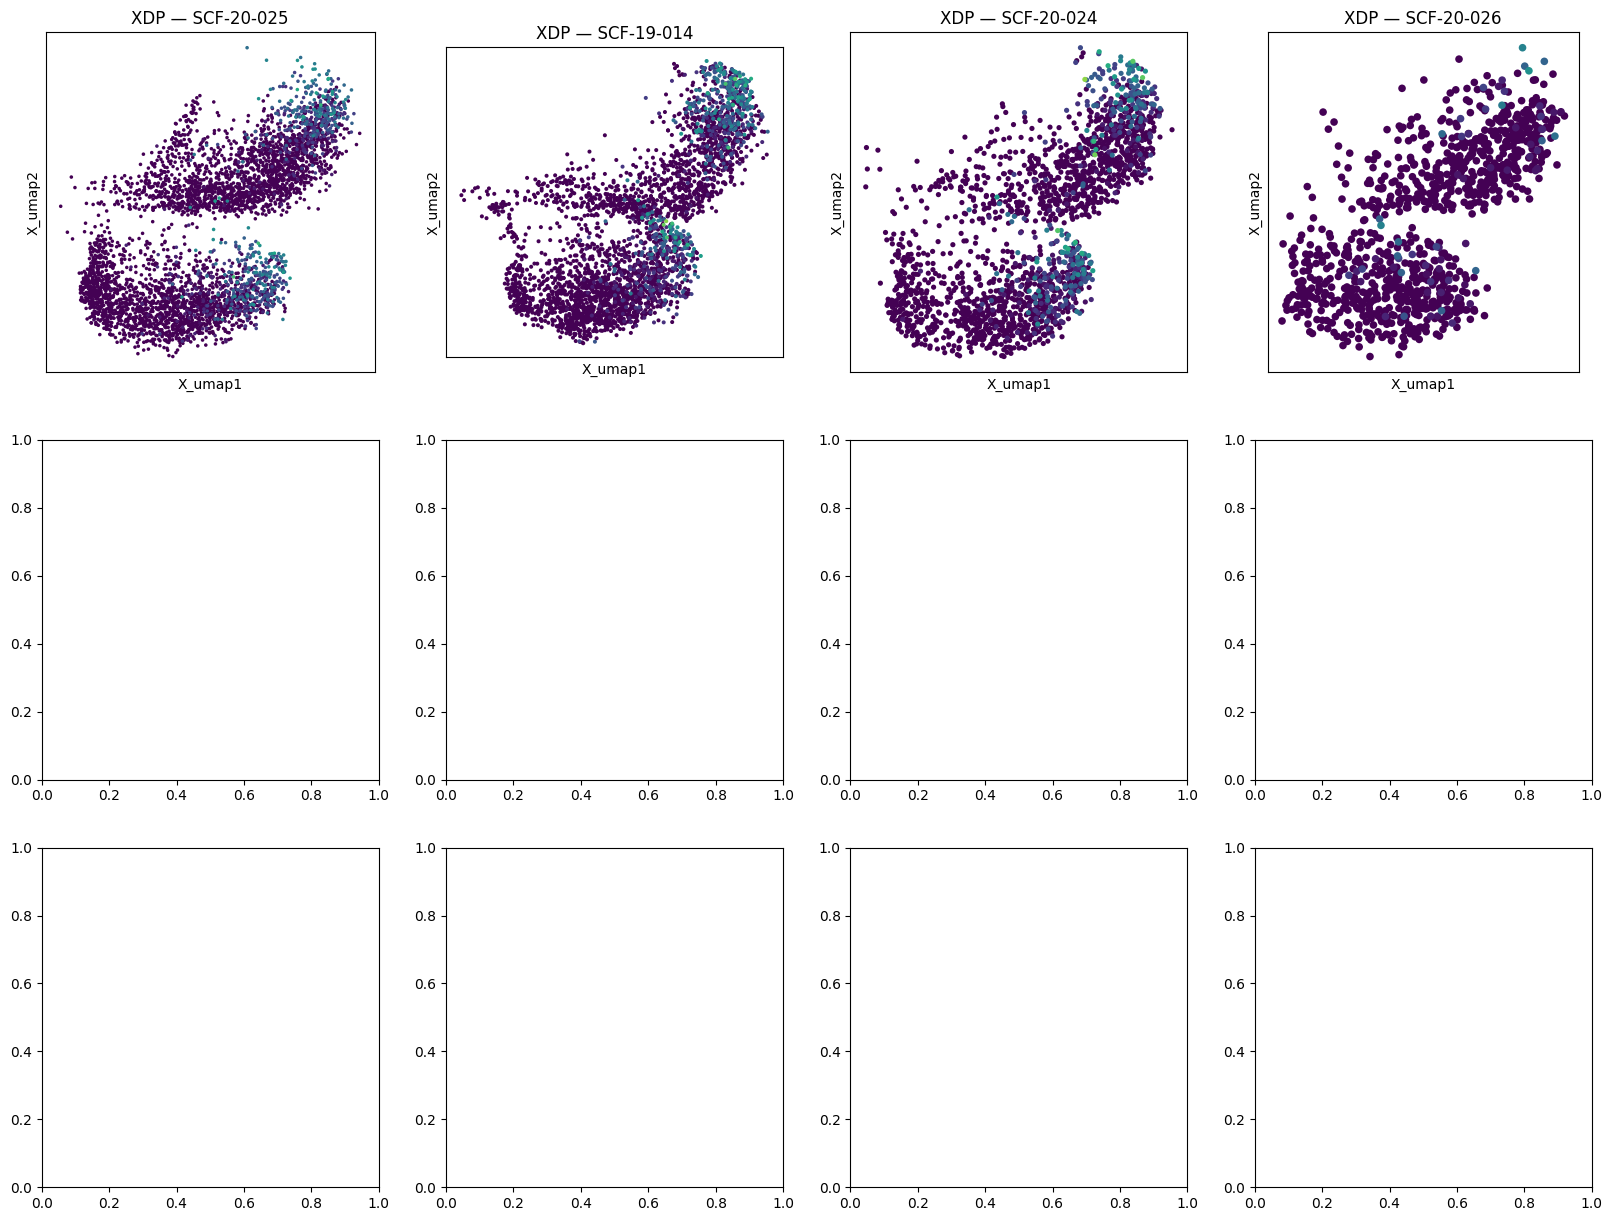

In [ ]:
GENE = "TESPA1"# "BRINP3"# "GLI3" #<- change this
%matplotlib inline

datasets = [("XDP", xdp_adata_sub), ("health", adata), ("health_matched", adata_matched)]
ncols = 4

for ct in ["Matrix", "Patch", "eMSN_D1D2"]:

    nrows = len(datasets)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = np.atleast_2d(axes)

    # shared color scale across ALL datasets/donors for this cell type, so rows are comparable
    vmax = 0.0
    for name, a in datasets:
        x = a[a.obs["ct"] == ct][:, GENE].layers["log1p_norm"]
        x = x.toarray() if sparse.issparse(x) else np.asarray(x)
        vmax = max(vmax, x.max())

    for row, (name, a) in enumerate(datasets):
        adata_ct = a[a.obs["ct"] == ct].copy()
        adata_ct.X = adata_ct.layers["log1p_norm"]   # set layer for plotting

        donors_ct = adata_ct.obs["donor_id"].unique()[:ncols]

        for col in range(ncols):
            ax = axes[row, col]
            if col < len(donors_ct):
                s = donors_ct[col]
                sc.pl.embedding(
                    adata_ct[adata_ct.obs["donor_id"] == s],
                    basis="spatial",
                    color=GENE,
                    layer="log1p_norm",
                    title=f"{name} — {s}",
                    ax=ax,
                    show=False,
                    colorbar_loc=None,
                    vmin=0,
                    vmax=vmax,
                )
                ax.set_aspect("equal")
            else:
                ax.set_visible(False)

    fig.suptitle(f"{ct}  —  {GENE}", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [30]:
GENES = ["TESPA1", "ZNF83", "PDE8B", "RGS6", "PDE10A",]
for gene in GENES:
    for ct in ["Matrix", "Patch", "eMSN_D1D2"]:
        gf.expr_along_r(gene, ct, adata)

NameError: name 'adata' is not defined

In [67]:
for ct in ["Matrix", "Patch", "eMSN_D1D2"]:
    print(f"=== {ct} ===")
    for name, a in [("health", adata), ("xdp", xdp_adata_sub)]:
        r_ct = a[a.obs["ct"] == ct].obs["r"]
        print(f"  {name}: n={len(r_ct)}  " + r_ct.describe()[["min","25%","50%","75%","max"]].to_dict().__str__())
    print()

=== Matrix ===
  health: n=95732  {'min': 0.0, '25%': 0.21332730216951654, '50%': 0.3953946052377294, '75%': 0.6086081961639254, 'max': 1.0}
  xdp: n=11270  {'min': 0.0, '25%': 0.15395694170193805, '50%': 0.28170630119345774, '75%': 0.41232554528730037, 'max': 0.8342237771086406}

=== Patch ===
  health: n=17188  {'min': 0.0, '25%': 0.2565904771935539, '50%': 0.43181207047510817, '75%': 0.6352307255375296, 'max': 1.0}
  xdp: n=3498  {'min': 0.0, '25%': 0.2210582146569516, '50%': 0.3569609892625303, '75%': 0.47496988038793103, 'max': 0.8278948742897001}

=== eMSN_D1D2 ===
  health: n=5790  {'min': 0.0, '25%': 0.19511757502599164, '50%': 0.41684148262745485, '75%': 0.6494188222998346, 'max': 1.0}
  xdp: n=1904  {'min': 0.0, '25%': 0.18086277213504665, '50%': 0.36559921260102535, '75%': 0.5611559059187807, 'max': 1.0}



## 13. XDP-only compartment analysis

Same compartment-agreement question as §10.1, this time within XDP alone (no mean-expression
gate, and a tighter `threshold_only` — matches the parameters used in the original analysis).

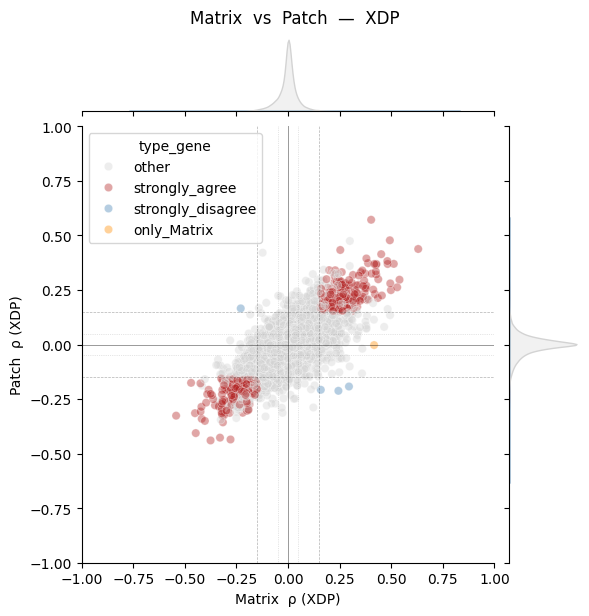

type_gene
other                23502
strongly_agree         390
strongly_disagree        4
only_Matrix              1
Name: Matrix  vs  Patch  —  XDP, dtype: int64

strongly_disagree


,rho_Matrix,rho_Patch,padj_Matrix,padj_Patch,pct_expr_Matrix,pct_expr_Patch,type_gene
gene_symbol,,,,,,,
NTM,0.295142,-0.192185,6.792116e-05,8.244784e-19,0.932919,0.955975,strongly_disagree
PTCHD4,0.243914,-0.211937,3.594888e-03,1.606004e-09,0.739574,0.280446,strongly_disagree
MGAT4C,-0.229210,0.165840,1.241836e-03,6.447307e-10,0.883141,0.842481,strongly_disagree
EPB41L4A,0.158680,-0.207301,1.241622e-07,1.493161e-03,0.804791,0.817610,strongly_disagree


only_Matrix


,rho_Matrix,rho_Patch,padj_Matrix,padj_Patch,pct_expr_Matrix,pct_expr_Patch,type_gene
gene_symbol,,,,,,,
SAMD5,0.416877,-0.002355,9.559653e-13,1.0,0.642236,0.161235,only_Matrix


only_Patch


,rho_Matrix,rho_Patch,padj_Matrix,padj_Patch,pct_expr_Matrix,pct_expr_Patch,type_gene
gene_symbol,,,,,,,


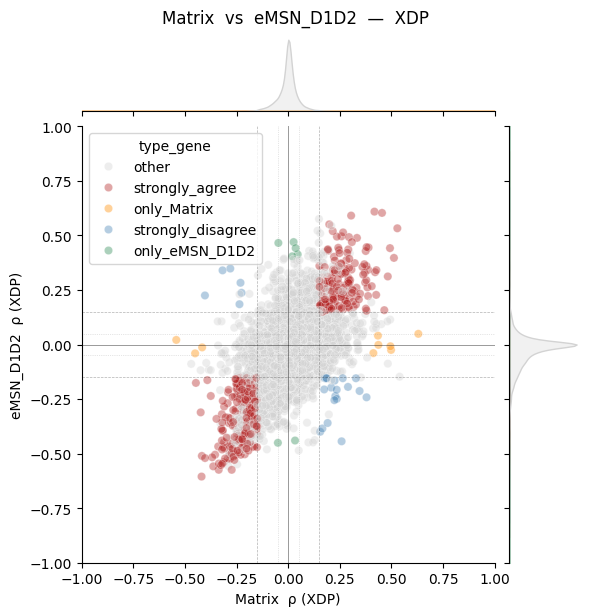

type_gene
other                23420
strongly_agree         436
strongly_disagree       25
only_Matrix              9
only_eMSN_D1D2           7
Name: Matrix  vs  eMSN_D1D2  —  XDP, dtype: int64

strongly_disagree


,rho_Matrix,rho_eMSN,padj_Matrix,padj_eMSN,pct_expr_Matrix,pct_expr_eMSN,type_gene
gene_symbol,,,,,,,
SEMA3E,-0.403365,0.225141,7.339620e-45,9.471420e-16,0.307010,0.239496,strongly_disagree
GRM3,0.379566,-0.241717,1.669709e-05,4.924652e-25,0.976220,0.435924,strongly_disagree
DPP10,0.345834,-0.212804,1.204910e-08,4.307376e-03,0.467791,0.905987,strongly_disagree
KCNK2,0.328160,-0.154339,1.265651e-11,3.365787e-05,0.626619,0.758929,strongly_disagree
STAC,-0.318016,0.340202,3.299107e-69,2.284827e-06,0.206389,0.728466,strongly_disagree
CHRM3,0.289696,-0.193994,2.896359e-06,1.382320e-02,0.467169,0.597164,strongly_disagree
PDE8B,-0.280570,0.348513,8.473033e-05,7.814185e-11,0.882786,0.982143,strongly_disagree
TUSC3,0.264308,-0.154246,8.277406e-17,2.000219e-10,0.986957,0.943277,strongly_disagree
NDST3,0.258780,-0.443415,6.276520e-05,6.992920e-10,0.977285,0.586134,strongly_disagree


only_Matrix


,rho_Matrix,rho_eMSN,padj_Matrix,padj_eMSN,pct_expr_Matrix,pct_expr_eMSN,type_gene
gene_symbol,,,,,,,
SLC24A2,0.630568,0.049235,2.390123e-12,0.313400,0.955280,0.442752,only_Matrix
HCN1,-0.542292,0.021337,3.139811e-31,0.953407,0.786424,0.955357,only_Matrix
CDH6,0.498352,-0.024639,7.202610e-10,0.526025,0.717924,0.005777,only_Matrix
SPOCK1,0.495265,-0.007683,5.859622e-18,1.000000,0.780035,0.252626,only_Matrix
ARHGAP6,-0.450889,-0.040195,6.379138e-05,0.744002,0.791571,0.147584,only_Matrix
ITPR1,0.436973,-0.001447,7.967172e-25,1.000000,0.988021,0.923845,only_Matrix
HS3ST5,0.434949,0.040911,3.454825e-07,0.592872,0.971606,0.873424,only_Matrix
ADAMTS9-AS2,-0.416965,-0.012926,7.895916e-15,0.836290,0.320586,0.002626,only_Matrix
HS3ST4,0.412604,-0.039171,2.966641e-17,0.210991,0.430435,0.178046,only_Matrix


only_eMSN_D1D2


,rho_Matrix,rho_eMSN,padj_Matrix,padj_eMSN,pct_expr_Matrix,pct_expr_eMSN,type_gene
gene_symbol,,,,,,,
SGCZ,0.026257,0.469889,0.022205,2.794848e-26,0.994232,0.629727,only_eMSN_D1D2
NRG1,-0.047700,0.465885,0.575722,1.425283e-08,0.971074,0.994748,only_eMSN_D1D2
CDH2,-0.049894,-0.450280,0.557112,2.397831e-22,0.936025,0.946429,only_eMSN_D1D2
SPECC1,0.036216,0.441992,0.616923,7.278597e-07,0.783762,0.986870,only_eMSN_D1D2
TENM3,0.033179,-0.439820,0.091713,1.331819e-11,0.985626,0.819328,only_eMSN_D1D2
KAZN,0.046098,0.413133,0.497280,7.204077e-12,0.994055,0.996324,only_eMSN_D1D2
KIAA1217,0.019723,0.404639,0.917520,2.778019e-19,0.948713,0.782563,only_eMSN_D1D2


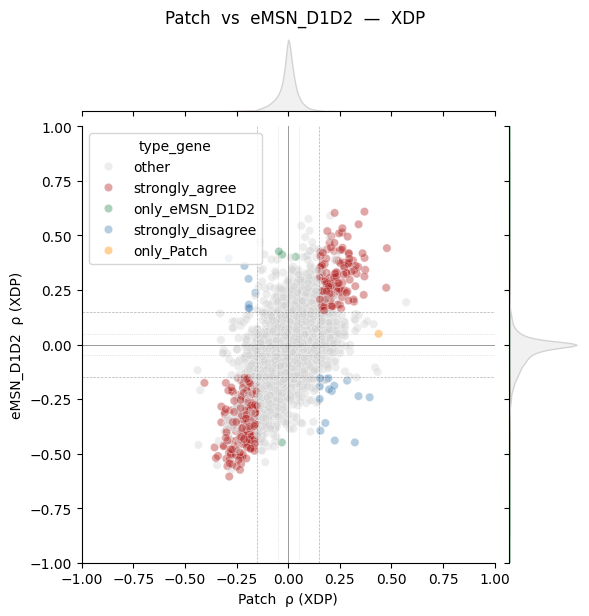

type_gene
other                23452
strongly_agree         418
strongly_disagree       22
only_eMSN_D1D2           4
only_Patch               1
Name: Patch  vs  eMSN_D1D2  —  XDP, dtype: int64

strongly_disagree


,rho_Patch,rho_eMSN,padj_Patch,padj_eMSN,pct_expr_Patch,pct_expr_eMSN,type_gene
gene_symbol,,,,,,,
GRM3,0.394632,-0.241717,1.223553e-15,4.924652e-25,0.980560,0.435924,strongly_disagree
LINC03051,0.340692,-0.236394,2.351739e-05,9.288659e-13,0.990280,0.992647,strongly_disagree
SPATS2L,0.322984,-0.448481,2.767735e-83,6.647052e-68,0.584906,0.693277,strongly_disagree
DLGAP1,-0.288349,0.394785,3.341627e-65,1.091909e-10,0.995426,0.984769,strongly_disagree
CNTN4,0.285560,-0.165287,1.660684e-06,4.703571e-02,0.975700,0.680147,strongly_disagree
TENM3,0.225587,-0.439820,3.140180e-09,1.331819e-11,0.985706,0.819328,strongly_disagree
RGS12,0.222889,-0.188455,8.169058e-03,8.500569e-05,0.952544,0.769958,strongly_disagree
PTCHD4,-0.211937,0.360553,1.606004e-09,5.513415e-09,0.280446,0.258403,strongly_disagree
DPP10,0.211372,-0.212804,1.895440e-12,4.307376e-03,0.365066,0.905987,strongly_disagree


only_Patch


,rho_Patch,rho_eMSN,padj_Patch,padj_eMSN,pct_expr_Patch,pct_expr_eMSN,type_gene
gene_symbol,,,,,,,
SLC24A2,0.43817,0.049235,0.00009,0.3134,0.991138,0.442752,only_Patch


only_eMSN_D1D2


,rho_Patch,rho_eMSN,padj_Patch,padj_eMSN,pct_expr_Patch,pct_expr_eMSN,type_gene
gene_symbol,,,,,,,
KCTD8,-0.030635,-0.448521,0.675821,6.474946e-62,0.983705,0.446429,only_eMSN_D1D2
LRRTM4,-0.044853,0.426710,0.552928,2.313693e-30,0.992853,0.966387,only_eMSN_D1D2
CALCRL,-0.029414,0.412031,0.787687,5.516253e-42,0.039451,0.443803,only_eMSN_D1D2
DOK6,0.036303,0.402341,0.870813,3.338118e-09,0.939394,0.947479,only_eMSN_D1D2


In [69]:
THRESHOLD          = 0.15    # minimum |rho| to count as "has gradient"
THRESHOLD_SPECIFIC = 0.4    # minimum |rho| to count as "cell-type specific"
THRESHOLD_ONLY     = 0.05   # maximum |rho| to count as "truly absent"
PADJ_THR           = 0.05
MIN_PCT_EXPR       = 0.20

# df_corr_xdp columns use "eMSN", not "eMSN_D1D2" — same remap as the healthy version
col_label = {"Matrix": "Matrix", "Patch": "Patch", "eMSN_D1D2": "eMSN"}

for ct_x, ct_y in combinations(["Matrix", "Patch", "eMSN_D1D2"], 2):
    lx, ly = col_label[ct_x], col_label[ct_y]
    df_pair = classify_gradient_agreement(
        df_corr_xdp,
        rho_x=f"rho_{lx}", rho_y=f"rho_{ly}",
        padj_x=f"padj_{lx}", padj_y=f"padj_{ly}",
        pexpr_x=f"pct_expr_{lx}", pexpr_y=f"pct_expr_{ly}",
        mexpr_x=None, mexpr_y=None,   # no mean-expr gate in the XDP-only pass (original behavior)
        threshold=THRESHOLD, threshold_specific=THRESHOLD_SPECIFIC, threshold_only=THRESHOLD_ONLY,
        padj_thr=PADJ_THR, min_pct_expr=MIN_PCT_EXPR,
        label_x=ct_x, label_y=ct_y,
    )
    plot_gradient_agreement(
        df_pair, rho_x=f"rho_{lx}", rho_y=f"rho_{ly}",
        threshold=THRESHOLD, threshold_only=THRESHOLD_ONLY,
        label_x=ct_x, label_y=ct_y,
        xlabel=f"{ct_x}  ρ (XDP)", ylabel=f"{ct_y}  ρ (XDP)",
        title=f"{ct_x}  vs  {ct_y}  —  XDP",
    )

## 14. Prioritization score & pathway enrichment

Combine rho, significance, and expression into single scalar scores (via the `confidence` /
`soft_expr_weight` / `signed_evidence` primitives from §7.8) to rank candidate genes three ways,
then run GSEA prerank on the vulnerability-change ranking.

In [ ]:
# ===== risk-factor pattern in healthy data (dorsal-high M & P, flat eMSN) =====
evM = signed_evidence(df_corr["rho_Matrix"], df_corr["padj_Matrix"], df_corr["pct_expr_Matrix"])
evP = signed_evidence(df_corr["rho_Patch"],  df_corr["padj_Patch"],  df_corr["pct_expr_Patch"])
evE = signed_evidence(df_corr["rho_eMSN"],   df_corr["padj_eMSN"],   df_corr["pct_expr_eMSN"])

# min(M,P) forces BOTH compartments to carry the signal (a sum lets one alone win);
# subtract |eMSN| to penalise any eMSN gradient ("flat in eMSN").
risk_score = np.minimum(evM, evP) - evE.abs()
print("Risk score = min(evM, evP) - |evE|  (strongest when M & P agree and eMSN is flat)")
display(risk_score.sort_values(ascending=False).head(30))

# ===== health -> XDP change in one cell type, effect-size-led =====
CT = FOCUS_CT                                  # was hardcoded "Patch" — now set via FOCUS_CT in §1
g = df_corr.index.intersection(df_corr_xdp.index)

rho_h = df_corr.loc[g,     f"rho_{CT}"].fillna(0.0)
rho_x = df_corr_xdp.loc[g, f"rho_{CT}"].fillna(0.0)

d_rho     = rho_x - rho_h                       # the signal is the effect-size shift
conf_gate = np.maximum(confidence(df_corr.loc[g, f"padj_{CT}"]),      # credible in EITHER condition
                       confidence(df_corr_xdp.loc[g, f"padj_{CT}"]))
expr_gate = np.minimum(soft_expr_weight(df_corr.loc[g, f"pct_expr_{CT}"]),
                       soft_expr_weight(df_corr_xdp.loc[g, f"pct_expr_{CT}"]))

change_score = d_rho * conf_gate * expr_gate
reversal     = np.maximum(0.0, -(rho_h * rho_x))   # >0 only when the gradient flips sign

out = pd.DataFrame({"change_score": change_score, "reversal": reversal,
                    f"rho_{CT}_health": rho_h, f"rho_{CT}_xdp": rho_x})
print(f"Change score (for {CT}) = (rho_XDP - rho_health) * confidence * expression_weight  (strongest when the gradient flips sign)")
display(out.reindex(change_score.abs().sort_values(ascending=False).index).head(30))

# ===== vulnerability-specific change: M & P move, eMSN as REFERENCE (not a 3rd axis) =====
def ct_change(ct):
    h = df_corr.loc[g, f"rho_{ct}"].fillna(0.0); x = df_corr_xdp.loc[g, f"rho_{ct}"].fillna(0.0)
    cg = np.maximum(confidence(df_corr.loc[g, f"padj_{ct}"]), confidence(df_corr_xdp.loc[g, f"padj_{ct}"]))
    eg = np.minimum(soft_expr_weight(df_corr.loc[g, f"pct_expr_{ct}"]),
                    soft_expr_weight(df_corr_xdp.loc[g, f"pct_expr_{ct}"]))
    return (x - h) * cg * eg

chg = {ct: ct_change(ct) for ct in ["Matrix", "Patch", "eMSN"]}
vuln_change = (chg["Matrix"].abs() + chg["Patch"].abs()) - chg["eMSN"].abs()
print("Vulnerability change score = (|ΔM| + |ΔP|) - |ΔeMSN|  (which genes change in the vulnerable compartments while staying put in the spared one.)")
display(vuln_change.sort_values(ascending=False).head(30))
sns.histplot(vuln_change, bins=50, kde=True); plt.title("Vulnerability change score distribution"); plt.xlabel("vulnerability change score"); plt.yscale("log"); plt.show()

In [34]:
import gseapy as gp

# gseapy wants a clean 2-column table: gene name, ranking metric — no NaN/inf,
# no duplicate gene names, sorted descending (classic .rnk format).
rnk = (
    vuln_change
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values(ascending=False)
)
rnk = rnk[~rnk.index.duplicated(keep="first")]   # gseapy can misbehave on duplicate gene names
rnk = rnk.reset_index()
rnk.columns = ["gene_name", "score"]

# apply after the rnk cleanup from before (rnk = gene_name, score, deduped, sorted)
is_ensembl = rnk["gene_name"].str.match(r"^ENSG\d+$")
is_mito    = rnk["gene_name"].str.startswith("MT-")
is_ribo    = rnk["gene_name"].str.match(r"^RP[SL]\d")
is_tech    = rnk["gene_name"].isin(["MALAT1", "NEAT1"])
# only include this if health/XDP donors aren't sex-matched
is_sexlinked = rnk["gene_name"].isin(["XIST", "RPS4Y1", "DDX3Y", "KDM5D", "UTY", "EIF1AY"])
drop = is_ensembl | is_mito | is_ribo | is_tech   # | is_sexlinked
print(f"dropping {drop.sum()} / {len(rnk)} entries: "
      f"{rnk.loc[drop, 'gene_name'].tolist()[:20]}...")
rnk_clean = rnk[~drop].reset_index(drop=True)


pre_res = gp.prerank(
    rnk=rnk_clean,
    gene_sets="Reactome_Pathways_2024", #KEGG_2021_Human, GO_Biological_Process_2023, Reactome_Pathways_2024
    min_size=15,
    max_size=200,
    permutation_num=500,
    seed=0,
    outdir=None,
)

pre_res.res2d.sort_values("NES", ascending=False).head(20)

dropping 117 / 23631 entries: ['RPS6KA6', 'RPS6KA5', 'RPS6KA3', 'RPL10A', 'RPS10', 'MT-ND3', 'RPS6KL1', 'RPL21', 'RPS3', 'RPL17', 'RPS27L', 'RPS3A', 'RPL7', 'MT-ND1', 'MT-ND4L', 'RPL11', 'RPS29', 'RPL37', 'RPS6KC1', 'RPL37A']...


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
8,prerank,Keratinization,0.898148,1.632351,0.0,0.0,0.0,3/114,1.97%,PKP2;PCSK6;PKP4
17,prerank,Formation of the Cornified Envelope,0.90382,1.580751,0.0,0.00064,0.002,3/81,1.97%,PKP2;PCSK6;PKP4
36,prerank,Chemokine Receptors Bind Chemokines,0.917452,1.52064,0.0,0.020471,0.068,1/45,7.03%,CX3CL1
102,prerank,ECM Proteoglycans,0.81192,1.44486,0.002591,0.403338,0.76,8/74,11.29%,NCAN;ITGA9;TNR;LAMB2;APP;AGRN;SPARC;COL1A1
117,prerank,CDC42 GTPase Cycle,0.754008,1.430742,0.002304,0.512792,0.892,26/153,6.57%,ARHGAP10;SRGAP1;FARP1;WIPF3;VAV3;DOCK11;RASGRF...
124,prerank,Kidney Development,0.87565,1.422175,0.008108,0.548659,0.942,5/40,5.78%,NPNT;JAG1;ROBO2;EYA1;GFRA1
133,prerank,Nitric Oxide Stimulates Guanylate Cyclase,0.930961,1.409629,0.005917,0.6706,0.97,6/20,3.13%,PRKG1;PDE10A;PDE2A;PDE9A;GUCY1A2;ITPR1
136,prerank,Xenobiotics,0.928079,1.406525,0.002959,0.638272,0.976,2/24,1.76%,AHR;ARNT2
143,prerank,Collagen Chain Trimerization,0.837593,1.397133,0.00551,0.721594,0.992,4/44,6.03%,COL25A1;COL19A1;COL11A1;COL26A1
146,prerank,Cell Junction Organization,0.755757,1.392824,0.014354,0.721978,0.996,20/111,4.58%,CDH12;CDH9;CADM1;LIMS1;PRKCI;LIMS2;CADM3;CDH8;...


## 16. Held-out validation: interesting genes in XDP donors excluded from the analysis

§3 excluded two diseased donors (`SCF-18-003`, `SCF-18-006`) as "not complete STR XDP samples."
They were never included in the discovery analysis above, and — since they were never part of
the spline-fitting step in §5 — they have no `r`/`d` axis to quantify against. What we *can* do
is a purely visual replication check: plot each `INTERESTING_GENES` spatially in these held-out
donors and see whether the same qualitative pattern (e.g. dorsal-high or ventral-high) shows up,
as an independent sanity check that isn't influenced by the donors used to select the gene list.

In [73]:
HELDOUT_XDP_DONORS = ["SCF-18-003", "SCF-18-006"]

xdp_adata_heldout = xdp_adata[
    (xdp_adata.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2", "Patch_D1", "Patch_D2", "eMSN_D1D2"])) &
    (xdp_adata.obs["donor_id"].notna()) &
    (xdp_adata.obs["donor_id"].isin(HELDOUT_XDP_DONORS)) &
    (xdp_adata.obs["x"].notna() & xdp_adata.obs["y"].notna())
].to_memory().copy()

xdp_adata_heldout.obs["ct"] = xdp_adata_heldout.obs["ct_for_deg"].map({
    "Matrix_D1": "Matrix", "Matrix_D2": "Matrix",
    "Patch_D1": "Patch",  "Patch_D2": "Patch",
    "eMSN_D1D2": "eMSN_D1D2",
})
xdp_adata_heldout.obs[["x", "y"]] = xdp_adata_heldout.obsm["spatial"].copy()
xdp_adata_heldout = xdp_adata_heldout[xdp_adata_heldout.obs["x"].notna() & xdp_adata_heldout.obs["y"].notna()].copy()

xdp_adata_heldout.var_names = xdp_adata_heldout.var["gene_symbol"].copy()
xdp_adata_heldout.var_names = xdp_adata_heldout.var_names.astype(str)
xdp_adata_heldout.var_names_make_unique()

# NOTE: no "dead region" filtering here (unlike xdp_adata_sub in §3) - that filter relies on
# `region`, which comes from the spline fit in §5, and these donors were never spline-fitted.
xdp_adata_heldout = process_adata(xdp_adata_heldout)  # same normalization pipeline as the discovery data

print(xdp_adata_heldout)
print(xdp_adata_heldout.obs["donor_id"].value_counts())
print(xdp_adata_heldout.obs["ct"].value_counts())

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:865: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['DDX11L2', 'MIR1302-2HG', 'ENSG00000290826', 'OR4F5', 'ENSG00000238009']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


AnnData object with n_obs × n_vars = 7509 × 23106
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_cel

In [ ]:
%matplotlib inline

genes_to_check = [g for g in INTERESTING_GENES if g in xdp_adata_heldout.var_names]
print(f"{len(genes_to_check)} / {len(INTERESTING_GENES)} interesting genes found in held-out donors")

for ct in xdp_adata_heldout.obs["ct"].unique():
    adata_ct = xdp_adata_heldout[xdp_adata_heldout.obs["ct"] == ct].copy()
    adata_ct.X = adata_ct.layers["log1p_norm"]
    donors_ct = adata_ct.obs["donor_id"].unique()
    if len(donors_ct) == 0:
        continue

    for gene in genes_to_check:
        fig, axes = plt.subplots(1, len(donors_ct), figsize=(5 * len(donors_ct), 5))
        axes = np.atleast_1d(axes)
        for ax, s in zip(axes, donors_ct):
            sc.pl.embedding(
                adata_ct[adata_ct.obs["donor_id"] == s],
                basis="spatial",
                color=gene,
                layer="counts",
                title=f"{s}  (held out)",
                ax=ax,
                show=False,
                colorbar_loc=None,
                cmap="Reds", vmin=0, vmax=None
            )
            ax.set_aspect("equal")
        fig.suptitle(f"{gene}  —  {ct}", fontsize=12, y=1.03)
        plt.tight_layout()
        plt.show()

# Jumps

In [22]:
df_corr_sig

NameError: name 'df_corr_sig' is not defined

=== Matrix: top genes by jump score (rho-gated) ===


,jump_score,jump_location,jump_fraction,dist_to_xdp_boundary
NAB1,2.922199,0.3,0.185760,0.316754
SHANK1,2.736781,0.3,0.207776,0.316754
NAT16,2.735400,0.3,0.266743,0.316754
DNAH14,2.725763,0.3,0.185180,0.316754
GTF2F2,2.670213,0.3,0.205130,0.316754
COL21A1,2.647059,0.3,0.183300,0.316754
LINC02249,2.552430,0.3,0.171373,0.316754
EML4,2.514717,0.3,0.201135,0.316754


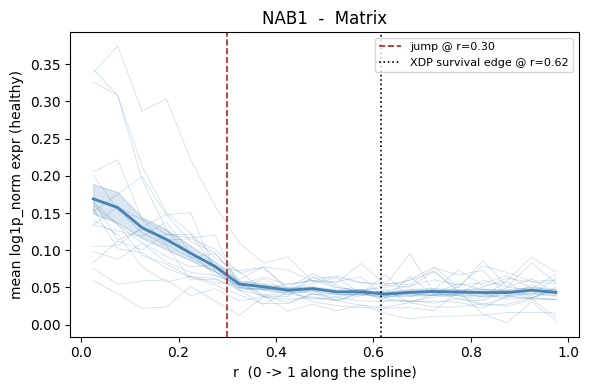

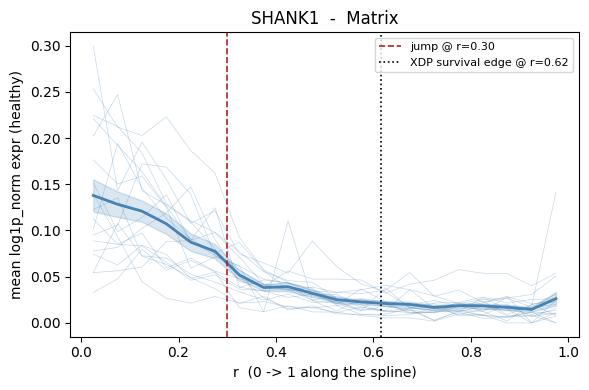

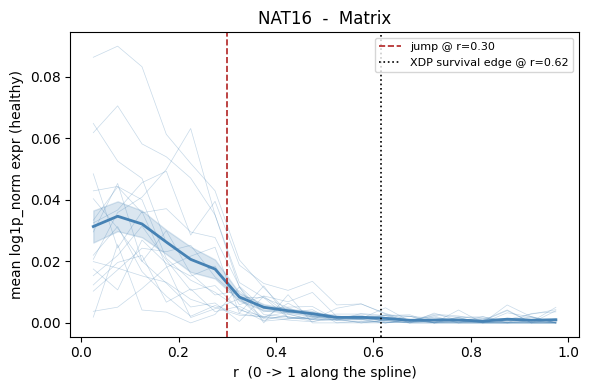

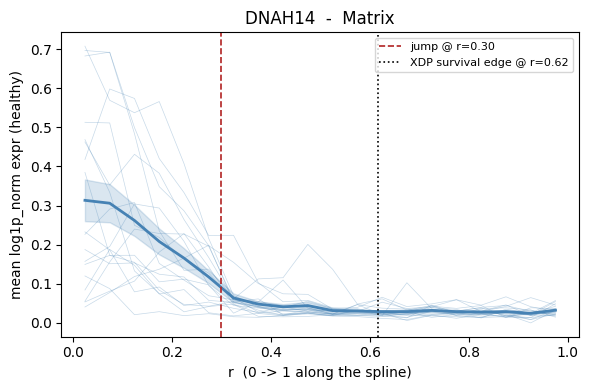

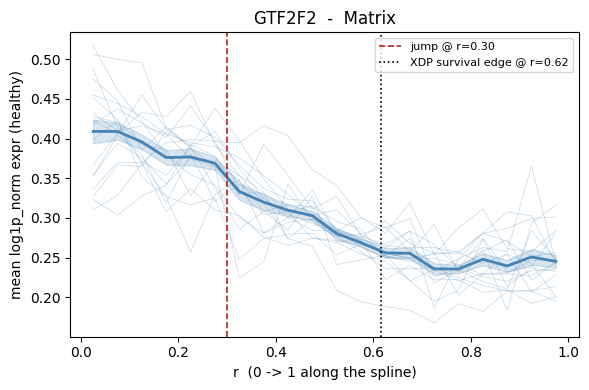

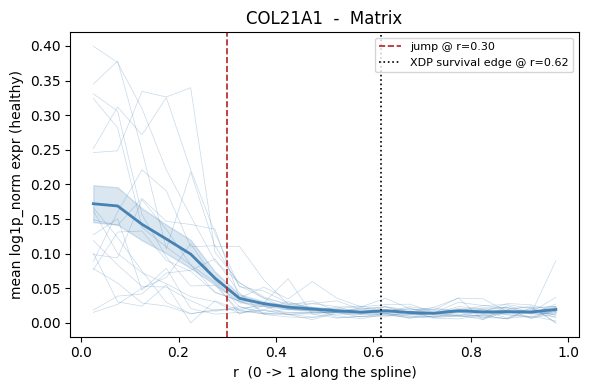

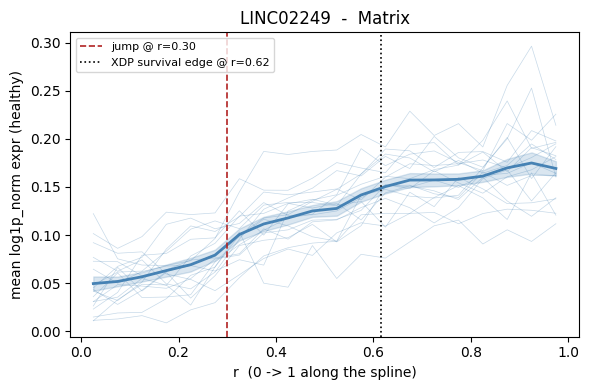

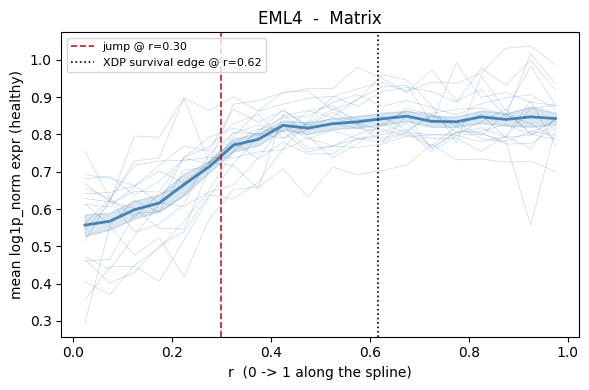

=== Patch: top genes by jump score (rho-gated) ===


,jump_score,jump_location,jump_fraction,dist_to_xdp_boundary
ACVR1C,3.575433,0.35,0.320708,0.29059
SAMD5,3.208589,0.70,0.380085,0.05941
SCN9A,3.170593,0.80,0.179946,0.15941
SASH1,3.072241,0.70,0.339607,0.05941
LDLRAD3,3.065747,0.50,0.165514,0.14059
MIR924HG,3.063578,0.75,0.107808,0.10941
DAPK1,2.961016,0.20,0.307228,0.44059
ST3GAL6,2.942098,0.45,0.274780,0.19059


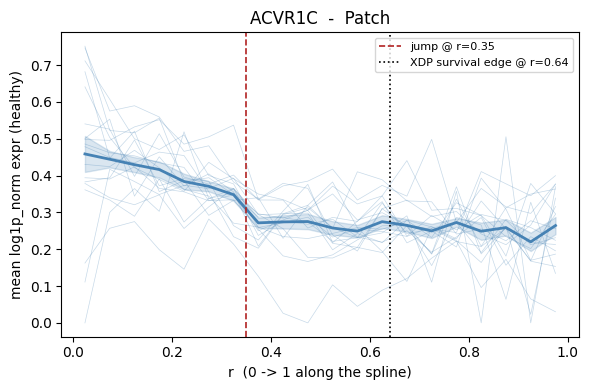

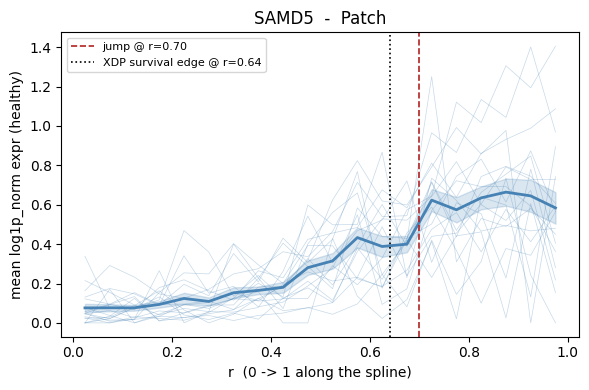

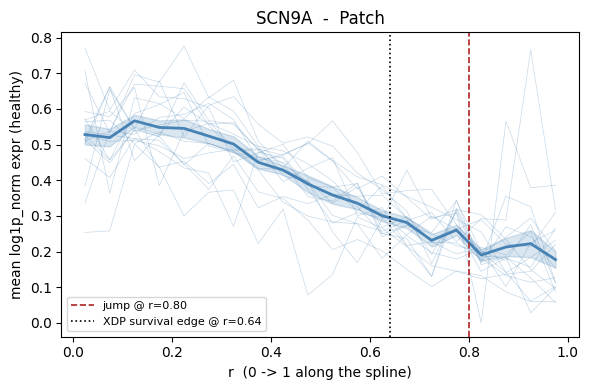

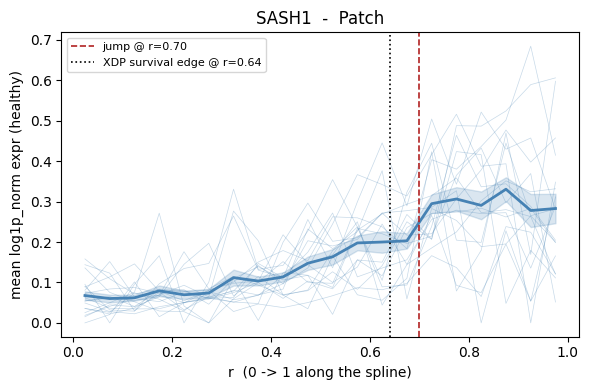

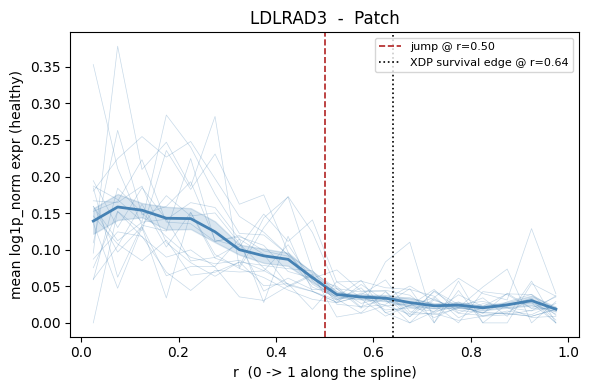

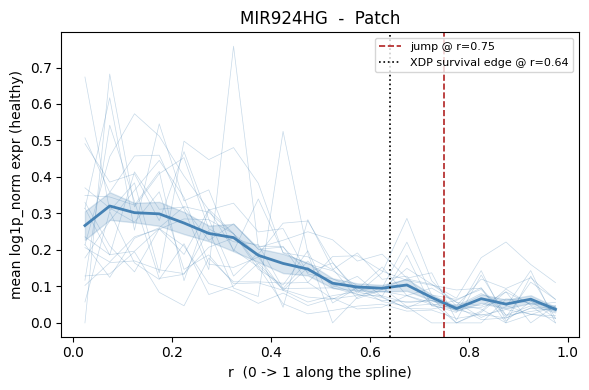

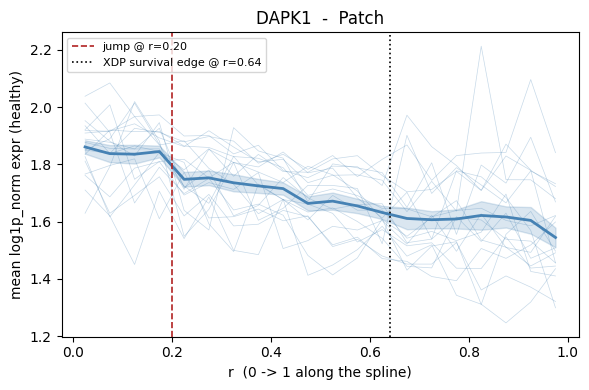

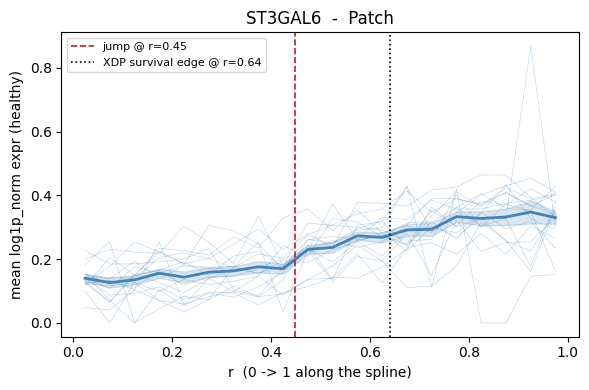

In [65]:
def calc_jump_scores(adata, ct, genes=None, n_bins=20, donor_col="donor_id", metric_key="r",
                      min_cells=20, min_donors_per_bin=3, df_corr=None, min_rho=0.2):
    """For every gene, find the single sharpest local jump in mean expression along r -
    rather than an overall monotonic trend - so gradients and discrete step/zone boundaries
    can be told apart. Same per-donor binning as expr_along_r (§7.9), vectorized across genes.

    Two guards against a spurious "jump" driven by a handful of noisy edge cells rather than
    a real transition: `min_donors_per_bin` requires enough donors on both sides of a
    candidate boundary, and `min_rho` (if df_corr is given) restricts to genes that already
    have a real overall gradient (rho_<ct> from Part 8) - a gene that's flat everywhere except
    a wobble in a sparse terminal bin has a small overall rho and gets excluded, even if its
    local jump z-score looks big.

    Returns a DataFrame indexed by gene with:
      jump_score    - |z| of the sharpest bin-to-bin mean shift (in SE units, like a t-stat)
      jump_location - r-value of that boundary
      jump_fraction - fraction of the gene's total dynamic range concentrated in that one step
                       (near 1 = a true switch; low with high rho = a smooth gradient)
    """
    adata_ct = adata[adata.obs["ct"] == ct]
    genes = adata_ct.var_names.tolist() if genes is None else [g for g in genes if g in adata_ct.var_names]

    if df_corr is not None and min_rho is not None:
        genes = [g for g in genes if g in df_corr.index and abs(df_corr.loc[g, f"rho_{ct}"]) >= min_rho]
    if len(genes) == 0:
        return pd.DataFrame(columns=["jump_score", "jump_location", "jump_fraction"])

    X_full = adata_ct[:, genes].layers["log1p_norm"]
    X_full = X_full.toarray() if sparse.issparse(X_full) else np.asarray(X_full, dtype=float)
    r_full = adata_ct.obs[metric_key].values.astype(float)
    donors_full = adata_ct.obs[donor_col].values

    bins = np.linspace(0, 1, n_bins + 1)
    n_genes = len(genes)

    donor_curves = []  # (n_bins, n_genes) per donor, NaN where a bin had no cells
    for donor in pd.unique(donors_full):
        mask = (donors_full == donor) & ~np.isnan(r_full)
        if mask.sum() < min_cells:
            continue
        bin_idx = np.clip(np.digitize(r_full[mask], bins) - 1, 0, n_bins - 1)
        Xd = X_full[mask]
        curve = np.full((n_bins, n_genes), np.nan)
        for b in range(n_bins):
            sel = bin_idx == b
            if sel.sum() > 0:
                curve[b] = Xd[sel].mean(axis=0)
        donor_curves.append(curve)

    donor_curves = np.array(donor_curves)                       # (n_donors, n_bins, n_genes)
    mean_curve   = np.nanmean(donor_curves, axis=0)              # (n_bins, n_genes)
    n_valid      = np.sum(~np.isnan(donor_curves), axis=0)       # donors contributing to each bin
    sem_curve    = np.nanstd(donor_curves, axis=0) / np.sqrt(np.maximum(n_valid, 1))

    d_mean    = np.diff(mean_curve, axis=0)                      # (n_bins-1, n_genes)
    se_pooled = np.sqrt(sem_curve[:-1]**2 + sem_curve[1:]**2)
    with np.errstate(divide="ignore", invalid="ignore"):
        z = np.abs(d_mean / se_pooled)

    # a boundary only counts if enough donors actually contributed to BOTH flanking bins
    reliable = (n_valid[:-1] >= min_donors_per_bin) & (n_valid[1:] >= min_donors_per_bin)
    z = np.where(reliable, z, np.nan)

    jump_score    = np.full(n_genes, np.nan)
    jump_location = np.full(n_genes, np.nan)
    jump_fraction = np.full(n_genes, np.nan)
    total_range   = np.nanmax(mean_curve, axis=0) - np.nanmin(mean_curve, axis=0)

    has_reliable = ~np.all(np.isnan(z), axis=0)
    idx = np.where(has_reliable)[0]
    if len(idx):
        best_k = np.nanargmax(z[:, idx], axis=0)
        jump_score[idx]    = z[best_k, idx]
        jump_location[idx] = bins[1:][best_k]
        with np.errstate(divide="ignore", invalid="ignore"):
            jump_fraction[idx] = np.abs(d_mean)[best_k, idx] / total_range[idx]

    return pd.DataFrame({"jump_score": jump_score, "jump_location": jump_location,
                          "jump_fraction": jump_fraction}, index=genes)


def plot_gene_jump(gene, ct, adata, xdp_boundary=None, n_bins=20, donor_col="donor_id",
                    metric_key="r", min_donors_per_bin=3):
    """Binned expression-vs-r curve for one gene (healthy), with the detected jump location
    marked (only among boundaries backed by >= min_donors_per_bin donors on each side) - and,
    if given, the r beyond which XDP cells don't survive (r_75_xdp_<ct>, §8), to check by eye
    whether the transcriptional switch coincides with the survival cutoff."""
    adata_ct = adata[adata.obs["ct"] == ct]
    X = adata_ct[:, gene].layers["log1p_norm"]
    X = X.toarray().flatten() if sparse.issparse(X) else np.asarray(X).flatten()
    r = adata_ct.obs[metric_key].values.astype(float)
    donors = adata_ct.obs[donor_col].values
    valid = ~np.isnan(r)
    X, r, donors = X[valid], r[valid], donors[valid]

    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_idx = np.clip(np.digitize(r, bins) - 1, 0, n_bins - 1)

    curves = []
    for donor in np.unique(donors):
        dmask = donors == donor
        row = np.full(n_bins, np.nan)
        for b in range(n_bins):
            sel = dmask & (bin_idx == b)
            if sel.sum() > 0:
                row[b] = X[sel].mean()
        curves.append(row)
    curves = np.array(curves)
    m       = np.nanmean(curves, axis=0)
    n_valid = (~np.isnan(curves)).sum(axis=0)
    sem     = np.nanstd(curves, axis=0) / np.sqrt(np.maximum(n_valid, 1))

    d = np.diff(m)
    se_pooled = np.sqrt(sem[:-1]**2 + sem[1:]**2)
    with np.errstate(divide="ignore", invalid="ignore"):
        z = np.abs(d / se_pooled)
    reliable = (n_valid[:-1] >= min_donors_per_bin) & (n_valid[1:] >= min_donors_per_bin)
    z = np.where(reliable, z, np.nan)

    plt.figure(figsize=(6, 4))
    plt.plot(bin_centers, m, color="steelblue", lw=2)
    plt.fill_between(bin_centers, m - sem, m + sem, color="steelblue", alpha=0.2)
    for row in curves:
        plt.plot(bin_centers, row, color="steelblue", lw=0.5, alpha=0.3)
    if np.any(~np.isnan(z)):
        jump_loc = bins[1:][np.nanargmax(z)]
        plt.axvline(jump_loc, color="firebrick", ls="--", lw=1.2, label=f"jump @ r={jump_loc:.2f}")
    else:
        print(f"{gene} ({ct}): no boundary had >= {min_donors_per_bin} donors on both sides - no jump marked")
    if xdp_boundary is not None:
        plt.axvline(xdp_boundary, color="black", ls=":", lw=1.2, label=f"XDP survival edge @ r={xdp_boundary:.2f}")
    plt.xlabel("r  (0 -> 1 along the spline)")
    plt.ylabel("mean log1p_norm expr (healthy)")
    plt.title(f"{gene}  -  {ct}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# XDP_BOUNDARY = {"Matrix": r_75_xdp_matrix, "Patch": r_75_xdp_patch, "eMSN_D1D2": r_75_xdp_d1d2}
# N_TOP = 8

# for ct in ["Matrix", "Patch"]:
#     df_jump = calc_jump_scores(adata, ct, genes=list(INTERESTING_GENES), n_bins=20,
#                                 df_corr=df_corr, min_rho=0.2)
#     df_jump["dist_to_xdp_boundary"] = (df_jump["jump_location"] - XDP_BOUNDARY[ct]).abs()

#     print(f"=== {ct}: top genes by jump score (rho-gated) ===")
#     display(df_jump.sort_values("jump_score", ascending=False).head(N_TOP))

#     for gene in df_jump.sort_values("jump_score", ascending=False).head(N_TOP).index:
#         plot_gene_jump(gene, ct, adata, xdp_boundary=XDP_BOUNDARY[ct])


XDP_BOUNDARY = {"Matrix": r_cut_matrix, "Patch": r_cut_patch, "eMSN_D1D2": r_cut_d1d2}
N_TOP = 8
SIG_GENES = df_corr_sig.index.to_list()

df_jump_matrix = calc_jump_scores(adata, "Matrix", genes=list(SIG_GENES), n_bins=20,
                            df_corr=df_corr, min_rho=0.2)
df_jump_matrix["dist_to_xdp_boundary"] = (df_jump_matrix["jump_location"] - XDP_BOUNDARY["Matrix"]).abs()

print(f"=== Matrix: top genes by jump score (rho-gated) ===")
display(df_jump_matrix.sort_values("jump_score", ascending=False).head(N_TOP))

for gene in df_jump_matrix.sort_values("jump_score", ascending=False).head(N_TOP).index:
    plot_gene_jump(gene, "Matrix", adata, xdp_boundary=XDP_BOUNDARY["Matrix"])


df_jump_patch = calc_jump_scores(adata, "Patch", genes=list(SIG_GENES), n_bins=20,
                            df_corr=df_corr, min_rho=0.2)
df_jump_patch["dist_to_xdp_boundary"] = (df_jump_patch["jump_location"] - XDP_BOUNDARY["Patch"]).abs()

print(f"=== Patch: top genes by jump score (rho-gated) ===")
display(df_jump_patch.sort_values("jump_score", ascending=False).head(N_TOP))

for gene in df_jump_patch.sort_values("jump_score", ascending=False).head(N_TOP).index:
    plot_gene_jump(gene, "Patch", adata, xdp_boundary=XDP_BOUNDARY["Patch"])

In [66]:

print(f"=== Matrix: top genes by jump score (rho-gated) ===")
display(df_jump_matrix.sort_values("jump_score", ascending=False).head(N_TOP))

=== Matrix: top genes by jump score (rho-gated) ===


,jump_score,jump_location,jump_fraction,dist_to_xdp_boundary
NAB1,2.922199,0.3,0.185760,0.316754
SHANK1,2.736781,0.3,0.207776,0.316754
NAT16,2.735400,0.3,0.266743,0.316754
DNAH14,2.725763,0.3,0.185180,0.316754
GTF2F2,2.670213,0.3,0.205130,0.316754
COL21A1,2.647059,0.3,0.183300,0.316754
LINC02249,2.552430,0.3,0.171373,0.316754
EML4,2.514717,0.3,0.201135,0.316754


In [67]:
df_jump_matrix[
    (df_jump_matrix["dist_to_xdp_boundary"] <=0.05) 
      ].sort_values(["jump_score", "jump_fraction"], ascending=[False, True])#.index.to_list()


,jump_score,jump_location,jump_fraction,dist_to_xdp_boundary
KCTD4,2.100426,0.65,0.055961,0.033246
RYR3,1.837010,0.65,0.059032,0.033246
GABRA5,1.772978,0.65,0.069351,0.033246
SAMD5,1.718866,0.65,0.076816,0.033246
TTLL11,1.694812,0.65,0.073682,0.033246
PCAT1,1.667349,0.60,0.118991,0.016754
LINC02624,1.625828,0.60,0.110443,0.016754
LY6H,1.587975,0.65,0.087044,0.033246
KIAA2012,1.583809,0.65,0.086005,0.033246
ROBO1,1.570944,0.65,0.126049,0.033246


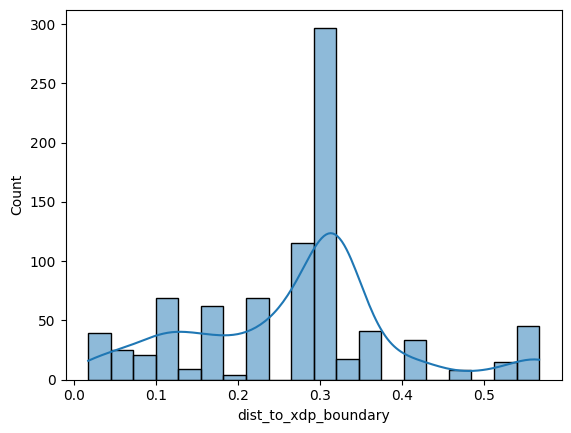

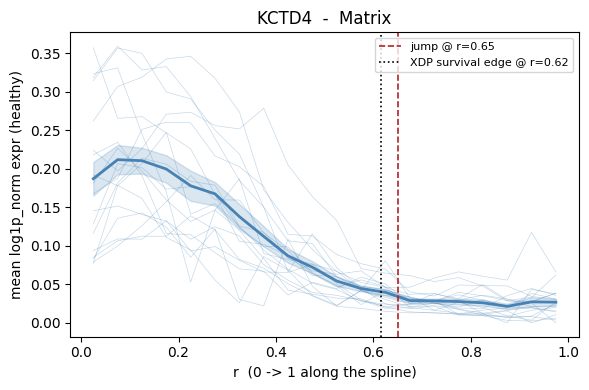

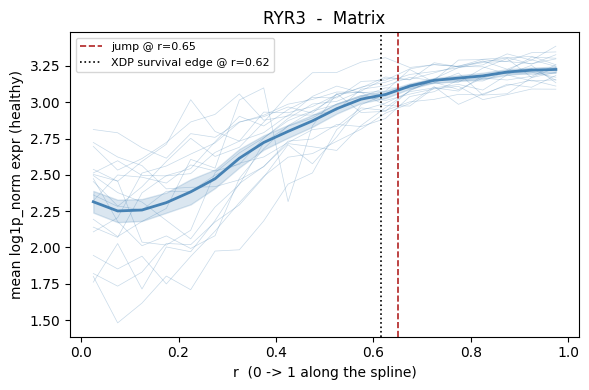

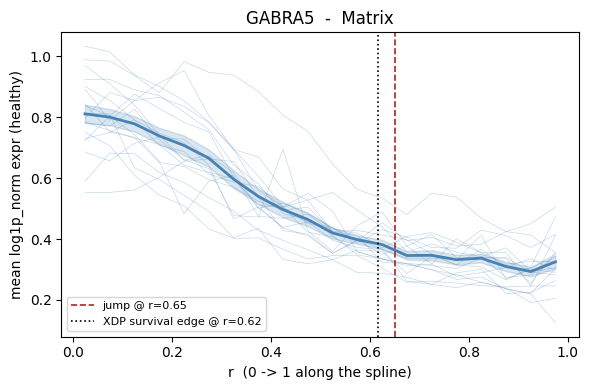

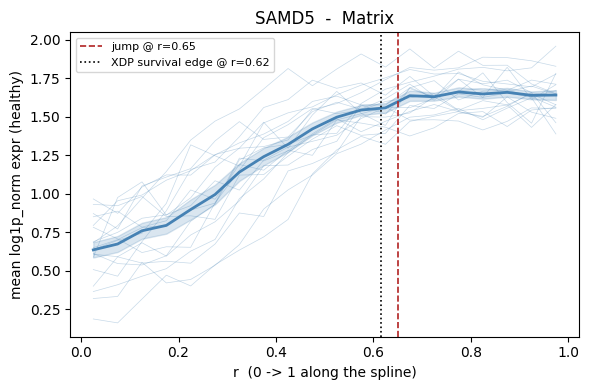

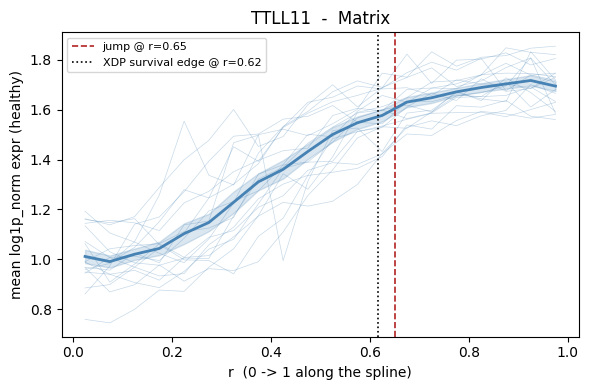

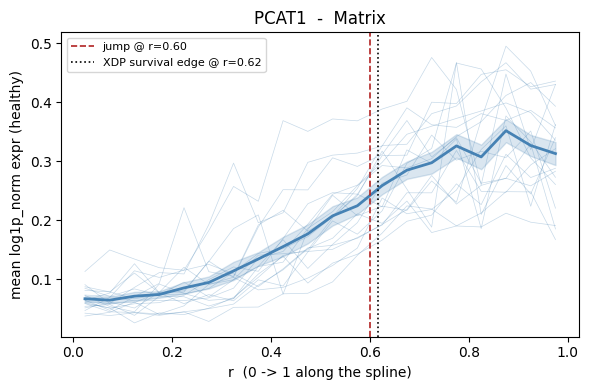

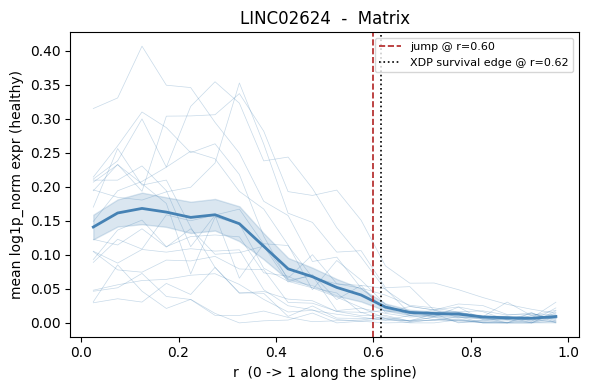

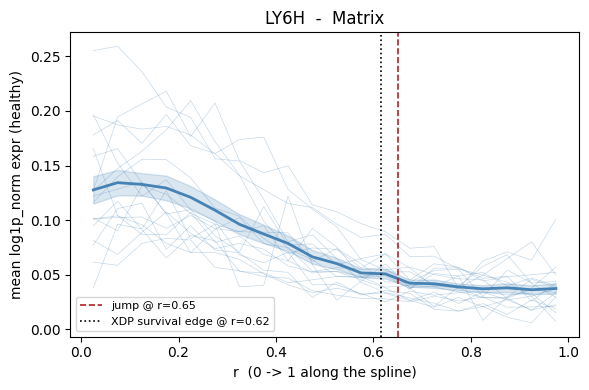

In [68]:
sns.histplot(df_jump_matrix["dist_to_xdp_boundary"], bins=20, kde=True)

genes_to_plot = df_jump_matrix[df_jump_matrix["dist_to_xdp_boundary"] <=0.05 ].sort_values(["jump_score", "jump_fraction"], ascending=[False, True]).index.to_list()

for gene in genes_to_plot[:N_TOP]:
    plot_gene_jump(gene, "Matrix", adata, xdp_boundary=XDP_BOUNDARY["Matrix"])

# cAMP

In [111]:
N_PERM = 4000
df_list = []
for ct in ["Matrix", "Patch"]:
    df_perm_xdp = permutation_test_donor_level(xdp_adata_sub, INTERESTING_GENES, ct=ct, n_perm=N_PERM)
    df_perm_xdp.columns = [f"{col}_xdp" for col in df_perm_xdp.columns] # attach "xdp" at the end of each column name
    df_list.append(df_perm_xdp)
    df_perm_matched = permutation_test_donor_level(adata_matched, INTERESTING_GENES, ct=ct, n_perm=N_PERM)
    df_perm_matched.columns = [f"{col}_matched" for col in df_perm_matched.columns] # attach "matched" at the end of each column name
    df_list.append(df_perm_matched)
df_perm_combined = pd.concat(df_list, axis=1)
df_perm_combined

Min p-value testable: 0.00025
Min p-value testable: 0.00025
Min p-value testable: 0.00025
Min p-value testable: 0.00025


,z_obs_Matrix_xdp,rho_Matrix_xdp,ci_lo_Matrix_xdp,ci_hi_Matrix_xdp,pval_Matrix_xdp,padj_Matrix_xdp,z_obs_Matrix_matched,rho_Matrix_matched,ci_lo_Matrix_matched,ci_hi_Matrix_matched,...,ci_lo_Patch_xdp,ci_hi_Patch_xdp,pval_Patch_xdp,padj_Patch_xdp,z_obs_Patch_matched,rho_Patch_matched,ci_lo_Patch_matched,ci_hi_Patch_matched,pval_Patch_matched,padj_Patch_matched
ADCY5,0.261764,0.255944,0.187311,0.322091,0.00025,0.00525,0.281453,0.274250,0.227087,0.320129,...,0.221075,0.343779,0.00025,0.00525,0.258166,0.252579,0.207473,0.296614,0.00025,0.00525
PRKACA,-0.008833,-0.008833,-0.044367,0.026724,0.34975,1.00000,-0.024519,-0.024514,-0.039502,-0.009515,...,0.017732,0.083927,0.00375,0.07875,-0.010995,-0.010995,-0.028343,0.006360,0.21950,1.00000
PRKACB,-0.135433,-0.134611,-0.186573,-0.081898,0.00025,0.00525,-0.154737,-0.153514,-0.195166,-0.111310,...,-0.052144,0.044334,0.82500,1.00000,-0.012414,-0.012413,-0.053546,0.028762,0.16250,1.00000
PRKAR1B,-0.150593,-0.149465,-0.230968,-0.065879,0.00025,0.00525,-0.152398,-0.151229,-0.182694,-0.119455,...,-0.111993,-0.046040,0.00025,0.00525,-0.104087,-0.103712,-0.128038,-0.079262,0.00025,0.00525
PRKAR2B,0.091478,0.091224,0.052193,0.129976,0.00025,0.00525,0.063651,0.063566,0.038844,0.088210,...,0.029783,0.095888,0.00025,0.00525,0.062496,0.062415,0.031413,0.093296,0.00025,0.00525
GNAL,0.044442,0.044413,-0.023813,0.112227,0.00025,0.00525,-0.030326,-0.030317,-0.069216,0.008675,...,0.064978,0.235435,0.00025,0.00525,0.008500,0.008500,-0.024018,0.040999,0.34400,1.00000
PDE1B,0.214436,0.211208,0.142157,0.278214,0.00025,0.00525,0.110289,0.109844,0.047895,0.170951,...,0.019644,0.115881,0.00025,0.00525,0.101825,0.101475,0.069085,0.133651,0.00025,0.00525
PDE2A,0.068840,0.068732,0.048942,0.088468,0.00025,0.00525,0.182418,0.180421,0.144401,0.215963,...,0.157511,0.234190,0.00025,0.00525,0.284595,0.277152,0.231391,0.321690,0.00025,0.00525
PDE4B,-0.005747,-0.005747,-0.080844,0.069415,0.55625,1.00000,-0.116384,-0.115861,-0.169927,-0.061100,...,-0.079651,0.109082,0.39675,1.00000,-0.142461,-0.141505,-0.188575,-0.093786,0.00025,0.00525
PDE4D,0.129002,0.128291,0.093166,0.163098,0.00025,0.00525,0.018012,0.018010,-0.034310,0.070231,...,0.113151,0.198297,0.00025,0.00525,-0.005111,-0.005111,-0.073745,0.063572,0.56975,1.00000


In [ ]:
plot_gene_gradient_shift_permutation(df_perm_combined, INTERESTING_GENES,  expr_df=df_corr_merged, sort_col=f"rho_{FOCUS_CT}_matched")

In [ ]:
from utils import label_mapping_utils as lmu
adata.var["gene_symbol"] = adata.var_names.copy()
adata_focus = adata[adata.obs["ct"] == FOCUS_CT].copy()
display(adata_focus)
lmu.aucell(adata_focus, gene_list=["ADCY5", "PRKACA", "PRKAR1B", "GNAL", "PDE1B", "PDE2A", "PDE4B", "PDE4D", "PDE7B", "PDE8B", "PDE9A", "PDE10A", "PPP1R1B", "PPP3CA", "ARPP21", "RGS9", "GUCY1A2", "GUCY1B1", "PRKG1"],
           name="cAMP_path")

In [ ]:
for s in adata_focus.obs["donor_id"].unique()[:2]:
    sc.pl.embedding(adata_focus[adata_focus.obs["donor_id"] == s], basis="spatial", color=["ADCY5", "PRKACA", "PRKAR1B", "GNAL", "PDE1B", "PDE2A", "PDE4B", "PDE4D", "PDE7B", "PDE8B", "PDE9A", "PDE10A", "PPP1R1B", "PPP3CA", "ARPP21", "RGS9", "GUCY1A2", "GUCY1B1", "PRKG1"], layer="log1p_norm", title=f"{s}  ({FOCUS_CT})", show=True, colorbar_loc="right", cmap="Reds", vmin=0, vmax=4)
    sc.pl.embedding(adata_focus[adata_focus.obs["donor_id"] == s], basis="spatial", color="cAMP_path", title=f"{s}  ({FOCUS_CT})", show=True, colorbar_loc="right", cmap="Reds", vmin=0, vmax=None)

,rho_Matrix_health,rho_Matrix_xdp,rho_Patch_health,rho_Patch_xdp,rho_eMSN_health,rho_eMSN_xdp,max_abs_shift
gene,,,,,,,
PDE8B,0.331277,-0.280570,0.468978,0.018991,0.367427,0.348513,0.611848
PDE4D,-0.174244,0.128291,-0.205125,0.156014,-0.515066,-0.394851,0.361138
PDE4B,-0.293733,-0.005747,-0.247227,0.014848,-0.202110,-0.248152,0.287986
PRKG1,-0.676010,-0.397036,-0.474623,-0.266210,-0.020873,-0.083855,0.278973
RGS9,0.468076,0.235246,0.270771,0.037686,0.339554,0.266280,0.233085
PPP3CA,0.062383,0.290229,-0.053143,0.132489,0.013030,0.033342,0.227847
PDE2A,0.292906,0.068732,0.350831,0.196150,0.040450,0.097907,0.224174
PDE10A,0.715793,0.493185,0.665138,0.478073,0.443463,0.442051,0.222608
ARPP21,-0.122481,-0.147947,-0.024848,-0.177937,0.179544,-0.054275,0.153089


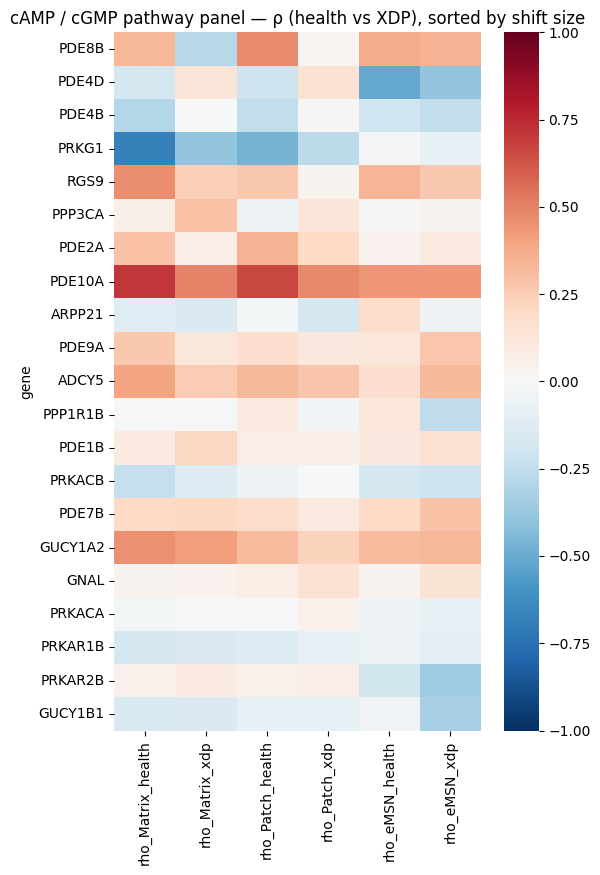

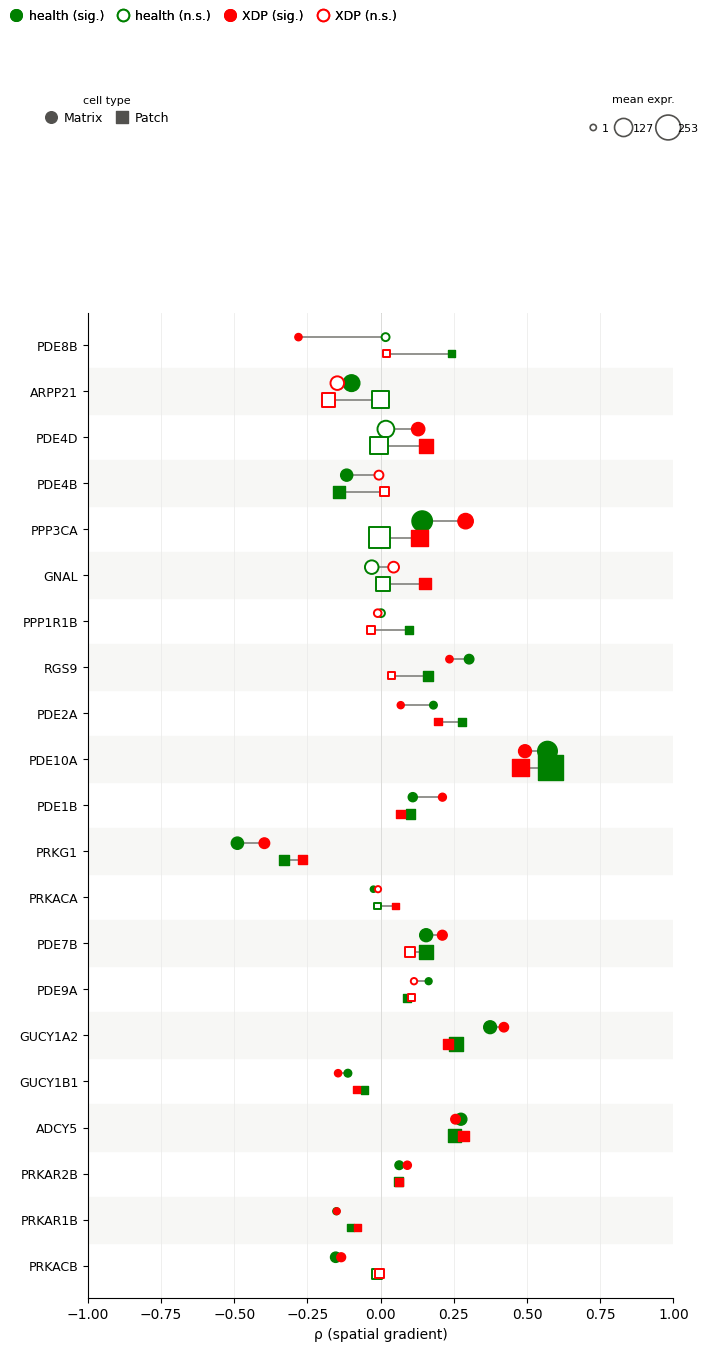

In [106]:
# ===== cAMP / cGMP pathway panel: health vs XDP =====
# Curated a priori (not discovered by the correlation analysis) - see markdown above.
CAMP_PATHWAY_GENES = [
    "ADCY5",                                                                    # adenylate cyclase
    "PRKACA", "PRKACB",                                                         # PKA catalytic subunits
    "PRKAR1B", "PRKAR2B",                                                       # PKA regulatory subunits
    "GNAL",                                                                     # Golf (D1/A2A -> adenylate cyclase)
    "PDE1B", "PDE2A", "PDE4B", "PDE4D", "PDE7B", "PDE8B", "PDE9A", "PDE10A",     # phosphodiesterases
    "PPP1R1B",                                                                  # DARPP-32
    "PPP3CA",                                                                   # calcineurin catalytic subunit
    "ARPP21",
    "RGS9",
    "GUCY1A2", "GUCY1B1",                                                       # soluble guanylate cyclase (NO/cGMP arm)
    "PRKG1",                                                                    # PKG
]

missing = [g for g in CAMP_PATHWAY_GENES if g not in df_corr.index or g not in df_corr_xdp.index]
genes_present = [g for g in CAMP_PATHWAY_GENES if g not in missing]
if missing:
    print(f"not found in df_corr / df_corr_xdp, skipping: {missing}")

# ----- numeric summary: full-range health vs XDP, all 3 compartments -----
rows = []
for g in genes_present:
    row = {"gene": g}
    for ct in ["Matrix", "Patch", "eMSN"]:
        row[f"rho_{ct}_health"]  = df_corr.loc[g, f"rho_{ct}"]
        row[f"rho_{ct}_xdp"]     = df_corr_xdp.loc[g, f"rho_{ct}"]
        row[f"padj_{ct}_health"] = df_corr.loc[g, f"padj_{ct}"]
        row[f"padj_{ct}_xdp"]    = df_corr_xdp.loc[g, f"padj_{ct}"]
    rows.append(row)
df_camp = pd.DataFrame(rows).set_index("gene")

# rank by the biggest health -> XDP swing, pooling Matrix + Patch (the vulnerable compartments)
df_camp["max_abs_shift"] = pd.concat(
    [(df_camp[f"rho_{ct}_health"] - df_camp[f"rho_{ct}_xdp"]).abs() for ct in ["Matrix", "Patch"]],
    axis=1
).max(axis=1)
df_camp = df_camp.sort_values("max_abs_shift", ascending=False)

rho_cols = [f"rho_{ct}_{cond}" for ct in ["Matrix", "Patch", "eMSN"] for cond in ["health", "xdp"]]
display(df_camp[rho_cols + ["max_abs_shift"]])

plt.figure(figsize=(6, 0.35 * len(df_camp) + 1.5))
sns.heatmap(df_camp[rho_cols], cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("cAMP / cGMP pathway panel — ρ (health vs XDP), sorted by shift size")
plt.tight_layout()
plt.show()

# ----- same health-vs-XDP dot plot already used for INTERESTING_GENES (§11.2), -----
# XDP-range-matched health so tissue-sampling differences aren't confounded with disease
plot_gene_gradient_shift_combined(df_corr_merged, genes_present, cell_types=("Matrix", "Patch"), padj_thr=PADJ_THR)


In [87]:

# protective
d = df_corr[
    (df_corr["rho_Matrix"] <=  -0.2) & (df_corr["padj_Matrix"] <= 0.05) &
    (df_corr["rho_Patch"] <=  -0.2) & (df_corr["padj_Patch"] <= 0.05) &
    (df_corr["rho_eMSN"].abs() <= 0.1) &
    (df_corr["mean_expr_Matrix"] >= 1) & (df_corr["mean_expr_Patch"] >= 1) &
    (df_corr["mean_expr_Matrix"] > df_corr["mean_expr_Patch"])
]
display(d)

g = d.index.tolist()

,rho_Matrix,padj_Matrix,rho_Patch,padj_Patch,rho_eMSN,padj_eMSN,pct_expr_Matrix,pct_expr_Patch,pct_expr_eMSN,mean_expr_Matrix,mean_expr_Patch,mean_expr_eMSN,log2fc_Matrix,log2fc_Patch,log2fc_eMSN
ABLIM1,-0.568271,8.048259e-121,-0.478316,3.803013e-91,0.061717,9.421104e-02,0.991737,0.992378,0.960967,16.957527,16.324645,7.994473,-0.565054,-0.431377,0.065851
ADAM23,-0.204813,7.254255e-16,-0.238179,1.786352e-16,0.057656,6.171248e-02,0.999833,0.999767,0.996718,63.935267,49.595357,24.395164,-0.129577,-0.179307,0.050031
AGBL1,-0.273641,1.448353e-28,-0.278412,3.201714e-31,0.014639,7.829463e-01,0.799074,0.627414,0.328670,25.278517,9.455201,1.102245,-0.678406,-0.546481,0.013551
AKAP5,-0.297036,2.578966e-31,-0.243545,2.232919e-22,-0.097479,3.457302e-05,0.939111,0.924366,0.735924,5.369490,4.843205,2.111399,-0.219256,-0.168235,-0.065077
ARHGAP6,-0.638952,4.105302e-133,-0.532040,9.913555e-186,-0.058419,3.753745e-02,0.515345,0.390912,0.105181,3.957715,2.252560,0.209499,-0.655101,-0.454740,-0.040713
ATP1B1,-0.343757,2.048606e-41,-0.273196,4.076263e-33,-0.058507,3.385526e-01,0.971765,0.962067,0.983247,8.786947,7.576041,16.389983,-0.281131,-0.191581,-0.052568
CADM3,-0.317180,6.829325e-64,-0.344345,5.588977e-59,-0.021805,4.513322e-01,0.937565,0.908075,0.928670,5.835269,5.087968,5.217789,-0.242126,-0.251452,-0.018467
CCDC77,-0.214385,5.980226e-44,-0.207004,8.976698e-31,0.012439,6.660577e-01,0.651663,0.634222,0.233161,1.672805,1.587037,0.336788,-0.109464,-0.098642,0.004209
CNTNAP3B,-0.215472,3.624147e-26,-0.229645,5.255012e-30,0.016054,5.602596e-01,0.887498,0.859437,0.122625,22.033594,19.849139,0.169085,-0.376923,-0.379929,0.008586
CRYBG3,-0.257544,3.369443e-18,-0.316039,7.067995e-50,-0.083168,1.223108e-02,0.986431,0.971026,0.755095,17.675030,14.527636,6.030225,-0.261377,-0.351857,-0.106459


Min p-value testable: 0.00025
Min p-value testable: 0.00025
Min p-value testable: 0.00025
Min p-value testable: 0.00025


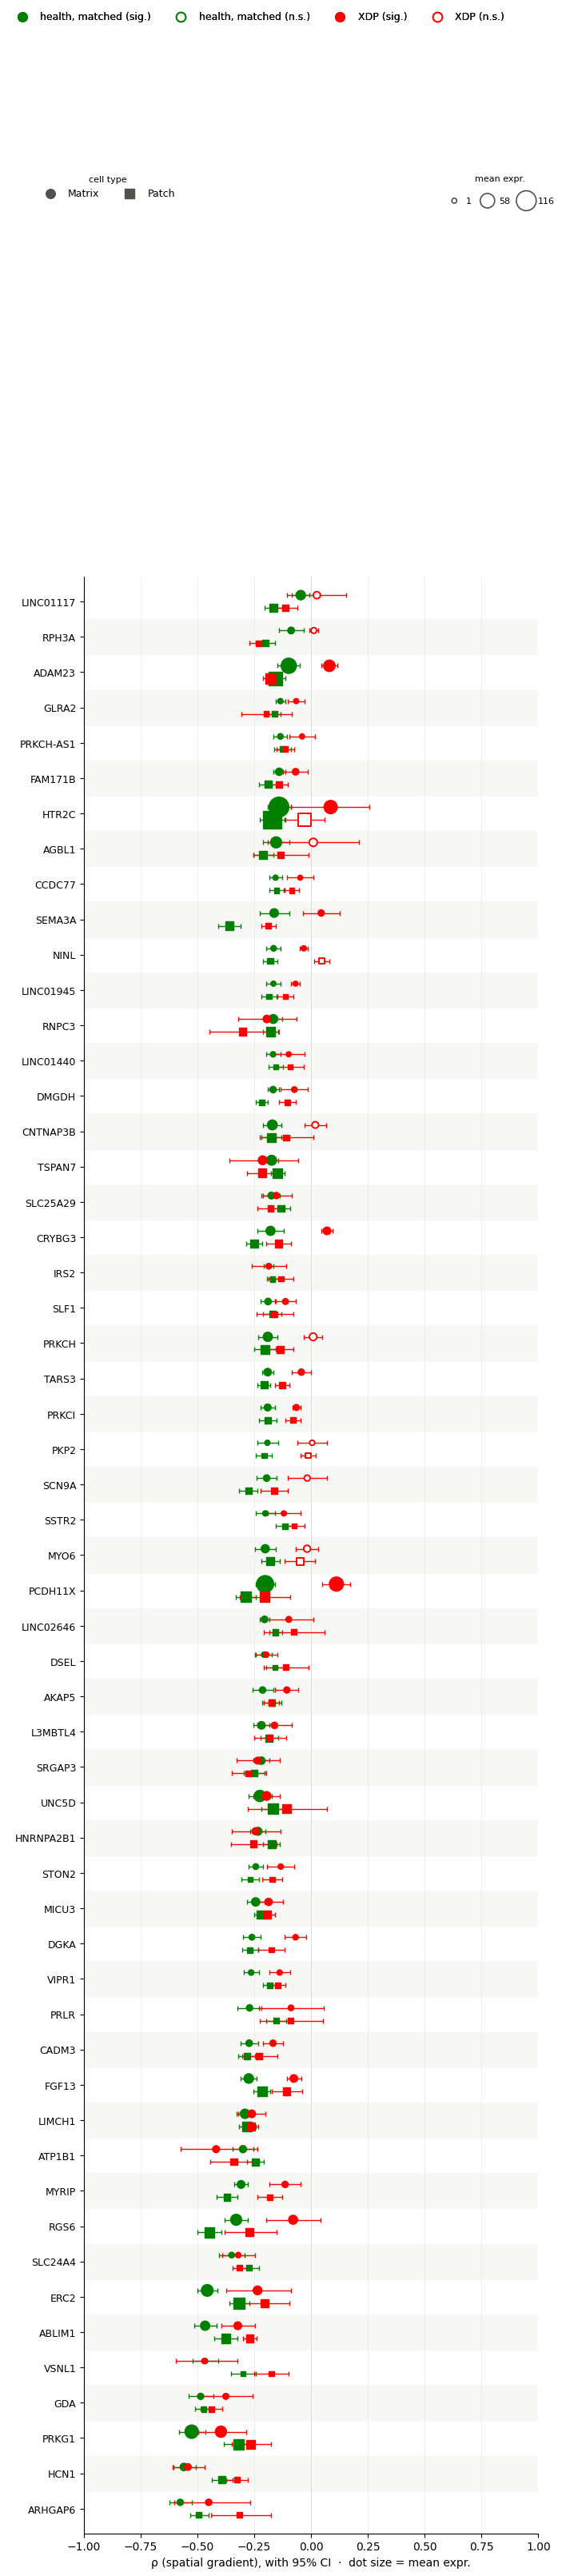

,z_obs_Matrix_xdp,rho_Matrix_xdp,ci_lo_Matrix_xdp,ci_hi_Matrix_xdp,pval_Matrix_xdp,padj_Matrix_xdp,z_obs_Matrix_matched,rho_Matrix_matched,ci_lo_Matrix_matched,ci_hi_Matrix_matched,...,ci_lo_Patch_xdp,ci_hi_Patch_xdp,pval_Patch_xdp,padj_Patch_xdp,z_obs_Patch_matched,rho_Patch_matched,ci_lo_Patch_matched,ci_hi_Patch_matched,pval_Patch_matched,padj_Patch_matched
ABLIM1,-0.334971,-0.322980,-0.394404,-0.247678,0.00025,0.01375,-0.505646,-0.466546,-0.514138,-0.416089,...,-0.299867,-0.238310,0.00025,0.01375,-0.395750,-0.376306,-0.425943,-0.324412,0.00025,0.01375
ADAM23,0.080569,0.080395,0.045521,0.115074,0.00025,0.01375,-0.098789,-0.098469,-0.147136,-0.049326,...,-0.210700,-0.146452,0.00025,0.01375,-0.158239,-0.156932,-0.199213,-0.114066,0.00025,0.01375
AGBL1,0.009393,0.009393,-0.191999,0.210026,0.32525,1.00000,-0.155206,-0.153972,-0.212232,-0.094621,...,-0.252968,-0.012852,0.00025,0.01375,-0.214196,-0.210980,-0.255466,-0.165602,0.00025,0.01375
AKAP5,-0.107299,-0.106889,-0.157771,-0.055441,0.00025,0.01375,-0.217054,-0.213709,-0.258818,-0.167670,...,-0.206736,-0.142393,0.00025,0.01375,-0.176255,-0.174453,-0.215978,-0.132297,0.00025,0.01375
ARHGAP6,-0.485815,-0.450889,-0.602269,-0.268207,0.00025,0.01375,-0.656475,-0.576012,-0.621820,-0.526277,...,-0.441511,-0.175003,0.00025,0.01375,-0.540847,-0.493629,-0.532651,-0.452513,0.00025,0.01375
ATP1B1,-0.445614,-0.418287,-0.572582,-0.235375,0.00025,0.01375,-0.309408,-0.299898,-0.344480,-0.253966,...,-0.443781,-0.227858,0.00025,0.01375,-0.250256,-0.245159,-0.280855,-0.208786,0.00025,0.01375
CADM3,-0.169472,-0.167868,-0.210340,-0.124763,0.00025,0.01375,-0.279839,-0.272756,-0.310651,-0.233995,...,-0.304450,-0.149350,0.00025,0.01375,-0.291620,-0.283626,-0.319389,-0.247055,0.00025,0.01375
CCDC77,-0.048158,-0.048121,-0.106099,0.010184,0.00025,0.01375,-0.157836,-0.156538,-0.184085,-0.128745,...,-0.117572,-0.051681,0.00025,0.01375,-0.153068,-0.151884,-0.184639,-0.118792,0.00025,0.01375
CNTNAP3B,0.018225,0.018223,-0.028454,0.064821,0.06300,1.00000,-0.172393,-0.170705,-0.211362,-0.129459,...,-0.224281,0.010651,0.00025,0.01375,-0.176462,-0.174653,-0.217959,-0.130661,0.00025,0.01375
CRYBG3,0.070138,0.070023,0.046780,0.093191,0.00025,0.01375,-0.180704,-0.178762,-0.234853,-0.121484,...,-0.196519,-0.089927,0.00025,0.01375,-0.255839,-0.250400,-0.286011,-0.214097,0.00025,0.01375


In [89]:
N_PERM = 4000
INTERESTING_GENES = d.index
df_list = []
for ct in ["Matrix", "Patch"]:
    df_perm_xdp = permutation_test_donor_level(xdp_adata_sub, list(INTERESTING_GENES), ct=ct, n_perm=N_PERM)
    df_perm_xdp.columns = [f"{col}_xdp" for col in df_perm_xdp.columns] # attach "xdp" at the end of each column name
    df_list.append(df_perm_xdp)
    df_perm_matched = permutation_test_donor_level(adata_matched, list(INTERESTING_GENES), ct=ct, n_perm=N_PERM)
    df_perm_matched.columns = [f"{col}_matched" for col in df_perm_matched.columns] # attach "matched" at the end of each column name
    df_list.append(df_perm_matched)
df_perm_combined = pd.concat(df_list, axis=1)
df_perm_combined

plot_gene_gradient_shift_permutation(df_perm_combined, list(INTERESTING_GENES),
                                      expr_df=df_corr_merged, sort_col=f"rho_{FOCUS_CT}_matched")

df_perm_combined.loc[df_list[0].index.intersection(INTERESTING_GENES)]

In [23]:
# protective — extended with detection-rate, effect-size, donor-consistency, and jump-score gates
MIN_PCT_EXPR = 0.2
MIN_LOG2FC   = 0.5
d = df_corr[
    (df_corr["rho_Matrix"] <=  -0.2) & (df_corr["padj_Matrix"] <= 0.05) &
    (df_corr["rho_Patch"]  <=  -0.2) & (df_corr["padj_Patch"]  <= 0.05) &
    #(df_corr["rho_eMSN"].abs() <= 0.1) &
    (df_corr["mean_expr_Matrix"] >= 1) & (df_corr["mean_expr_Patch"] >= 1) &
    (df_corr["mean_expr_Matrix"] <= df_corr["mean_expr_Patch"]) &
    (df_corr["pct_expr_Matrix"]  >= MIN_PCT_EXPR)    & (df_corr["pct_expr_Patch"]  >= MIN_PCT_EXPR) &
    (df_corr["log2fc_Matrix"].abs() >= MIN_LOG2FC)   & (df_corr["log2fc_Patch"].abs() >= MIN_LOG2FC)
    # dropped: mean_expr_Matrix > mean_expr_Patch — that's baseline expression level, not
    # positional selectivity; jump_score/rho below is the right way to ask "more Matrix-specific"
].copy()
d


d = df_corr[
    (df_corr["rho_Matrix"] >=  0.2) & (df_corr["padj_Matrix"] <= 0.05) &
    (df_corr["rho_Patch"]  >=  0.2) & (df_corr["padj_Patch"]  <= 0.05) &
    (df_corr["rho_eMSN"].abs() <= 0.1) &
    (df_corr["mean_expr_Matrix"] >= 1) & (df_corr["mean_expr_Patch"] >= 1) &
    (df_corr["mean_expr_Matrix"] >= df_corr["mean_expr_Patch"]) &
    (df_corr["pct_expr_Matrix"]  >= MIN_PCT_EXPR)    & (df_corr["pct_expr_Patch"]  >= MIN_PCT_EXPR) &
    (df_corr["log2fc_Matrix"].abs() >= MIN_LOG2FC)   & (df_corr["log2fc_Patch"].abs() >= MIN_LOG2FC)
    # dropped: mean_expr_Matrix > mean_expr_Patch — that's baseline expression level, not
    # positional selectivity; jump_score/rho below is the right way to ask "more Matrix-specific"
].copy()
d

,rho_Matrix,padj_Matrix,rho_Patch,padj_Patch,rho_eMSN,padj_eMSN,pct_expr_Matrix,pct_expr_Patch,pct_expr_eMSN,mean_expr_Matrix,mean_expr_Patch,mean_expr_eMSN,log2fc_Matrix,log2fc_Patch,log2fc_eMSN
TESPA1,0.666248,2.642479e-195,0.505129,2.398092e-67,-0.011161,0.918206,0.572306,0.462183,0.255613,6.72493,4.446183,0.859067,0.836282,0.534233,-0.018998


In [90]:
# protective — extended with detection-rate, effect-size, donor-consistency, and jump-score gates
MIN_PCT_EXPR = 0.2
MIN_LOG2FC   = 0.5

d = df_corr[
    (df_corr["rho_Matrix"] <=  -0.2) & (df_corr["padj_Matrix"] <= 0.05) &
    (df_corr["rho_Patch"]  <=  -0.2) & (df_corr["padj_Patch"]  <= 0.05) &
    (df_corr["rho_eMSN"].abs() <= 0.1) &
    (df_corr["mean_expr_Matrix"] >= 1) & (df_corr["mean_expr_Patch"] >= 1) &
    (df_corr["pct_expr_Matrix"]  >= MIN_PCT_EXPR)    & (df_corr["pct_expr_Patch"]  >= MIN_PCT_EXPR) &
    (df_corr["log2fc_Matrix"].abs() >= MIN_LOG2FC)   & (df_corr["log2fc_Patch"].abs() >= MIN_LOG2FC)
    # dropped: mean_expr_Matrix > mean_expr_Patch — that's baseline expression level, not
    # positional selectivity; jump_score/rho below is the right way to ask "more Matrix-specific"
].copy()

genes = d.index.tolist()

# donor consistency: what fraction of individual healthy donors agree on the negative sign
# (guards against a "significant" meta-analyzed rho actually being driven by 1-2 donors)
df_raw_matrix = pd.read_csv(f"{CORR_DIR}/df_raw_matrix.csv", index_col=0)
df_raw_patch  = pd.read_csv(f"{CORR_DIR}/df_raw_patch.csv",  index_col=0)
d["frac_donors_neg_Matrix"] = (df_raw_matrix[genes] < 0).mean(axis=0)
d["frac_donors_neg_Patch"]  = (df_raw_patch[genes]  < 0).mean(axis=0)

# jump-score diagnostics: how sharp/reliable the biggest local step is, and how much of the
# gene's dynamic range sits in that one step (near 1 = switch, low = smooth gradient)
dj_matrix = calc_jump_scores(adata, "Matrix", genes=genes, df_corr=df_corr, min_rho=0.2).add_suffix("_Matrix")
dj_patch  = calc_jump_scores(adata, "Patch",  genes=genes, df_corr=df_corr, min_rho=0.2).add_suffix("_Patch")
d = d.join(dj_matrix).join(dj_patch)
d["jump_score_mean"] = d[["jump_score_Matrix", "jump_score_Patch"]].mean(axis=1)

d = d.sort_values("jump_score_mean", ascending=False)
display(d)

genes = d.index.tolist()


,rho_Matrix,padj_Matrix,rho_Patch,padj_Patch,rho_eMSN,padj_eMSN,pct_expr_Matrix,pct_expr_Patch,pct_expr_eMSN,mean_expr_Matrix,...,log2fc_eMSN,frac_donors_neg_Matrix,frac_donors_neg_Patch,jump_score_Matrix,jump_location_Matrix,jump_fraction_Matrix,jump_score_Patch,jump_location_Patch,jump_fraction_Patch,jump_score_mean
HCN1,-0.591152,5.886225e-65,-0.400616,2.891501e-45,-0.091272,0.000008,0.632735,0.717477,0.984111,8.003134,...,-0.103405,1.0,1.0,2.003017,0.30,0.188029,1.985982,0.05,0.210201,1.994499
RGS6,-0.485113,8.144879e-44,-0.606829,4.698678e-87,0.009166,0.800702,0.935006,0.815685,0.105009,26.549806,...,0.000754,1.0,1.0,1.701337,0.30,0.112852,1.956108,0.45,0.136012,1.828722
PCDH11X,-0.361397,5.286799e-41,-0.433070,8.590837e-78,-0.042415,0.120152,0.980842,0.718175,0.235924,73.632129,...,-0.023759,1.0,1.0,1.228044,0.05,0.096503,1.917501,0.45,0.205667,1.572772
PRKG1,-0.676010,4.173427e-183,-0.474623,1.065938e-75,-0.020873,0.437440,0.884124,0.807075,0.292746,37.336763,...,-0.048440,1.0,1.0,1.511932,0.70,0.090083,1.559830,0.75,0.113045,1.535881
GALNTL6,-0.550037,2.189940e-116,-0.398703,1.469103e-70,0.048259,0.464162,0.949097,0.993717,0.999827,50.577581,...,0.061845,1.0,1.0,1.443060,0.30,0.117074,1.623482,0.45,0.229924,1.533271
AGBL1,-0.273641,1.448353e-28,-0.278412,3.201714e-31,0.014639,0.782946,0.799074,0.627414,0.328670,25.278517,...,0.013551,1.0,1.0,1.186953,0.70,0.115945,1.394478,0.10,0.236097,1.290715


In [96]:
a = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad", backed="r")

In [97]:
a.obs.columns

Index(['background_fraction', 'cell_probability', 'cell_size',
       'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library',
       'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead',
       'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet',
       'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet',
       'vireo_doublet_logLikRatio', 'dropsift_frac_contamination',
       'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score',
       'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1',
       'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue',
       'broad_original_cell_type', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'brain_ban

In [104]:
a.obs[["donor_id", 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'condition', 'ct_for_deg']]
a.obs[["donor_id", 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'condition', 'ct_for_deg']].drop_duplicates(["donor_id"])
#a.obs[["donor_id", 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'condition', 'ct_for_deg']].groupby(["donor_id", "library"]).count()

,donor_id,barcode,bcl,rna_index,library,library__barcode,condition,ct_for_deg
barcode,,,,,,,,
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGACGTTCATGTGGT-1_Striatum_SCF-20-025,SCF-20-025,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGACGTT...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGACGTT...,XDP,-Low_quality
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TCGGGACTCTCTGTCG-1_Striatum_SCF-22-054CM,SCF-22-054CM,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TCGGGACT...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TCGGGACT...,Control,Astrocyte
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGGTCACAAGAGGCT-1_Striatum_SCF-19-009,SCF-19-009,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGGTCAC...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGGTCAC...,XDP,Astrocyte
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__ACTGTCCGTGTGACCC-1_Striatum_SCF-18-006,SCF-18-006,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__ACTGTCCG...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__ACTGTCCG...,XDP,Astrocyte
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CAGAGAGGTAATAGCA-1_Striatum_SCF_20-024,SCF_20-024,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CAGAGAGG...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CAGAGAGG...,XDP,Astrocyte
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GGTGAAGCAGTCCTTC-1_Striatum_SCF_22-043,SCF_22-043,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GGTGAAGC...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GGTGAAGC...,XDP,Astrocyte
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GATCGTAAGGTGACCA-1_Striatum_SCF-18-003,SCF-18-003,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GATCGTAA...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GATCGTAA...,XDP,Astrocyte
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CCTAGCTTCACTCCTG-1_Striatum_SCF-19-018,SCF-19-018,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CCTAGCTT...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CCTAGCTT...,XDP,Astrocyte
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TGGCGCAGTGCGATAG-1_Striatum_SCF-19-014,SCF-19-014,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TGGCGCAG...,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TGGCGCAG...,XDP,Astrocyte


In [ ]:
a.obs[["donor_id", 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode']]

,donor_id,barcode,bcl,rna_index,library,library__barcode
library__barcode,,,,,,
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CACACAATCTTACCTA-1,doublet,CACACAATCTTACCTA-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CACACAAT...
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__ACAGCCGCAACGATCT-1,SCF_22-043,ACAGCCGCAACGATCT-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__ACAGCCGC...
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__AGATTGCAGAGGTACC-1,doublet,AGATTGCAGAGGTACC-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__AGATTGCA...
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CAAGTTGCAAATACAG-1,doublet,CAAGTTGCAAATACAG-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CAAGTTGC...
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GTATTCTTCTGCGTAA-1,SCF_22-043,GTATTCTTCTGCGTAA-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GTATTCTT...
...,...,...,...,...,...,...
250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__ACGGGTAAGACATCCA-1,SCF_22-052,ACGGGTAAGACATCCA-1,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__ACGG...
250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__AGAGGTAGTAATCTCT-1,SCF_22-060,AGAGGTAGTAATCTCT-1,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__AGAG...
250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__CATCATTGTCACCCGC-1,unassigned,CATCATTGTCACCCGC-1,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__CATC...
